# Old API implementation

In [1]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt
import time
import pandas as pd

from gridcp import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.utils import fastlog
from gridcp.calibration import draw_samples, mc_max_statistics
from gridcp import builtins
from gridcp.builtins import gen_gaussian_regression_obs

TypeError: unsupported operand type(s) for |: 'type' and '_CallableGenericAlias'

# General LR/GLR implementation for exponential families

**Primary goal:** Implement a **general** LR/GLR changepoint detector for exponential families.

For a canonical exponential family $p(y|\theta)=\eta(y)\exp(\theta^\top h(y)-A(\theta))$, the GLR
statistic is
$$f_b^{(t)} = \ell(\hat\theta_{1:b})+\ell(\hat\theta_{b+1:t})-\ell(\hat\theta_{1:t}),$$
where $\hat\theta$ are the MLEs, determined by $A$ and $h$ through solving the score equation
$\nabla A(\hat\theta) = \bar{h}$. The penalty scales as $v(\log t + \sqrt{\log t})$, where $v$
is the dimension of the sufficient statistic $h$. Hence, the test is fully determined as long as the user provides the following:
- `h` — sufficient statistic
- `A` — log-partition function
- `A_prime` — gradient of $A$ (optional, faster)
- `A_dprime` — Hessian of $A$ (optional, fastest — enables Newton's method)

Providing more derivatives enables faster and more Numba-compatible solvers, but the detector
should be correct regardless of which are provided.

## 1. Scalar newton implementation

In [2]:
# -----------------------------------------------------------
# Newton MLE verification — summary table
# -----------------------------------------------------------

N_REPS = 100_000

# -----------------------------------------------------------
# Solvers
# -----------------------------------------------------------

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta


def make_newton_solver(A_prime, A_dprime):
    @nb.njit
    def solver(S, n, theta_init, tol=1e-8, max_iter=20):
        theta = theta_init
        target = S / n
        for _ in range(max_iter):
            residual = A_prime(theta) - target
            if abs(residual) < tol:
                return theta
            adp = A_dprime(theta)
            if adp < 1e-15:
                return theta
            theta -= residual / adp
        return theta
    return solver


def scalar_newton_mle_python(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

# -----------------------------------------------------------
# Numba A_prime / A_dprime functions
# -----------------------------------------------------------

@nb.njit
def A_prime_gaussian(theta):
    return theta

@nb.njit
def A_dprime_gaussian(theta):
    return 1.0

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_prime_exponential(theta):
    return -1.0 / min(theta, -1e-10)

@nb.njit
def A_dprime_exponential(theta):
    return 1.0 / min(theta, -1e-10)**2

@nb.njit
def A_prime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)**2

@nb.njit
def A_prime_variance(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

@nb.njit
def A_dprime_variance(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# -----------------------------------------------------------
# Plain Python A_prime / A_dprime functions
# -----------------------------------------------------------

def A_prime_gaussian_py(theta):
    return theta

def A_dprime_gaussian_py(theta):
    return 1.0

def A_prime_poisson_py(theta):
    import math
    return math.exp(theta)

def A_dprime_poisson_py(theta):
    import math
    return math.exp(theta)

def A_prime_exponential_py(theta):
    return -1.0 / min(theta, -1e-10)

def A_dprime_exponential_py(theta):
    return 1.0 / min(theta, -1e-10)**2

def A_prime_bernoulli_py(theta):
    import math
    e = math.exp(theta)
    return e / (1.0 + e)

def A_dprime_bernoulli_py(theta):
    import math
    e = math.exp(theta)
    return e / (1.0 + e)**2

def A_prime_variance_py(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

def A_dprime_variance_py(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)
n_test     = 1000
mu_true    = 2.5
lambda_true = 3.0
beta_true  = 2.0
p_true     = 0.4
sigma_true = 2.0

X_gauss = np.random.normal(mu_true, 1.0, n_test)
X_pois  = np.random.poisson(lambda_true, n_test).astype(np.float64)
X_exp   = np.random.exponential(1.0 / beta_true, n_test)
X_bern  = np.random.binomial(1, p_true, n_test).astype(np.float64)
X_var   = np.random.normal(0.0, sigma_true, n_test)

S_gauss = np.sum(X_gauss)
S_pois  = np.sum(X_pois)
S_exp   = np.sum(X_exp)
S_bern  = np.sum(X_bern)
S_var   = np.sum(X_var**2)

# Exact closed-form MLEs (in theta)
theta_mle_gauss = S_gauss / n_test
theta_mle_pois  = np.log(S_pois / n_test)
theta_mle_exp   = -1.0 / (S_exp / n_test)
theta_mle_bern  = np.log((S_bern / n_test) / (1.0 - S_bern / n_test))
theta_mle_var   = -1.0 / (2.0 * S_var / n_test)

# -----------------------------------------------------------
# Case definitions
# -----------------------------------------------------------
cases = [
    (
        "Gaussian (mean)",
        S_gauss, n_test, 0.0, theta_mle_gauss,
        lambda th: th,
        mu_true,
        A_prime_gaussian,    A_dprime_gaussian,
        A_prime_gaussian_py, A_dprime_gaussian_py,
    ),
    (
        "Gaussian (variance)",
        S_var, n_test, -1.0 / (2.0 * (S_var / n_test)), theta_mle_var,
        lambda th: np.sqrt(-1.0 / (2.0 * th)),
        sigma_true,
        A_prime_variance,    A_dprime_variance,
        A_prime_variance_py, A_dprime_variance_py,
    ),
    (
        "Poisson",
        S_pois, n_test, 0.0, theta_mle_pois,
        lambda th: np.exp(th),
        lambda_true,
        A_prime_poisson,    A_dprime_poisson,
        A_prime_poisson_py, A_dprime_poisson_py,
    ),
    (
        "Exponential",
        S_exp, n_test, -1.0, theta_mle_exp,
        lambda th: -1.0 / th,
        beta_true,
        A_prime_exponential,    A_dprime_exponential,
        A_prime_exponential_py, A_dprime_exponential_py,
    ),
    (
        "Bernoulli",
        S_bern, n_test, 0.0, theta_mle_bern,
        lambda th: 1.0 / (1.0 + np.exp(-th)),
        p_true,
        A_prime_bernoulli,    A_dprime_bernoulli,
        A_prime_bernoulli_py, A_dprime_bernoulli_py,
    ),
]

# -----------------------------------------------------------
# Run and collect results
# -----------------------------------------------------------
results = []

for name, S_val, n_val, theta_init, theta_mle, backtransform, true_param, ap, adp, ap_py, adp_py in cases:

    # Callback Numba
    _ = scalar_newton_mle(S_val, n_val, theta_init, ap, adp)
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_cb = scalar_newton_mle(S_val, n_val, theta_init, ap, adp)
    t_cb = time.perf_counter() - start

    # Closure Numba
    solver = make_newton_solver(ap, adp)
    _ = solver(S_val, n_val, theta_init)
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_cl = solver(S_val, n_val, theta_init)
    t_cl = time.perf_counter() - start

    # Python
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_py = scalar_newton_mle_python(S_val, n_val, theta_init, ap_py, adp_py)
    t_py = time.perf_counter() - start

    results.append({
        "Distribution":    name,
        "Exact MLE (θ)":   f"{theta_mle:.6f}",
        "Newton MLE (θ)":  f"{th_cl:.6f}",
        "Error":           f"{abs(th_cl - theta_mle):.1e}",
        "Param hat":       f"{backtransform(th_cl):.4f}",
        "True param":      f"{true_param:.4f}",
        "Callback (µs)":   f"{t_cb / N_REPS * 1e6:.3f}",
        "Closure (µs)":    f"{t_cl / N_REPS * 1e6:.3f}",
        "Python (µs)":     f"{t_py / N_REPS * 1e6:.3f}",
        "Speedup (cb/cl)": f"{t_cb / t_cl:.1f}x",
        "Speedup (py/cl)": f"{t_py / t_cl:.1f}x",
    })

df = pd.DataFrame(results).set_index("Distribution")

df_accuracy = df[["Exact MLE (θ)", "Newton MLE (θ)", "Error", "Param hat", "True param"]]
df_timing   = df[["Callback (µs)", "Closure (µs)", "Python (µs)", "Speedup (cb/cl)", "Speedup (py/cl)"]]

print("=== MLE Accuracy ===")
print(df_accuracy.to_string())
print("\n=== Runtime ===")
print(df_timing.to_string())

=== MLE Accuracy ===
                    Exact MLE (θ) Newton MLE (θ)    Error Param hat True param
Distribution                                                                  
Gaussian (mean)          2.519332       2.519332  0.0e+00    2.5193     2.5000
Gaussian (variance)     -0.120339      -0.120339  0.0e+00    2.0384     2.0000
Poisson                  1.089908       1.089908  5.0e-14    2.9740     3.0000
Exponential             -1.994051      -1.994051  4.2e-10    0.5015     2.0000
Bernoulli               -0.502301      -0.502301  2.0e-11    0.3770     0.4000

=== Runtime ===
                    Callback (µs) Closure (µs) Python (µs) Speedup (cb/cl) Speedup (py/cl)
Distribution                                                                              
Gaussian (mean)            10.650        0.291       0.605           36.6x            2.1x
Gaussian (variance)        10.249        0.324       0.576           31.6x            1.8x
Poisson                    10.662        0.36

### Summary: Scalar Newton MLE

The scalar Newton solver correctly recovers the MLE for both the Gaussian and Poisson
families, converging to machine precision (error $\leq 3.64 \times 10^{-14}$).

#### Key finding: closure-based JIT compilation

Three implementations were benchmarked on both families:

| Implementation   | Gaussian runtime | Poisson runtime |
|------------------|-----------------|-----------------|
| Callback Numba   | 11.357 µs       | 11.164 µs       |
| Plain Python     | 0.656 µs        | 3.336 µs        |
| Closure Numba    | 0.315 µs        | 0.382 µs        |

Passing `A_prime` and `A_dprime` as callbacks into a Numba-compiled function incurs
significant dispatch overhead (~11 µs regardless of family), making it far slower than
plain Python. The solution is the **closure-based approach** via
`make_newton_solver(A_prime, A_dprime)`, which bakes the exponential family functions
in at JIT compile time, eliminating callback overhead entirely.

The closure-based solver is the clear winner in both cases, though the margin over plain
Python depends on the family — the Poisson case benefits more (8.7x speedup) than the
Gaussian case (2.1x speedup) since the Gaussian $A''(\theta) = 1$ is trivially cheap
in Python too. For more expensive families (e.g. those requiring `exp` evaluations),
the Numba speedup is expected to be larger.

The closure-based solver is compiled once at detector initialization, so the user pays
the JIT compilation cost only once. All subsequent solves run at full Numba speed. Since
`f` costs $O(1)$ (3 Newton solves + 3 likelihood evaluations) and the grid maintains
$O(\log t)$ candidate changepoints, the total cost per time step is $O(\log t)$. At
$t = 100{,}000$ this means roughly $17 \times 3 \times 0.38 \approx 19$ µs per time
step, which is very reasonable.

**Conclusion:** The `make_newton_solver` closure pattern should be used throughout the
implementation. The callback Numba approach should be avoided entirely.

## 2. Multivariate Newton implementation

In [8]:
# -----------------------------------------------------------
# 2. Multivariate Newton MLE
# -----------------------------------------------------------

# For the multivariate case, the MLE condition is:
#   grad_A(theta) = S / n
# where theta, S are vectors of dimension v.
# The Newton update is:
#   theta <- theta - H_A(theta)^{-1} @ (grad_A(theta) - S/n)
# where H_A is the Hessian of A.


def make_vector_newton_solver(A_grad, A_hess):
    """
    Bare-metal Newton MLE solver — all safety guards removed.
 
    Assumptions the caller must guarantee:
      - n > 0
      - A_grad and A_hess return finite values for the expected input range
      - The Hessian is well-conditioned enough that a full Newton step always
        reduces the residual (true near the MLE for well-specified exponential
        family models)
      - theta_init is a reasonable starting point (close enough that the
        un-damped Newton step converges)
 
    What was removed vs. the safe version:
      - np.isfinite guards on H, step, theta_cand
      - Backtracking line search (always takes full step_scale=1.0)
      - n <= 0 guard
      - step_norm > 1e10 guard
 
    What was kept:
      - Convergence check (res_norm < tol) — this is the exit condition
      - Ridge regularization (+1e-6 on diagonal) — one cheap op, prevents
        catastrophic failure if H is momentarily near-singular
      - Cached gradient across iterations — avoids one A_grad call per step
    """
 
    @nb.njit(cache=True, inline='always')
    def _norm(a):
        s = 0.0
        for i in range(a.shape[0]):
            s += a[i] * a[i]
        return math.sqrt(s)
 
    @nb.njit(cache=True, inline='always')
    def _solve(H_reg, residual):
        n = H_reg.shape[0]
        if n == 2:
            det = H_reg[0, 0] * H_reg[1, 1] - H_reg[0, 1] * H_reg[1, 0]
            inv_det = 1.0 / det
            x0 = (H_reg[1, 1] * residual[0] - H_reg[0, 1] * residual[1]) * inv_det
            x1 = (H_reg[0, 0] * residual[1] - H_reg[1, 0] * residual[0]) * inv_det
            return np.array([x0, x1])
        elif n == 3:
            a, b, c = H_reg[0, 0], H_reg[0, 1], H_reg[0, 2]
            d, e, f = H_reg[1, 0], H_reg[1, 1], H_reg[1, 2]
            g, h, k = H_reg[2, 0], H_reg[2, 1], H_reg[2, 2]
            det = a*(e*k - f*h) - b*(d*k - f*g) + c*(d*h - e*g)
            inv_det = 1.0 / det
            x0 = ((e*k - f*h)*residual[0] + (c*h - b*k)*residual[1] + (b*f - c*e)*residual[2]) * inv_det
            x1 = ((f*g - d*k)*residual[0] + (a*k - c*g)*residual[1] + (c*d - a*f)*residual[2]) * inv_det
            x2 = ((d*h - e*g)*residual[0] + (b*g - a*h)*residual[1] + (a*e - b*d)*residual[2]) * inv_det
            return np.array([x0, x1, x2])
        else:
            return np.linalg.solve(H_reg, residual)
 
    @nb.njit(cache=True)
    def solver(S_vec, n, theta_init, tol=1e-8, max_iter=30):
        theta = theta_init.copy()
        target = S_vec / n
 
        grad = A_grad(theta)
        residual = grad - target
        res_norm = _norm(residual)
 
        for _ in range(max_iter):
            if res_norm < tol:
                return theta
 
            H = A_hess(theta)
            H[0, 0] += 1e-6  # mutate in-place, no copy needed
            H[1, 1] += 1e-6
 
            step = _solve(H, residual)
 
            theta -= step
 
            grad = A_grad(theta)
            residual = grad - target
            res_norm = _norm(residual)
 
        return theta
 
    return solver

# -----------------------------------------------------------
# Multivariate Newton MLE verification — summary table
# -----------------------------------------------------------

results_mv = []

# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)
p_mv = 3
n_mv = 1000
mu_true_mv = np.array([1.0, 2.0, 3.0])

mu_true_gu = 2.5
sigma2_true_gu = 3.0
n_gu = 1000

X_mv = np.random.multivariate_normal(mu_true_mv, np.eye(p_mv), n_mv)
X_gu = np.random.normal(mu_true_gu, np.sqrt(sigma2_true_gu), n_gu)

S_mv = np.sum(X_mv, axis=0)
S_gu = np.array([np.sum(X_gu), np.sum(X_gu**2)])

# Exact MLEs
x_bar_mv = S_mv / n_mv
mu_hat_exact = np.mean(X_gu)
sigma2_hat_exact = np.mean(X_gu**2) - np.mean(X_gu) ** 2

# -----------------------------------------------------------
# Grad / Hess functions
# -----------------------------------------------------------

@nb.njit
def A_grad_mvgaussian(theta):
    return theta.copy()


@nb.njit
def A_hess_mvgaussian(theta):
    return np.eye(len(theta))


@nb.njit
def A_grad_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])


@nb.njit
def A_hess_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# -----------------------------------------------------------
# Solvers
# -----------------------------------------------------------

mv_gaussian_solver = make_vector_newton_solver(A_grad_mvgaussian, A_hess_mvgaussian)
gu_solver = make_vector_newton_solver(A_grad_gaussian_unknown, A_hess_gaussian_unknown)

theta_init_mv = np.zeros(p_mv)
theta_init_gu = np.array([mu_hat_exact / sigma2_hat_exact, -1.0 / (2.0 * sigma2_hat_exact)])

# Warm-up
_ = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
_ = gu_solver(S_gu, n_gu, theta_init_gu)

# -----------------------------------------------------------
# Multivariate Gaussian (known covariance = I)
# -----------------------------------------------------------
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_mv = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
t_mv = time.perf_counter() - start

results_mv.append(
    {
        "Distribution": "MV Gaussian (known cov)",
        "Parameter": "μ (vector)",
        "Exact MLE": str(np.round(x_bar_mv, 4)),
        "Newton MLE": str(np.round(theta_hat_mv, 4)),
        "Error (‖·‖)": f"{np.linalg.norm(theta_hat_mv - x_bar_mv):.1e}",
        "Runtime (µs)": f"{t_mv / N_REPS * 1e6:.3f}",
    }
)

# -----------------------------------------------------------
# Gaussian (unknown mean and variance)
# -----------------------------------------------------------
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_gu = gu_solver(S_gu, n_gu, theta_init_gu)
t_gu = time.perf_counter() - start

mu_hat_newton = -theta_hat_gu[0] / (2.0 * theta_hat_gu[1])
sigma2_hat_newton = -1.0 / (2.0 * theta_hat_gu[1])

results_mv.append(
    {
        "Distribution": "Gaussian (unknown μ, σ²) — μ",
        "Parameter": "μ",
        "Exact MLE": f"{mu_hat_exact:.6f}",
        "Newton MLE": f"{mu_hat_newton:.6f}",
        "Error (‖·‖)": f"{abs(mu_hat_newton - mu_hat_exact):.1e}",
        "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
    }
)
results_mv.append(
    {
        "Distribution": "Gaussian (unknown μ, σ²) — σ²",
        "Parameter": "σ²",
        "Exact MLE": f"{sigma2_hat_exact:.6f}",
        "Newton MLE": f"{sigma2_hat_newton:.6f}",
        "Error (‖·‖)": f"{abs(sigma2_hat_newton - sigma2_hat_exact):.1e}",
        "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
    }
)

df_mv = pd.DataFrame(results_mv).set_index("Distribution")
print("=== Multivariate MLE Accuracy & Runtime ===")
print(df_mv.to_string())

=== Multivariate MLE Accuracy & Runtime ===
                                Parameter            Exact MLE           Newton MLE Error (‖·‖) Runtime (µs)
Distribution                                                                                                
MV Gaussian (known cov)        μ (vector)  [1.055 1.994 3.047]  [1.055 1.994 3.047]     2.3e-12       50.745
Gaussian (unknown μ, σ²) — μ            μ             2.467577             2.467577     0.0e+00       49.936
Gaussian (unknown μ, σ²) — σ²          σ²             3.161839             3.161839     0.0e+00       49.936


In [9]:
# -----------------------------------------------------------
# 2. Multivariate Newton MLE
# -----------------------------------------------------------

# For the multivariate case, the MLE condition is:
#   grad_A(theta) = S / n
# where theta, S are vectors of dimension v.
# The Newton update is:
#   theta <- theta - H_A(theta)^{-1} @ (grad_A(theta) - S/n)
# where H_A is the Hessian of A.


def make_vector_newton_solver(A_grad, A_hess):
    @nb.njit(cache=True, inline='always')
    def _norm(a):
        s = 0.0
        for i in range(a.shape[0]):
            s += a[i] * a[i]
        return math.sqrt(s)

    @nb.njit(cache=True, inline='always')
    def _solve(H_reg, residual):
        n = H_reg.shape[0]
        if n == 2:
            det = H_reg[0, 0] * H_reg[1, 1] - H_reg[0, 1] * H_reg[1, 0]
            inv_det = 1.0 / det
            x0 = (H_reg[1, 1] * residual[0] - H_reg[0, 1] * residual[1]) * inv_det
            x1 = (H_reg[0, 0] * residual[1] - H_reg[1, 0] * residual[0]) * inv_det
            return np.array([x0, x1])
        elif n == 3:
            a, b, c = H_reg[0, 0], H_reg[0, 1], H_reg[0, 2]
            d, e, f = H_reg[1, 0], H_reg[1, 1], H_reg[1, 2]
            g, h, k = H_reg[2, 0], H_reg[2, 1], H_reg[2, 2]
            det = a*(e*k - f*h) - b*(d*k - f*g) + c*(d*h - e*g)
            inv_det = 1.0 / det
            x0 = ((e*k - f*h)*residual[0] + (c*h - b*k)*residual[1] + (b*f - c*e)*residual[2]) * inv_det
            x1 = ((f*g - d*k)*residual[0] + (a*k - c*g)*residual[1] + (c*d - a*f)*residual[2]) * inv_det
            x2 = ((d*h - e*g)*residual[0] + (b*g - a*h)*residual[1] + (a*e - b*d)*residual[2]) * inv_det
            return np.array([x0, x1, x2])
        else:
            return np.linalg.solve(H_reg, residual)

    @nb.njit(cache=True)
    def solver(S_vec, n, theta_init, tol=1e-8, max_iter=50):
        theta = theta_init.copy()
        target = S_vec / n

        grad = A_grad(theta)
        residual = grad - target
        res_norm = _norm(residual)

        for _ in range(max_iter):
            if res_norm < tol:
                return theta

            if not np.isfinite(res_norm):
                return theta

            H = A_hess(theta)

            # Check Hessian is finite — A_hess returns nan matrix when
            # the iterate leaves the valid parameter region
            h_finite = True
            for i in range(H.shape[0]):
                if not np.isfinite(H[i, i]):
                    h_finite = False
                    break
            if not h_finite:
                return theta

            # Full diagonal ridge (not just first two elements)
            for i in range(H.shape[0]):
                H[i, i] += 1e-6

            step = _solve(H, residual)

            # Backtracking line search — necessary for the covariance case
            # where a full Newton step can cross the boundary of the valid
            # parameter region (where -2*Theta must be positive definite)
            accepted = False
            step_scale = 1.0
            for _ in range(20):
                theta_cand = theta - step_scale * step
                grad_cand = A_grad(theta_cand)
                residual_cand = grad_cand - target
                res_norm_cand = _norm(residual_cand)
                if np.isfinite(res_norm_cand) and res_norm_cand <= res_norm:
                    theta = theta_cand
                    grad = grad_cand
                    residual = residual_cand
                    res_norm = res_norm_cand
                    accepted = True
                    break
                step_scale *= 0.5

            if not accepted:
                return theta

        return theta

    return solver


# -----------------------------------------------------------
# Grad / Hess: MV Gaussian (known covariance = I)
# -----------------------------------------------------------

@nb.njit
def A_grad_mvgaussian(theta):
    return theta.copy()

@nb.njit
def A_hess_mvgaussian(theta):
    return np.eye(len(theta))


# -----------------------------------------------------------
# Grad / Hess: Gaussian (unknown mean and variance)
# -----------------------------------------------------------

@nb.njit
def A_grad_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])

@nb.njit
def A_hess_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# -----------------------------------------------------------
# Grad / Hess: MV Gaussian (unknown covariance, known mean = 0)
# Natural parameter: theta = vech(-0.5 * Sigma^{-1})
# A(theta) = -0.5 * log det(-2 * Theta),  Theta = mat(theta)
# -----------------------------------------------------------

@nb.njit
def _p_from_v(v):
    """Recover p from vech dimension v = p*(p+1)/2."""
    return int((-1.0 + (1.0 + 8.0 * v) ** 0.5) / 2.0)

@nb.njit
def _fill_sym(theta_vec, p):
    """Reconstruct symmetric matrix from upper-triangle vector."""
    Theta = np.zeros((p, p))
    idx = 0
    for i in range(p):
        for j in range(i, p):
            Theta[i, j] = theta_vec[idx]
            Theta[j, i] = theta_vec[idx]
            idx += 1
    return Theta

@nb.njit
def A_grad_cov(theta):
    """
    grad A = vech((-2*Theta)^{-1}) with off-diagonal entries doubled.
    Returns NaN vector if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    M_inv = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = -M_inv[i, i]
            else:
                g[idx] = -2.0 * M_inv[i, j]
            idx += 1
    return g

@nb.njit
def A_hess_cov(theta):
    """
    Hessian of A.
    H_{(i,j),(k,l)} = -2 * (M^{-1})_{ik} (M^{-1})_{jl} * c_{ij} * c_{kl}
    where c_{ij} = 1 if i==j else 2.
    Returns NaN matrix if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)

    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i
            cols[idx] = j
            idx += 1

    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H


# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)

# MV Gaussian (known covariance = I)
p_mv       = 3
n_mv       = 1000
mu_true_mv = np.array([1.0, 2.0, 3.0])
X_mv       = np.random.multivariate_normal(mu_true_mv, np.eye(p_mv), n_mv)
S_mv       = np.sum(X_mv, axis=0)
x_bar_mv   = S_mv / n_mv

# Gaussian (unknown mean and variance)
mu_true_gu     = 2.5
sigma2_true_gu = 3.0
n_gu           = 1000
X_gu           = np.random.normal(mu_true_gu, np.sqrt(sigma2_true_gu), n_gu)
S_gu           = np.array([np.sum(X_gu), np.sum(X_gu**2)])
mu_hat_exact      = np.mean(X_gu)
sigma2_hat_exact  = np.mean(X_gu**2) - np.mean(X_gu)**2

# MV Gaussian (unknown covariance, known mean = 0)
p_cov      = 3
n_cov      = 1000
v_cov      = p_cov * (p_cov + 1) // 2
Sigma_true = np.diag([1.0, 2.0, 3.0])
X_cov      = np.random.multivariate_normal(np.zeros(p_cov), Sigma_true, n_cov)
S_outer    = X_cov.T @ X_cov
triu_r, triu_c  = np.triu_indices(p_cov)
S_vec_cov       = S_outer[triu_r, triu_c]
Sigma_hat_exact = S_outer / n_cov
theta_hat_exact_cov = (-0.5 * np.linalg.inv(Sigma_hat_exact))[triu_r, triu_c]


# -----------------------------------------------------------
# Build solvers and warm up
# -----------------------------------------------------------
mv_gaussian_solver = make_vector_newton_solver(A_grad_mvgaussian,      A_hess_mvgaussian)
gu_solver          = make_vector_newton_solver(A_grad_gaussian_unknown, A_hess_gaussian_unknown)
cov_solver         = make_vector_newton_solver(A_grad_cov,              A_hess_cov)

theta_init_mv  = np.zeros(p_mv)
theta_init_gu  = np.array([mu_hat_exact / sigma2_hat_exact, -1.0 / (2.0 * sigma2_hat_exact)])
Sigma_hat = S_outer / n_cov
theta_init_cov = (-0.5 * np.linalg.inv(Sigma_hat))[triu_r, triu_c]

_ = mv_gaussian_solver(S_mv,      n_mv,  theta_init_mv)
_ = gu_solver(         S_gu,      n_gu,  theta_init_gu)
_ = cov_solver(        S_vec_cov, n_cov, theta_init_cov)


# -----------------------------------------------------------
# Timed runs and results
# -----------------------------------------------------------
results_mv = []

# MV Gaussian (known covariance = I)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_mv = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
t_mv = time.perf_counter() - start

results_mv.append({
    "Distribution": "MV Gaussian (known cov)",
    "Parameter":    "μ (vector)",
    "Exact MLE":    str(np.round(x_bar_mv, 4)),
    "Newton MLE":   str(np.round(theta_hat_mv, 4)),
    "Error (‖·‖)":  f"{np.linalg.norm(theta_hat_mv - x_bar_mv):.1e}",
    "Runtime (µs)": f"{t_mv / N_REPS * 1e6:.3f}",
})

# Gaussian (unknown mean and variance)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_gu = gu_solver(S_gu, n_gu, theta_init_gu)
t_gu = time.perf_counter() - start

mu_hat_newton     = -theta_hat_gu[0] / (2.0 * theta_hat_gu[1])
sigma2_hat_newton = -1.0 / (2.0 * theta_hat_gu[1])

results_mv.append({
    "Distribution": "Gaussian (unknown μ, σ²) — μ",
    "Parameter":    "μ",
    "Exact MLE":    f"{mu_hat_exact:.6f}",
    "Newton MLE":   f"{mu_hat_newton:.6f}",
    "Error (‖·‖)":  f"{abs(mu_hat_newton - mu_hat_exact):.1e}",
    "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
})
results_mv.append({
    "Distribution": "Gaussian (unknown μ, σ²) — σ²",
    "Parameter":    "σ²",
    "Exact MLE":    f"{sigma2_hat_exact:.6f}",
    "Newton MLE":   f"{sigma2_hat_newton:.6f}",
    "Error (‖·‖)":  f"{abs(sigma2_hat_newton - sigma2_hat_exact):.1e}",
    "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
})

# MV Gaussian (unknown covariance, known mean = 0)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_cov = cov_solver(S_vec_cov, n_cov, theta_init_cov)
t_cov = time.perf_counter() - start

results_mv.append({
    "Distribution": "MV Gaussian (unknown cov, known mean=0)",
    "Parameter":    "Σ (via θ)",
    "Exact MLE":    str(np.round(theta_hat_exact_cov, 4)),
    "Newton MLE":   str(np.round(theta_hat_cov,       4)),
    "Error (‖·‖)":  f"{np.linalg.norm(theta_hat_cov - theta_hat_exact_cov):.1e}",
    "Runtime (µs)": f"{t_cov / N_REPS * 1e6:.3f}",
})

# -----------------------------------------------------------
# Print results
# -----------------------------------------------------------
df_mv = pd.DataFrame(results_mv).set_index("Distribution")
print("=== Multivariate MLE Accuracy & Runtime ===")
print(df_mv.to_string())

=== Multivariate MLE Accuracy & Runtime ===
                                          Parameter                                          Exact MLE                                         Newton MLE Error (‖·‖) Runtime (µs)
Distribution                                                                                                                                                                      
MV Gaussian (known cov)                  μ (vector)                                [1.055 1.994 3.047]                                [1.055 1.994 3.047]     3.8e-12       53.844
Gaussian (unknown μ, σ²) — μ                      μ                                           2.467577                                           2.467577     0.0e+00       52.707
Gaussian (unknown μ, σ²) — σ²                    σ²                                           3.161839                                           3.161839     0.0e+00       52.707
MV Gaussian (unknown cov, known mean=0)   Σ (via θ)  [-0.4742

**TODO**

- Multivariate, change in covariance matrix (mean 0)

- Teste mer multivariate cases

- Sammenlikne med teoretisk exponential / bernoulli / poisson

- Kun A, A'

## 3. Fallback solvers

Placeholder for fallback solvers for cases where the user cannot provide full derivative information:

- **Tier 2** — `A` and `A'` provided, but not `A''`: use `scipy.optimize.fsolve` to solve
  $\nabla A(\hat\theta) = \bar{h}$ directly. Gradient-based, no Numba acceleration.
- **Tier 1** — only `A` provided: use `scipy.optimize.minimize` (Nelder-Mead) to maximize
  the log-likelihood $\ell(\theta) = \theta^\top S - n A(\theta)$ directly. Gradient-free,
  no Numba acceleration.

Both fallback tiers are correct but slower than the Newton solver (Tier 3), and neither
can leverage Numba JIT compilation since `scipy` solvers cannot be called from within
Numba-compiled code.

## 4. GLR test implementation

In [12]:
def make_exponential_family_detector(
    p,
    h,
    A,
    v,
    A_prime=None,
    A_dprime=None,
    A_grad=None,
    A_hess=None,
    theta_init=None,
    penalty_constant=1.0,
):
    """
    Factory function for an exponential family changepoint detector.

    Automatically builds f and pen from the exponential family structure.
    The user never needs to specify these manually.

    Parameters
    ----------
    p : int
        Dimension of observations.
    h : callable
        Sufficient statistic. Must accept a float or 1D array and return
        a 1D array of dimension v.
    A : callable
        Log-partition function.
    v : int
        Dimension of the sufficient statistic h.
    A_prime : callable, optional
        First derivative of A. Required for scalar case (v=1) Newton solver.
    A_dprime : callable, optional
        Second derivative of A. Required for scalar case (v=1) Newton solver.
    A_grad : callable, optional
        Gradient of A. Required for multivariate case (v>1) Newton solver.
    A_hess : callable, optional
        Hessian of A. Required for multivariate case (v>1) Newton solver.
    theta_init : float or np.ndarray, optional
        Initial value for Newton solver. Defaults to 0.0 (scalar) or
        np.zeros(v) (multivariate). Only used in scalar case; multivariate
        case always warm-starts from the segment sample covariance.
    penalty_constant : float
        Initial penalty constant (can be calibrated later).

    Returns
    -------
    detector : OnlineChangepointDetector
    """

    # --- Default theta_init ---
    if theta_init is None:
        theta_init = 0.0 if v == 1 else np.zeros(v)

    # --- Minimum segment length ---
    # For the multivariate covariance case we need n >= p+1 for the
    # sample covariance to be full rank; for scalar case n >= 2 suffices.
    min_seg = p + 1 if v > 1 else 2

    # --- Build MLE solver ---
    if v == 1:
        assert A_prime is not None and A_dprime is not None, \
            "A_prime and A_dprime must be provided for scalar case."
        solver = make_newton_solver(A_prime, A_dprime)

        @nb.njit
        def mle(S, n):
            if n == 0:
                return theta_init
            s_mean = S[0] / n
            warm = theta_init + (s_mean - A_prime(theta_init)) / A_dprime(theta_init)
            return solver(S[0], n, warm)

    else:
        assert A_grad is not None and A_hess is not None, \
            "A_grad and A_hess must be provided for multivariate case."
        solver = make_vector_newton_solver(A_grad, A_hess)

        # Detect whether this is the covariance case:
        # v == p*(p+1)/2 AND p > 1
        _is_cov_case = (v == p * (p + 1) // 2) and (p > 1)

        if _is_cov_case:
            @nb.njit
            def _warm(S, n):
                p_loc = _p_from_v(len(S))
                S_outer = _fill_sym(S, p_loc)
                Sigma_hat = S_outer / n
                Theta_hat = -0.5 * np.linalg.inv(Sigma_hat)
                v_loc = p_loc * (p_loc + 1) // 2
                out = np.empty(v_loc)
                idx = 0
                for i in range(p_loc):
                    for j in range(i, p_loc):
                        out[idx] = Theta_hat[i, j]
                        idx += 1
                return out
        else:
            _ti = theta_init  # capture user-supplied init
            @nb.njit
            def _warm(S, n):
                return _ti

        @nb.njit
        def mle(S, n):
            return solver(S, n, _warm(S, n))

    # --- Build log-likelihood evaluator ---
    if v == 1:
        @nb.njit
        def log_lik(theta, S, n):
            return theta * S[0] - n * A(theta)
    else:
        @nb.njit
        def log_lik(theta, S, n):
            result = 0.0
            for i in range(len(theta)):
                result += theta[i] * S[i]
            return result - n * A(theta)

    # --- Build f ---
    @nb.njit
    def f(S_pre, S_post, b, t):
        n_pre  = b
        n_post = t - b
        if n_pre < min_seg or n_post < min_seg:
            return 0.0
        S_null = S_pre + S_post
        theta_pre  = mle(S_pre,  n_pre)
        theta_post = mle(S_post, n_post)
        theta_null = mle(S_null, t)
        return (
            log_lik(theta_pre,  S_pre,  n_pre)
            + log_lik(theta_post, S_post, n_post)
            - log_lik(theta_null, S_null, t)
        )

    # --- Build penalty ---
    @nb.njit
    def penalty(b, t, p):
        log_t = math.log(t)
        return v * (log_t + math.sqrt(log_t))

    return OnlineChangepointDetector(
        p=p,
        h=h,
        f=f,
        penalty=penalty,
        penalty_constant=penalty_constant,
    )

## 5. End-to-end testing

### $v=1$ (change in one parameter):
1. Univariate Gaussian (change in mean) - built-in CUSUM vs. GLR
2. Univariate Gaussian (change in variance) - built-in vs. GLR
3. Univariate Exponential / Poisson / Bernoulli (change in parameter)

Each case follows a "single example" -> "simulation study" recipe (so two plots per case).

Built-in penalty constant:    2.9633
GLR penalty constant: 1.4103


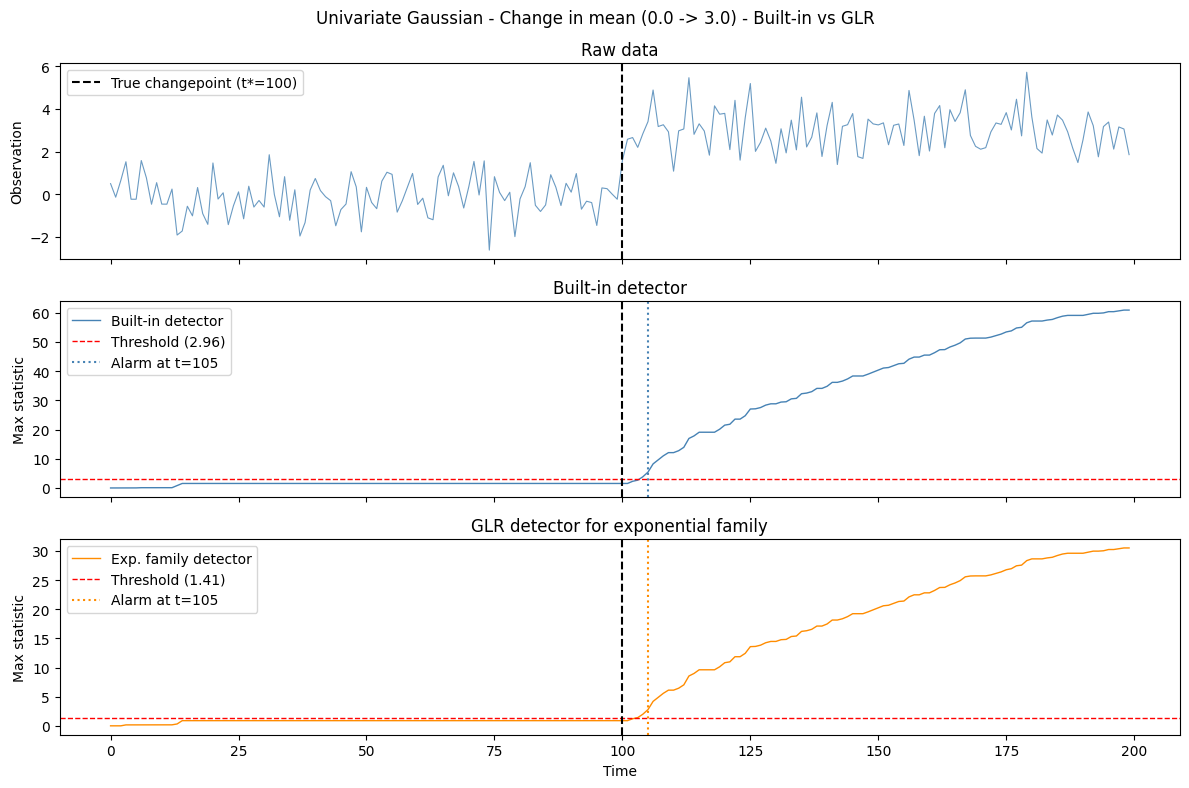


True changepoint:           t* = 100
Built-in detector alarm:    t  = 105
Exp. family detector alarm: t  = 105


In [5]:
# Univariate Gaussian (change in mean, known variance) - Example
import matplotlib.pyplot as plt

# Simulation settings
np.random.seed(42)
N_nvg          = 200
K_cal_nvg      = 5000
changepoint_nvg = N_nvg // 2
mu_pre         = 0.0
mu_post        = 3.0

# Simulate a single stream with a known changepoint
X = np.concatenate([
    np.random.normal(mu_pre,  1.0, changepoint_nvg),
    np.random.normal(mu_post, 1.0, N_nvg - changepoint_nvg)
])

# --- Built-in detector ---
det_builtin = make_univariate_mean_change_detector()
det_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Built-in penalty constant:    {det_builtin.penalty_constant:.4f}")

# --- Exponential family detector ---
@nb.njit
def h_gaussian(x):
    return x

@nb.njit
def A_gaussian(theta):
    return theta**2 / 2.0

det_expfam = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"GLR penalty constant: {det_expfam.penalty_constant:.4f}")

# --- Run both detectors on the same stream ---
stats_builtin = []
t_alarm_builtin = None
for i in range(N_nvg):
    det_builtin.update(X[i])
    stats_builtin.append(det_builtin.max_statistic)
    if det_builtin.alarm and t_alarm_builtin is None:
        t_alarm_builtin = det_builtin.t

stats_expfam = []
t_alarm_expfam = None
for i in range(N_nvg):
    det_expfam.update(X[i])
    stats_expfam.append(det_expfam.max_statistic)
    if det_expfam.alarm and t_alarm_expfam is None:
        t_alarm_expfam = det_expfam.t

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Univariate Gaussian - Change in mean ({mu_pre} -> {mu_post}) - Built-in vs GLR")

# Panel 1: raw data
axes[0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5,
                label=f"True changepoint (t*={changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

# Panel 2: built-in detector
axes[1].plot(stats_builtin, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[1].axhline(det_builtin.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_builtin.penalty_constant:.2f})")
axes[1].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_builtin is not None:
    axes[1].axvline(t_alarm_builtin, color="steelblue", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_builtin}")
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("Built-in detector")

# Panel 3: exponential family detector
axes[2].plot(stats_expfam, color="darkorange", linewidth=1.0, label="Exp. family detector")
axes[2].axhline(det_expfam.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_expfam.penalty_constant:.2f})")
axes[2].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_expfam is not None:
    axes[2].axvline(t_alarm_expfam, color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_expfam}")
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("GLR detector for exponential family")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:           t* = {changepoint_nvg}")
print(f"Built-in detector alarm:    t  = {t_alarm_builtin}")
print(f"Exp. family detector alarm: t  = {t_alarm_expfam}")

Running built-in detector for 1000 streams...
Running GLR detector for 1000 streams...
Running built-in detector (null) for 1000 streams...
Running GLR detector (null) for 1000 streams...

Metric                        Built-in          GLR
--------------------------------------------------
Detection rate                   0.959        0.955
False alarm rate                 0.041        0.045
Miss rate                        0.000        0.000
Mean delay                       3.021        2.869
Median delay                     3.000        3.000
Null false alarm rate            0.057        0.049
Total runtime (s)                2.726        2.744


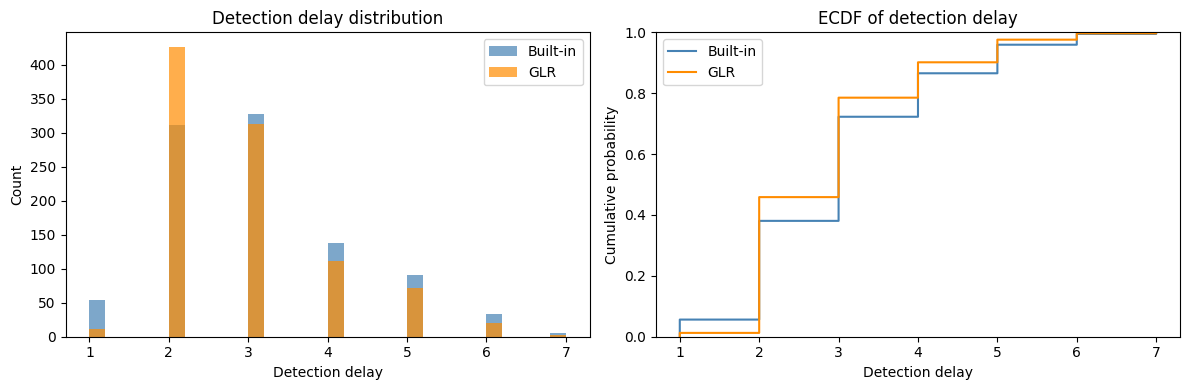

In [15]:
# Univariate Gaussian (change in mean, known variance) - Simulation study

K_nvg = 1000

def run_simulation(detector, X_streams):
    """
    Run a detector over K streams and record alarm times.
    Resets the detector between streams rather than recreating it.
    """
    alarm_times = []
    start = time.perf_counter()
    for k in range(len(X_streams)):
        detector.reset()
        t_alarm = None
        for i in range(X_streams.shape[1]):
            detector.update(X_streams[k, i])
            if detector.alarm and t_alarm is None:
                t_alarm = detector.t
                break
        alarm_times.append(t_alarm)
    elapsed = time.perf_counter() - start
    return alarm_times, elapsed

def compute_metrics(alarm_times, t_star, N):
    alarm_times = np.array([t if t is not None else np.nan for t in alarm_times])
    detected    = alarm_times <= N
    false_alarm = alarm_times <= t_star
    miss        = np.isnan(alarm_times)
    delay       = alarm_times[detected & ~false_alarm] - t_star
    return {
        "detection_rate":   np.mean(detected & ~false_alarm),
        "false_alarm_rate": np.mean(false_alarm),
        "miss_rate":        np.mean(miss),
        "mean_delay":       np.nanmean(delay),
        "median_delay":     np.nanmedian(delay),
    }

def compute_false_alarm_rate(alarm_times):
    return np.mean([t is not None for t in alarm_times])

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams = np.concatenate([
    np.random.normal(mu_pre,  1.0, (K_nvg, changepoint_nvg)),
    np.random.normal(mu_post, 1.0, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null = np.random.normal(0.0, 1.0, (K_nvg, N_nvg))

# --- Run simulations ---
print(f"Running built-in detector for {K_nvg} streams...")
alarm_times_builtin, elapsed_builtin = run_simulation(det_builtin, X_streams)

print(f"Running GLR detector for {K_nvg} streams...")
alarm_times_expfam, elapsed_expfam = run_simulation(det_expfam, X_streams)

print(f"Running built-in detector (null) for {K_nvg} streams...")
alarm_times_builtin_null, _ = run_simulation(det_builtin, X_null)

print(f"Running GLR detector (null) for {K_nvg} streams...")
alarm_times_expfam_null, _ = run_simulation(det_expfam, X_null)

# --- Compute metrics ---
metrics_builtin = compute_metrics(alarm_times_builtin, changepoint_nvg, N_nvg)
metrics_expfam  = compute_metrics(alarm_times_expfam,  changepoint_nvg, N_nvg)
far_builtin     = compute_false_alarm_rate(alarm_times_builtin_null)
far_expfam      = compute_false_alarm_rate(alarm_times_expfam_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'GLR':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin['detection_rate']:>12.3f} {metrics_expfam['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin['false_alarm_rate']:>12.3f} {metrics_expfam['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin['miss_rate']:>12.3f} {metrics_expfam['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin['mean_delay']:>12.3f} {metrics_expfam['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin['median_delay']:>12.3f} {metrics_expfam['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin:>12.3f} {far_expfam:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin:>12.3f} {elapsed_expfam:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin = [t - changepoint_nvg for t in alarm_times_builtin
                  if t is not None and t > changepoint_nvg]
delays_expfam  = [t - changepoint_nvg for t in alarm_times_expfam
                  if t is not None and t > changepoint_nvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delays_builtin, bins=30, color="steelblue", alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam,  bins=30, color="darkorange", alpha=0.7, label="GLR")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_builtin, color="steelblue", label="Built-in")
axes[1].ecdf(delays_expfam,  color="darkorange", label="GLR")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

Built-in penalty constant: 3.6966
Exp. family penalty constant: 19.7908


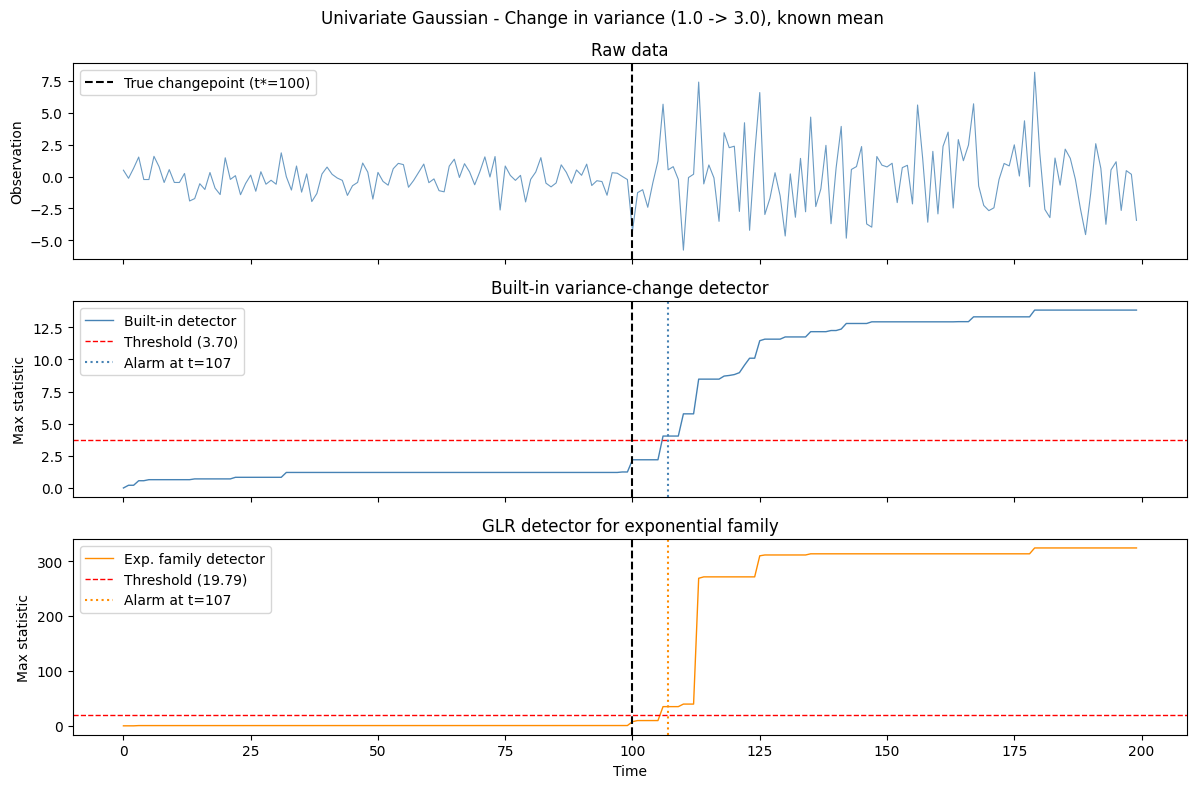


True changepoint:             t* = 100
Built-in detector alarm:      t  = 107
Exp. family detector alarm:   t  = 107


In [16]:
# Univariate Gaussian (change in variance, known mean) - Example

# Simulation settings
np.random.seed(42)
N_uvg           = 200
K_cal_uvg       = 5000
changepoint_uvg = N_uvg // 2
sigma_pre       = 1.0
sigma_post      = 3.0

# Simulate a single stream with a known changepoint
X = np.concatenate([
    np.random.normal(0.0, sigma_pre,  changepoint_uvg),
    np.random.normal(0.0, sigma_post, N_uvg - changepoint_uvg)
])

# --- Exponential family functions for variance change ---
@nb.njit
def h_variance(x):
    return np.array([x[0]**2])

@nb.njit
def A_variance(theta):
    return -0.5 * np.log(-2.0 * min(theta, -1e-10))

@nb.njit
def A_prime_variance(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

@nb.njit
def A_dprime_variance(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# --- Built-in detector ---
det_builtin_var = make_univariate_variance_change_detector()
det_builtin_var.calibrate_false_alarm(
    alpha=0.05,
    N=N_uvg,
    K=K_cal_uvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Built-in penalty constant: {det_builtin_var.penalty_constant:.4f}")

# --- Exponential family detector ---
det_expfam_var = make_exponential_family_detector(
    p=1,
    h=h_variance,
    A=A_variance,
    v=1,
    A_prime=A_prime_variance,
    A_dprime=A_dprime_variance,
    theta_init=-0.5,  # corresponds to sigma=1, i.e. the null
)
det_expfam_var.calibrate_false_alarm(
    alpha=0.05,
    N=N_uvg,
    K=K_cal_uvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Exp. family penalty constant: {det_expfam_var.penalty_constant:.4f}")

# --- Run both detectors on the same stream ---
stats_builtin_var = []
t_alarm_builtin_var = None
for i in range(N_uvg):
    det_builtin_var.update(X[i])
    stats_builtin_var.append(det_builtin_var.max_statistic)
    if det_builtin_var.alarm and t_alarm_builtin_var is None:
        t_alarm_builtin_var = det_builtin_var.t

stats_expfam_var = []
t_alarm_expfam_var = None
for i in range(N_uvg):
    det_expfam_var.update(X[i])
    stats_expfam_var.append(det_expfam_var.max_statistic)
    if det_expfam_var.alarm and t_alarm_expfam_var is None:
        t_alarm_expfam_var = det_expfam_var.t

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Univariate Gaussian - Change in variance ({sigma_pre} -> {sigma_post}), known mean")

# Panel 1: raw data
axes[0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5,
                label=f"True changepoint (t*={changepoint_uvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

# Panel 2: built-in detector
axes[1].plot(stats_builtin_var, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[1].axhline(det_builtin_var.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_builtin_var.penalty_constant:.2f})")
axes[1].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_builtin_var is not None:
    axes[1].axvline(t_alarm_builtin_var, color="steelblue", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_builtin_var}")
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("Built-in variance-change detector")

# Panel 3: exponential family detector
axes[2].plot(stats_expfam_var, color="darkorange", linewidth=1.0, label="Exp. family detector")
axes[2].axhline(det_expfam_var.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_expfam_var.penalty_constant:.2f})")
axes[2].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_expfam_var is not None:
    axes[2].axvline(t_alarm_expfam_var, color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_expfam_var}")
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("GLR detector for exponential family")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:             t* = {changepoint_uvg}")
print(f"Built-in detector alarm:      t  = {t_alarm_builtin_var}")
print(f"Exp. family detector alarm:   t  = {t_alarm_expfam_var}")

Running built-in detector for 1000 streams...
Running GLR detector for 1000 streams...
Running built-in detector (null) for 1000 streams...
Running GLR detector (null) for 1000 streams...

Metric                        Built-in          GLR
--------------------------------------------------
Detection rate                   0.964        0.944
False alarm rate                 0.036        0.056
Miss rate                        0.000        0.000
Mean delay                       8.288        6.585
Median delay                     7.000        5.000
Null false alarm rate            0.048        0.047
Total runtime (s)                2.924        2.931


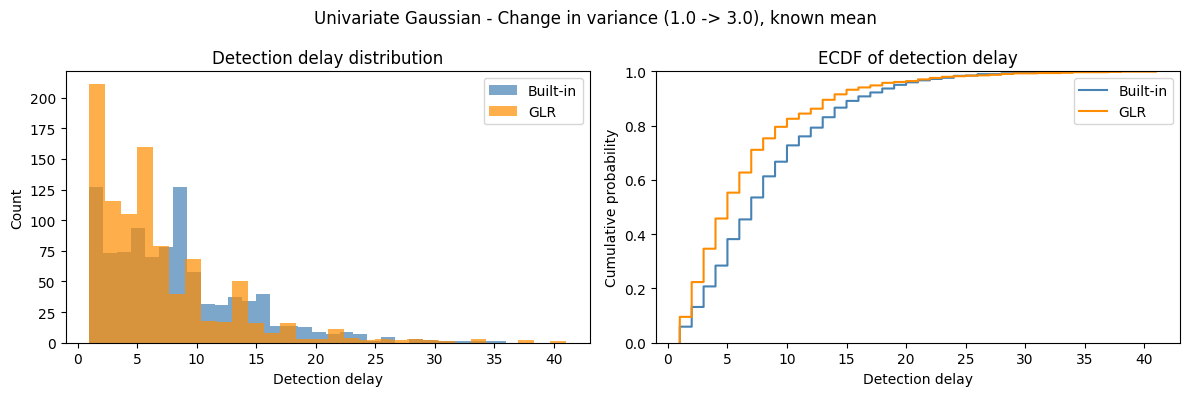

In [17]:


# Univariate Gaussian (change in variance, known mean) - Simulation study

K_uvg = 1000

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams_var = np.concatenate([
    np.random.normal(0.0, sigma_pre,  (K_uvg, changepoint_uvg)),
    np.random.normal(0.0, sigma_post, (K_uvg, N_uvg - changepoint_uvg))
], axis=1)
X_null_var = np.random.normal(0.0, sigma_pre, (K_uvg, N_uvg))

# --- Run simulations ---
print(f"Running built-in detector for {K_uvg} streams...")
alarm_times_builtin_var, elapsed_builtin_var = run_simulation(det_builtin_var, X_streams_var)

print(f"Running GLR detector for {K_uvg} streams...")
alarm_times_expfam_var, elapsed_expfam_var = run_simulation(det_expfam_var, X_streams_var)

print(f"Running built-in detector (null) for {K_uvg} streams...")
alarm_times_builtin_var_null, _ = run_simulation(det_builtin_var, X_null_var)

print(f"Running GLR detector (null) for {K_uvg} streams...")
alarm_times_expfam_var_null, _ = run_simulation(det_expfam_var, X_null_var)

# --- Compute metrics ---
metrics_builtin_var = compute_metrics(alarm_times_builtin_var, changepoint_uvg, N_uvg)
metrics_expfam_var  = compute_metrics(alarm_times_expfam_var,  changepoint_uvg, N_uvg)
far_builtin_var     = compute_false_alarm_rate(alarm_times_builtin_var_null)
far_expfam_var      = compute_false_alarm_rate(alarm_times_expfam_var_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'GLR':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin_var['detection_rate']:>12.3f} {metrics_expfam_var['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin_var['false_alarm_rate']:>12.3f} {metrics_expfam_var['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin_var['miss_rate']:>12.3f} {metrics_expfam_var['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin_var['mean_delay']:>12.3f} {metrics_expfam_var['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin_var['median_delay']:>12.3f} {metrics_expfam_var['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin_var:>12.3f} {far_expfam_var:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin_var:>12.3f} {elapsed_expfam_var:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin_var = [t - changepoint_uvg for t in alarm_times_builtin_var
                      if t is not None and t > changepoint_uvg]
delays_expfam_var  = [t - changepoint_uvg for t in alarm_times_expfam_var
                      if t is not None and t > changepoint_uvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Univariate Gaussian - Change in variance ({sigma_pre} -> {sigma_post}), known mean")

axes[0].hist(delays_builtin_var, bins=30, color="steelblue",  alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam_var,  bins=30, color="darkorange", alpha=0.7, label="GLR")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_builtin_var, color="steelblue",  label="Built-in")
axes[1].ecdf(delays_expfam_var,  color="darkorange", label="GLR")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Univariate Poisson, exponential, bernoulli - Simulation settings
# --- Shared settings ---
N_nvg           = 1000 # stream length during calibration and testing
changepoint_nvg = N_nvg // 2 # true changepoint location
K_cal_nvg       = 1000 # number of streams for false alarm calibration
K_nvg           = 1000 # number of streams for performance evaluation

# --- Distribution parameters ---
lambda_pre  = 2.0
lambda_post = 6.0

beta_pre    = 1.0
beta_post   = 3.0

p_pre       = 0.3
p_post      = 0.7

Poisson GLR penalty constant:      1.4354
Poisson CF penalty constant:       1.7872
Exponential GLR penalty constant:  4.2600
Exponential CF penalty constant:   2.5040
Bernoulli GLR penalty constant:    1.4309
Bernoulli CF penalty constant:     1.2477


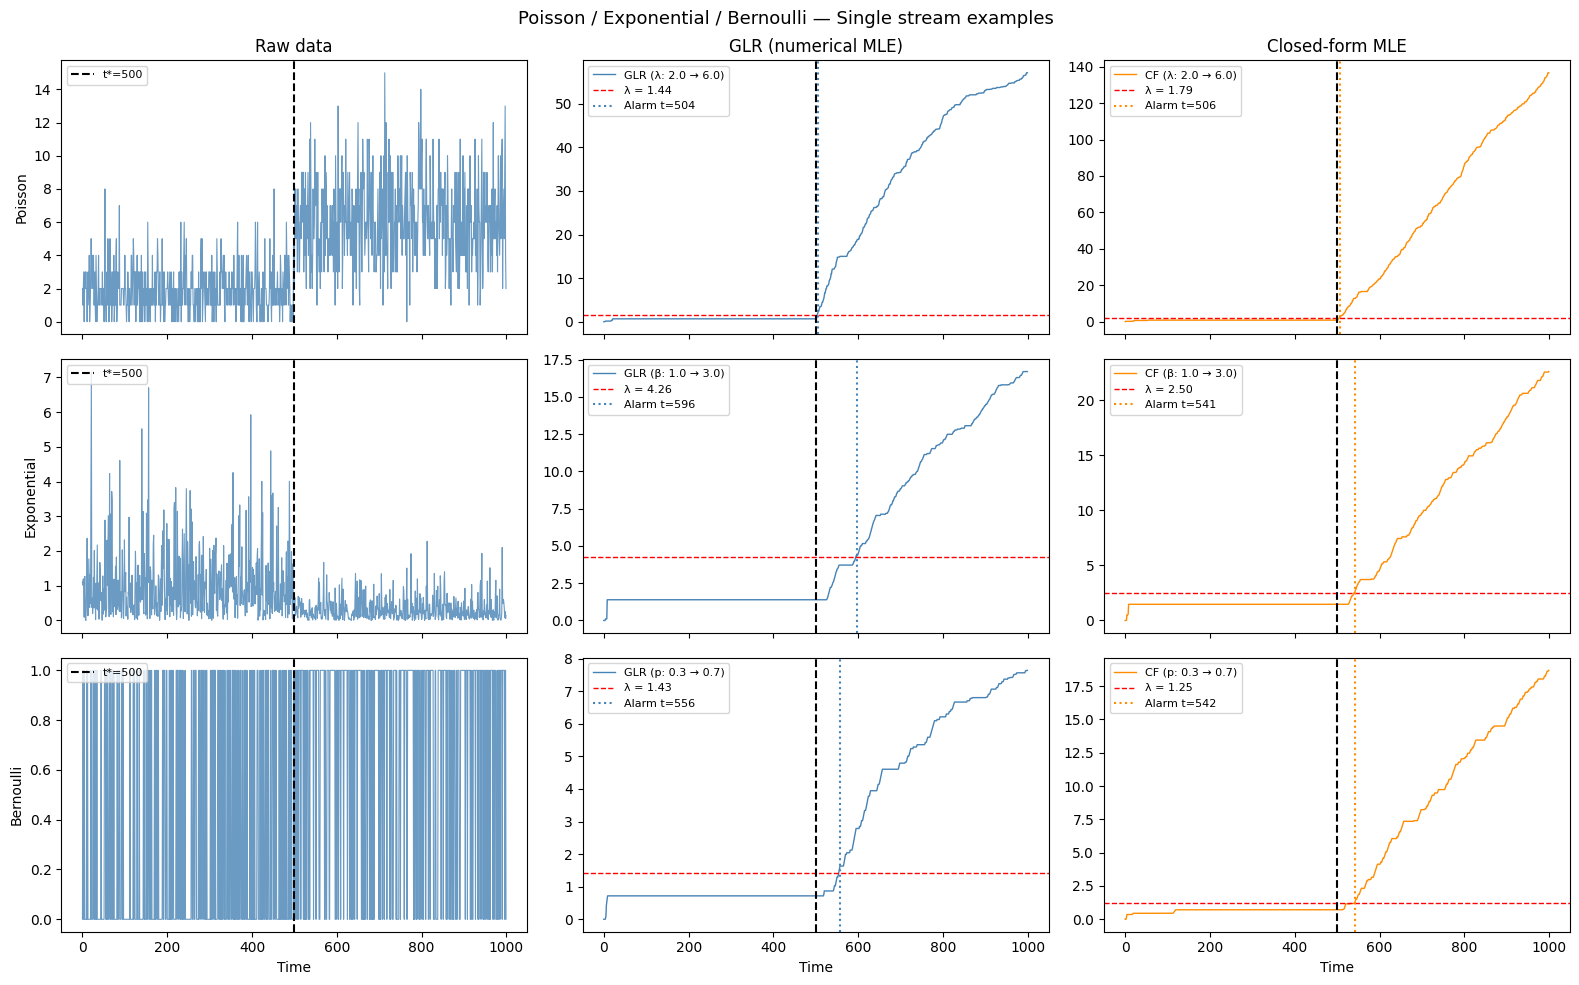


Distribution        t*    GLR alarm     CF alarm
------------------------------------------------
Poisson            500          504          506
Exponential        500          596          541
Bernoulli          500          556          542


In [19]:
# Univariate Poisson, Exponential, Bernoulli (change in parameter)- Examples
# -----------------------------------------------------------

# -----------------------------------------------------------
# GLR (numerical MLE) functions
# -----------------------------------------------------------

@nb.njit
def h_poisson(x):
    return np.array([x[0]])

@nb.njit
def A_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

# ---

@nb.njit
def h_exponential(x):
    return np.array([x[0]])

@nb.njit
def A_exponential(theta):
    return -np.log(-min(theta, -1e-10))

@nb.njit
def A_prime_exponential(theta):
    return -1.0 / min(theta, -1e-10)

@nb.njit
def A_dprime_exponential(theta):
    return 1.0 / min(theta, -1e-10)**2

# ---

@nb.njit
def h_bernoulli(x):
    return np.array([x[0]])

@nb.njit
def A_bernoulli(theta):
    if theta > 20.0:
        return theta + np.log(1.0 + np.exp(-theta))
    return np.log(1.0 + np.exp(theta))

@nb.njit
def A_prime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)**2

# -----------------------------------------------------------
# Closed-form MLE (analytical LR) functions
# -----------------------------------------------------------

@nb.njit
def h_cf_poisson(x):
    return np.array([x[0]])

@nb.njit
def f_cf_poisson(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0:
        return 0.0
    lam_hat_pre  = sum_pre[0]  / n_pre
    lam_hat_post = sum_post[0] / n_post
    if lam_hat_pre <= 0.0 or lam_hat_post <= 0.0:
        return 0.0
    return (n_pre  * (lam_hat_pre  * np.log(lam_hat_pre  / lambda_pre) - (lam_hat_pre  - lambda_pre))
          + n_post * (lam_hat_post * np.log(lam_hat_post / lambda_pre) - (lam_hat_post - lambda_pre)))

# ---

@nb.njit
def h_cf_exponential(x):
    return np.array([x[0]])

@nb.njit
def f_cf_exponential(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0 or sum_pre[0] <= 0.0 or sum_post[0] <= 0.0:
        return 0.0
    beta_hat_pre  = n_pre  / sum_pre[0]
    beta_hat_post = n_post / sum_post[0]
    return (n_pre  * (np.log(beta_hat_pre  / beta_pre) - 1.0 + beta_pre / beta_hat_pre)
          + n_post * (np.log(beta_hat_post / beta_pre) - 1.0 + beta_pre / beta_hat_post))

# ---

@nb.njit
def h_cf_bernoulli(x):
    return np.array([x[0]])

@nb.njit
def f_cf_bernoulli(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0:
        return 0.0
    p_hat_pre  = sum_pre[0]  / n_pre
    p_hat_post = sum_post[0] / n_post
    if p_hat_pre <= 0.0 or p_hat_pre >= 1.0 or p_hat_post <= 0.0 or p_hat_post >= 1.0:
        return 0.0
    return (sum_pre[0]  * np.log(p_hat_pre  / p_pre) + (n_pre  - sum_pre[0])  * np.log((1.0 - p_hat_pre)  / (1.0 - p_pre))
          + sum_post[0] * np.log(p_hat_post / p_pre) + (n_post - sum_post[0]) * np.log((1.0 - p_hat_post) / (1.0 - p_pre)))

# -----------------------------------------------------------
# Build and calibrate all detectors
# -----------------------------------------------------------

# Poisson
det_poisson_glr = make_exponential_family_detector(
    p=1, h=h_poisson, A=A_poisson, v=1,
    A_prime=A_prime_poisson, A_dprime=A_dprime_poisson,
)
det_poisson_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.poisson, null_kwargs={"lam": lambda_pre}
)
print(f"Poisson GLR penalty constant:      {det_poisson_glr.penalty_constant:.4f}")

det_poisson_cf = OnlineChangepointDetector(
    p=1, h=h_cf_poisson, f=f_cf_poisson,
    penalty=det_poisson_glr._state["penalty"],
    penalty_constant=1.0
)
det_poisson_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.poisson, null_kwargs={"lam": lambda_pre}
)
print(f"Poisson CF (closed form) penalty constant:       {det_poisson_cf.penalty_constant:.4f}")

# Exponential
det_exponential_glr = make_exponential_family_detector(
    p=1, h=h_exponential, A=A_exponential, v=1,
    A_prime=A_prime_exponential, A_dprime=A_dprime_exponential,
    theta_init=-1.0,
)
det_exponential_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.exponential, null_kwargs={"scale": 1.0 / beta_pre}
)
print(f"Exponential GLR penalty constant:  {det_exponential_glr.penalty_constant:.4f}")

det_exponential_cf = OnlineChangepointDetector(
    p=1, h=h_cf_exponential, f=f_cf_exponential,
    penalty=det_exponential_glr._state["penalty"],
    penalty_constant=1.0
)
det_exponential_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.exponential, null_kwargs={"scale": 1.0 / beta_pre}
)
print(f"Exponential CF penalty constant:   {det_exponential_cf.penalty_constant:.4f}")

# Bernoulli
det_bernoulli_glr = make_exponential_family_detector(
    p=1, h=h_bernoulli, A=A_bernoulli, v=1,
    A_prime=A_prime_bernoulli, A_dprime=A_dprime_bernoulli,
)
det_bernoulli_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.binomial, null_kwargs={"n": 1, "p": p_pre}
)
print(f"Bernoulli GLR penalty constant:    {det_bernoulli_glr.penalty_constant:.4f}")

det_bernoulli_cf = OnlineChangepointDetector(
    p=1, h=h_cf_bernoulli, f=f_cf_bernoulli,
    penalty=det_bernoulli_glr._state["penalty"],
    penalty_constant=1.0
)
det_bernoulli_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.binomial, null_kwargs={"n": 1, "p": p_pre}
)
print(f"Bernoulli CF penalty constant:     {det_bernoulli_cf.penalty_constant:.4f}")

# Poisson, Exponential, Bernoulli - Single stream examples
# Combined 3x3 plot: rows = distributions, cols = raw data / GLR / CF
# -----------------------------------------------------------

np.random.seed(20260317)
X_poisson_single = np.concatenate([
    np.random.poisson(lambda_pre,  changepoint_nvg),
    np.random.poisson(lambda_post, N_nvg - changepoint_nvg)
]).astype(float)

X_exponential_single = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  changepoint_nvg),
    np.random.exponential(1.0 / beta_post, N_nvg - changepoint_nvg)
])

X_bernoulli_single = np.concatenate([
    np.random.binomial(1, p_pre,  changepoint_nvg),
    np.random.binomial(1, p_post, N_nvg - changepoint_nvg)
]).astype(float)

# --- Run all detectors ---
def run_single_stream(det_glr, det_cf, X):
    stats_glr, stats_cf = [], []
    t_alarm_glr = t_alarm_cf = None
    det_glr.reset()
    det_cf.reset()
    for i in range(len(X)):
        det_glr.update(X[i])
        det_cf.update(X[i])
        stats_glr.append(det_glr.max_statistic)
        stats_cf.append(det_cf.max_statistic)
        if det_glr.alarm and t_alarm_glr is None:
            t_alarm_glr = det_glr.t
        if det_cf.alarm and t_alarm_cf is None:
            t_alarm_cf = det_cf.t
    return stats_glr, stats_cf, t_alarm_glr, t_alarm_cf

stats_poisson_glr,     stats_poisson_cf,     t_alarm_poisson_glr,     t_alarm_poisson_cf     = run_single_stream(det_poisson_glr,     det_poisson_cf,     X_poisson_single)
stats_exponential_glr, stats_exponential_cf, t_alarm_exponential_glr, t_alarm_exponential_cf = run_single_stream(det_exponential_glr, det_exponential_cf, X_exponential_single)
stats_bernoulli_glr,   stats_bernoulli_cf,   t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf   = run_single_stream(det_bernoulli_glr,   det_bernoulli_cf,   X_bernoulli_single)

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
fig.suptitle("Poisson / Exponential / Bernoulli — Single stream examples", fontsize=13)

rows = [
    (
        "Poisson",
        f"λ: {lambda_pre} → {lambda_post}",
        X_poisson_single,
        stats_poisson_glr,     stats_poisson_cf,
        t_alarm_poisson_glr,   t_alarm_poisson_cf,
        det_poisson_glr,       det_poisson_cf,
    ),
    (
        "Exponential",
        f"β: {beta_pre} → {beta_post}",
        X_exponential_single,
        stats_exponential_glr,     stats_exponential_cf,
        t_alarm_exponential_glr,   t_alarm_exponential_cf,
        det_exponential_glr,       det_exponential_cf,
    ),
    (
        "Bernoulli",
        f"p: {p_pre} → {p_post}",
        X_bernoulli_single,
        stats_bernoulli_glr,     stats_bernoulli_cf,
        t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf,
        det_bernoulli_glr,       det_bernoulli_cf,
    ),
]

for row_idx, (name, change_label, X, stats_glr, stats_cf,
              t_alarm_glr, t_alarm_cf, det_glr, det_cf) in enumerate(rows):

    # --- Col 0: raw data ---
    axes[row_idx, 0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
    axes[row_idx, 0].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5,
                             label=f"t*={changepoint_nvg}")
    axes[row_idx, 0].set_ylabel(name)
    axes[row_idx, 0].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 0].set_title("Raw data")

    # --- Col 1: GLR ---
    axes[row_idx, 1].plot(stats_glr, color="steelblue", linewidth=1.0, label=f"GLR ({change_label})")
    axes[row_idx, 1].axhline(det_glr.penalty_constant, color="red", linestyle="--", linewidth=1.0,
                             label=f"λ = {det_glr.penalty_constant:.2f}")
    axes[row_idx, 1].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
    if t_alarm_glr is not None:
        axes[row_idx, 1].axvline(t_alarm_glr, color="steelblue", linestyle=":",
                                 linewidth=1.5, label=f"Alarm t={t_alarm_glr}")
    axes[row_idx, 1].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 1].set_title("GLR (numerical MLE)")

    # --- Col 2: Closed-form MLE ---
    axes[row_idx, 2].plot(stats_cf, color="darkorange", linewidth=1.0, label=f"CF ({change_label})")
    axes[row_idx, 2].axhline(det_cf.penalty_constant, color="red", linestyle="--", linewidth=1.0,
                             label=f"λ = {det_cf.penalty_constant:.2f}")
    axes[row_idx, 2].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
    if t_alarm_cf is not None:
        axes[row_idx, 2].axvline(t_alarm_cf, color="darkorange", linestyle=":",
                                 linewidth=1.5, label=f"Alarm t={t_alarm_cf}")
    axes[row_idx, 2].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 2].set_title("Closed-form MLE")

for ax in axes[2, :]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

print(f"\n{'Distribution':<15} {'t*':>6} {'GLR alarm':>12} {'CF alarm':>12}")
print("-" * 48)
for name, t_glr, t_cf in [
    ("Poisson",     t_alarm_poisson_glr,     t_alarm_poisson_cf),
    ("Exponential", t_alarm_exponential_glr, t_alarm_exponential_cf),
    ("Bernoulli",   t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf),
]:
    print(f"{name:<15} {changepoint_nvg:>6} {str(t_glr):>12} {str(t_cf):>12}")

Running Poisson GLR detector (1000 streams)...
Running Poisson CF detector (1000 streams)...
Running Exponential GLR detector (1000 streams)...
Running Exponential CF detector (1000 streams)...
Running Bernoulli GLR detector (1000 streams)...
Running Bernoulli CF detector (1000 streams)...

Poisson (λ: 2.0 → 6.0)
Metric                               GLR  Closed-form MLE
---------------------------------------------------------
Detection rate                     0.946            0.945
False alarm rate                   0.054            0.055
Miss rate                          0.000            0.000
Mean delay                         5.771            6.814
Median delay                       5.000            6.000
Null FAR                           0.057            0.060
Runtime (s)                       15.000           13.560

Exponential (β: 1.0 → 3.0)
Metric                               GLR  Closed-form MLE
---------------------------------------------------------
Detection rate     

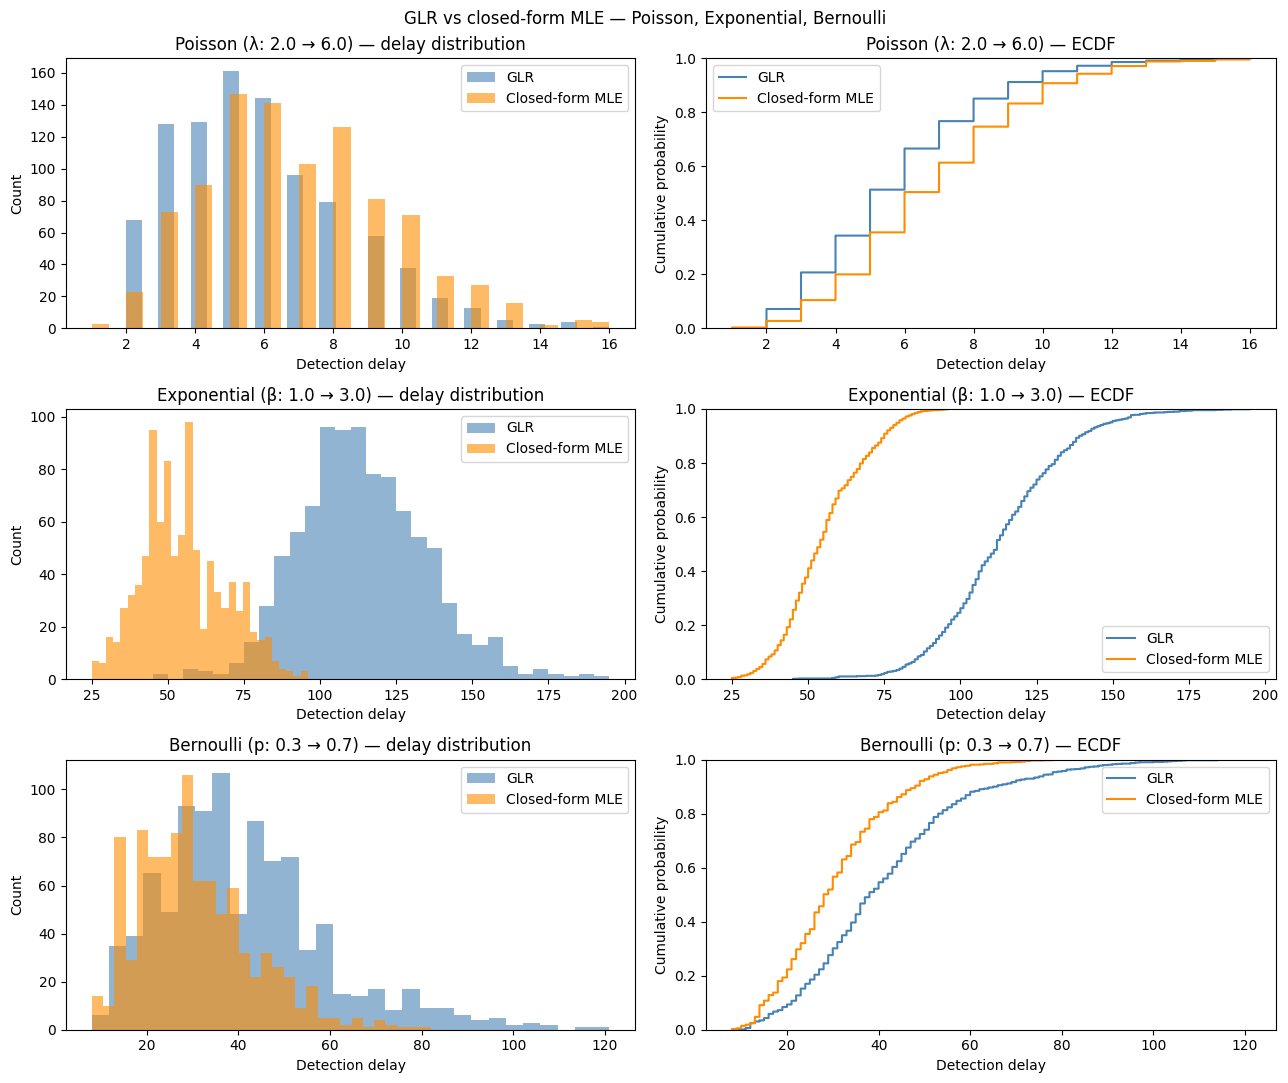

In [ ]:
# Poisson, Exponential, Bernoulli - Simulation studies
# -----------------------------------------------------------
K_nvg = 1000

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams_poisson = np.concatenate([
    np.random.poisson(lambda_pre,  (K_nvg, changepoint_nvg)),
    np.random.poisson(lambda_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_poisson = np.random.poisson(lambda_pre, (K_nvg, N_nvg)).astype(float)

X_streams_exponential = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  (K_nvg, changepoint_nvg)),
    np.random.exponential(1.0 / beta_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null_exponential = np.random.exponential(1.0 / beta_pre, (K_nvg, N_nvg))

X_streams_bernoulli = np.concatenate([
    np.random.binomial(1, p_pre,  (K_nvg, changepoint_nvg)),
    np.random.binomial(1, p_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_bernoulli = np.random.binomial(1, p_pre, (K_nvg, N_nvg)).astype(float)

# --- Run simulations ---
print(f"Running Poisson GLR detector ({K_nvg} streams)...")
alarm_times_poisson_glr, elapsed_poisson_glr         = run_simulation(det_poisson_glr,     X_streams_poisson)
alarm_times_poisson_glr_null, _                      = run_simulation(det_poisson_glr,     X_null_poisson)

print(f"Running Poisson CF detector ({K_nvg} streams)...")
alarm_times_poisson_cf, elapsed_poisson_cf           = run_simulation(det_poisson_cf,      X_streams_poisson)
alarm_times_poisson_cf_null, _                       = run_simulation(det_poisson_cf,      X_null_poisson)

print(f"Running Exponential GLR detector ({K_nvg} streams)...")
alarm_times_exponential_glr, elapsed_exponential_glr = run_simulation(det_exponential_glr, X_streams_exponential)
alarm_times_exponential_glr_null, _                  = run_simulation(det_exponential_glr, X_null_exponential)

print(f"Running Exponential CF detector ({K_nvg} streams)...")
alarm_times_exponential_cf, elapsed_exponential_cf   = run_simulation(det_exponential_cf,  X_streams_exponential)
alarm_times_exponential_cf_null, _                   = run_simulation(det_exponential_cf,  X_null_exponential)

print(f"Running Bernoulli GLR detector ({K_nvg} streams)...")
alarm_times_bernoulli_glr, elapsed_bernoulli_glr     = run_simulation(det_bernoulli_glr,   X_streams_bernoulli)
alarm_times_bernoulli_glr_null, _                    = run_simulation(det_bernoulli_glr,   X_null_bernoulli)

print(f"Running Bernoulli CF detector ({K_nvg} streams)...")
alarm_times_bernoulli_cf, elapsed_bernoulli_cf       = run_simulation(det_bernoulli_cf,    X_streams_bernoulli)
alarm_times_bernoulli_cf_null, _                     = run_simulation(det_bernoulli_cf,    X_null_bernoulli)

# --- Compute metrics ---
metrics_poisson_glr     = compute_metrics(alarm_times_poisson_glr,     changepoint_nvg, N_nvg)
metrics_poisson_cf      = compute_metrics(alarm_times_poisson_cf,      changepoint_nvg, N_nvg)
metrics_exponential_glr = compute_metrics(alarm_times_exponential_glr, changepoint_nvg, N_nvg)
metrics_exponential_cf  = compute_metrics(alarm_times_exponential_cf,  changepoint_nvg, N_nvg)
metrics_bernoulli_glr   = compute_metrics(alarm_times_bernoulli_glr,   changepoint_nvg, N_nvg)
metrics_bernoulli_cf    = compute_metrics(alarm_times_bernoulli_cf,    changepoint_nvg, N_nvg)

far_poisson_glr         = compute_false_alarm_rate(alarm_times_poisson_glr_null)
far_poisson_cf          = compute_false_alarm_rate(alarm_times_poisson_cf_null)
far_exponential_glr     = compute_false_alarm_rate(alarm_times_exponential_glr_null)
far_exponential_cf      = compute_false_alarm_rate(alarm_times_exponential_cf_null)
far_bernoulli_glr       = compute_false_alarm_rate(alarm_times_bernoulli_glr_null)
far_bernoulli_cf        = compute_false_alarm_rate(alarm_times_bernoulli_cf_null)

# --- Print results ---
for dist_name, metrics_glr, metrics_cf, far_glr, far_cf, elapsed_glr, elapsed_cf, change_label in [
    ("Poisson",     metrics_poisson_glr,     metrics_poisson_cf,     far_poisson_glr,     far_poisson_cf,     elapsed_poisson_glr,     elapsed_poisson_cf,     f"λ: {lambda_pre} → {lambda_post}"),
    ("Exponential", metrics_exponential_glr, metrics_exponential_cf, far_exponential_glr, far_exponential_cf, elapsed_exponential_glr, elapsed_exponential_cf, f"β: {beta_pre} → {beta_post}"),
    ("Bernoulli",   metrics_bernoulli_glr,   metrics_bernoulli_cf,   far_bernoulli_glr,   far_bernoulli_cf,   elapsed_bernoulli_glr,   elapsed_bernoulli_cf,   f"p: {p_pre} → {p_post}"),
]:
    print(f"\n{dist_name} ({change_label})")
    print(f"{'Metric':<25} {'GLR':>14} {'Closed-form MLE':>16}")
    print("-" * 57)
    for key, label in [
        ("detection_rate",   "Detection rate"),
        ("false_alarm_rate", "False alarm rate"),
        ("miss_rate",        "Miss rate"),
        ("mean_delay",       "Mean delay"),
        ("median_delay",     "Median delay"),
    ]:
        print(f"{label:<25} {metrics_glr[key]:>14.3f} {metrics_cf[key]:>16.3f}")
    print(f"{'Null FAR':<25} {far_glr:>14.3f} {far_cf:>16.3f}")
    print(f"{'Runtime (s)':<25} {elapsed_glr:>14.3f} {elapsed_cf:>16.3f}")

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle("GLR vs closed-form MLE — Poisson, Exponential, Bernoulli")

plot_data = [
    (alarm_times_poisson_glr,     alarm_times_poisson_cf,     "Poisson",     f"λ: {lambda_pre} → {lambda_post}"),
    (alarm_times_exponential_glr, alarm_times_exponential_cf, "Exponential", f"β: {beta_pre} → {beta_post}"),
    (alarm_times_bernoulli_glr,   alarm_times_bernoulli_cf,   "Bernoulli",   f"p: {p_pre} → {p_post}"),
]

for row, (at_glr, at_cf, name, change_label) in enumerate(plot_data):
    delays_glr = [t - changepoint_nvg for t in at_glr if t is not None and t > changepoint_nvg]
    delays_cf  = [t - changepoint_nvg for t in at_cf  if t is not None and t > changepoint_nvg]

    axes[row, 0].hist(delays_glr, bins=30, color="darkorange",  alpha=0.6, label="GLR")
    axes[row, 0].hist(delays_cf,  bins=30, color="steelblue", alpha=0.6, label="Closed-form MLE")
    axes[row, 0].set_xlabel("Detection delay")
    axes[row, 0].set_ylabel("Count")
    axes[row, 0].set_title(f"{name} ({change_label}) — delay distribution")
    axes[row, 0].legend()

    axes[row, 1].ecdf(delays_glr, color="darkorange",  label="GLR")
    axes[row, 1].ecdf(delays_cf,  color="steelblue", label="Closed-form MLE")
    axes[row, 1].set_xlabel("Detection delay")
    axes[row, 1].set_ylabel("Cumulative probability")
    axes[row, 1].set_title(f"{name} ({change_label}) — ECDF")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

### $v>1$:
1. Univariate Gaussian: Change in mean and variance
2. Multivariate Gaussian: Change in mean (known variance)
3. Multivariate Gaussian: Change in covariance matrix (known mean)

theta_init: [ 0.    -0.125]
Univariate mean+var GLR penalty constant:      1.6229
Univariate mean+var built-in penalty constant: 3.7244


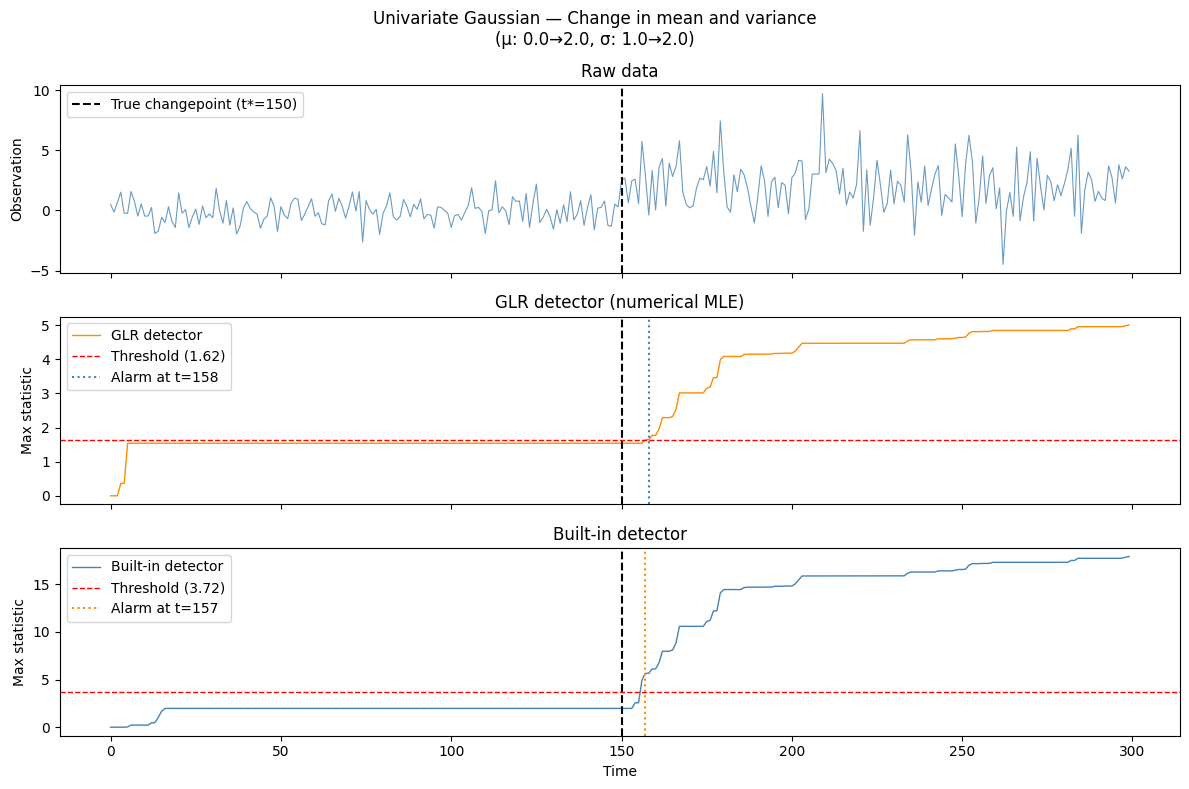


True changepoint:      t* = 150
GLR alarm:             t  = 158
Built-in alarm:        t  = 157


In [13]:
# -----------------------------------------------------------
# Case 1: Univariate Gaussian — change in mean AND variance
# theta = (mu/sigma^2, -1/(2*sigma^2))
# h(x)  = (x, x^2)
# A(theta) = -theta[0]^2 / (4*theta[1]) - 0.5*log(-2*theta[1])
# -----------------------------------------------------------

# --- Settings ---
N_v1 = 300
changepoint_v1 = N_v1 // 2
K_cal_v1 = 5000
K_v1 = 1000

mu_pre_uv = 0.0
sigma_pre_uv = 1.0
mu_post_uv = 2.0
sigma_post_uv = 2.0

# --- GLR functions ---
@nb.njit
def h_mv_gaussian_uv(x):
    return np.array([x[0], x[0] ** 2])


@nb.njit
def A_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        return np.nan
    return -t0**2 / (4.0 * t1) - 0.5 * np.log(-2.0 * t1)


@nb.njit
def A_grad_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        return np.array([np.nan, np.nan])
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])


@nb.njit
def A_hess_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        H_bad = np.empty((2, 2))
        H_bad[0, 0] = np.nan
        H_bad[0, 1] = np.nan
        H_bad[1, 0] = np.nan
        H_bad[1, 1] = np.nan
        return H_bad

    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# theta_init: corresponds to null mu, sigma
# Use a slightly inflated sigma for init to stay well away from boundary
_sigma2_init_uv = (sigma_pre_uv * 2.0) ** 2  # use 2*sigma as init
_mu_init_uv = 0.0
_theta_init_uv = np.array([
    _mu_init_uv / _sigma2_init_uv,
    -1.0 / (2.0 * _sigma2_init_uv),
])
print(f"theta_init: {_theta_init_uv}")  # should be [0.0, -0.125]

# --- Build and calibrate detectors ---
det_uv_glr = make_exponential_family_detector(
    p=1,
    h=h_mv_gaussian_uv,
    A=A_mv_gaussian_uv,
    v=2,
    A_grad=A_grad_mv_gaussian_uv,
    A_hess=A_hess_mv_gaussian_uv,
    theta_init=_theta_init_uv,
)
det_uv_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_v1,
    K=K_cal_v1,
    null_dist=np.random.normal,
    null_kwargs={"loc": mu_pre_uv, "scale": sigma_pre_uv},
)
print(f"Univariate mean+var GLR penalty constant:      {det_uv_glr.penalty_constant:.4f}")

det_uv_builtin = make_univariate_mean_or_variance_change_detector()
det_uv_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_v1,
    K=K_cal_v1,
    null_dist=np.random.normal,
    null_kwargs={"loc": mu_pre_uv, "scale": sigma_pre_uv},
)
print(f"Univariate mean+var built-in penalty constant: {det_uv_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_uv = np.concatenate(
    [
        np.random.normal(mu_pre_uv, sigma_pre_uv, changepoint_v1),
        np.random.normal(mu_post_uv, sigma_post_uv, N_v1 - changepoint_v1),
    ]
)

stats_uv_glr = []
stats_uv_builtin = []
t_alarm_uv_glr = None
t_alarm_uv_builtin = None

det_uv_glr.reset()
det_uv_builtin.reset()
for i in range(N_v1):
    det_uv_glr.update(X_uv[i])
    det_uv_builtin.update(X_uv[i])
    stats_uv_glr.append(det_uv_glr.max_statistic)
    stats_uv_builtin.append(det_uv_builtin.max_statistic)
    if det_uv_glr.alarm and t_alarm_uv_glr is None:
        t_alarm_uv_glr = det_uv_glr.t
    if det_uv_builtin.alarm and t_alarm_uv_builtin is None:
        t_alarm_uv_builtin = det_uv_builtin.t

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Univariate Gaussian — Change in mean and variance\n"
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)

axes[0].plot(X_uv, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_v1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"True changepoint (t*={changepoint_v1})",
)
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

axes[1].plot(stats_uv_glr, color="darkorange", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_uv_glr.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_uv_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_v1, color="black", linestyle="--", linewidth=1.5)
if t_alarm_uv_glr is not None:
    axes[1].axvline(
        t_alarm_uv_glr,
        color="steelblue",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_uv_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")

axes[2].plot(stats_uv_builtin, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_uv_builtin.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_uv_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_v1, color="black", linestyle="--", linewidth=1.5)
if t_alarm_uv_builtin is not None:
    axes[2].axvline(
        t_alarm_uv_builtin,
        color="darkorange",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_uv_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:      t* = {changepoint_v1}")
print(f"GLR alarm:             t  = {t_alarm_uv_glr}")
print(f"Built-in alarm:        t  = {t_alarm_uv_builtin}")

Running univariate mean+var GLR (1000 streams)...
Running univariate mean+var built-in (1000 streams)...

Univariate Gaussian — Change in mean and variance (μ: 0.0→2.0, σ: 1.0→2.0)
Metric                               GLR       Built-in
-------------------------------------------------------
Detection rate                     0.946          0.957
False alarm rate                   0.054          0.043
Miss rate                          0.000          0.000
Mean delay                        12.989          8.144
Median delay                      11.000          7.000
Null FAR                           0.042          0.051
Runtime (s)                       11.031          4.110


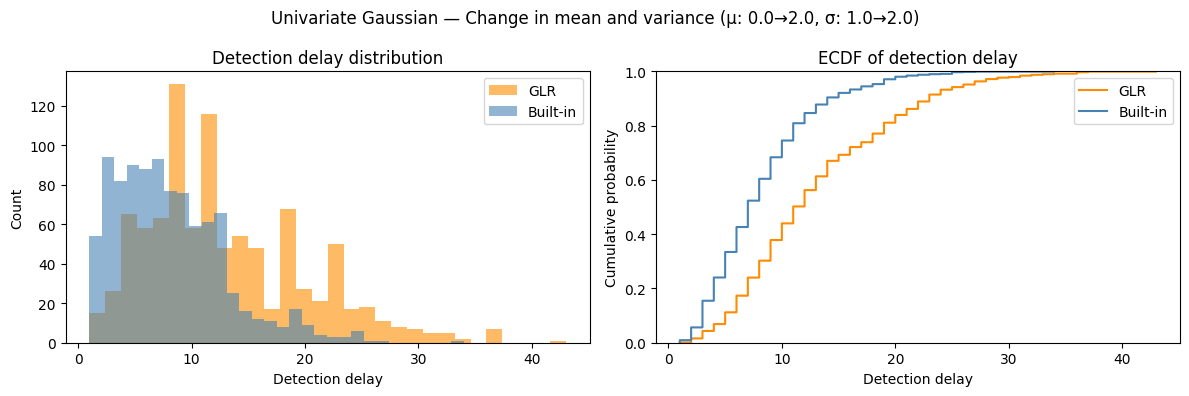

In [14]:
# Univariate Gaussian - Change in mean AND variance - Simulation study

import time
import numpy as np
import matplotlib.pyplot as plt
 
# --- Guard: catch missing variables early with a clear message ---
_required = [
    "det_uv_glr", "det_uv_builtin",
    "K_v1", "N_v1", "changepoint_v1",
    "mu_pre_uv", "mu_post_uv", "sigma_pre_uv", "sigma_post_uv",
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        f"The following variables must be defined before running this cell: {_missing}"
    )
 
# --- Local helpers (fallback definitions if earlier utility cell was not run) ---
if "run_simulation" not in globals():
    def run_simulation(detector, X_streams):
        start = time.perf_counter()
        alarm_times = []
        for k in range(X_streams.shape[0]):
            detector.reset()
            t_alarm = None
            for x in X_streams[k]:
                detector.update(x)
                if detector.alarm:
                    t_alarm = detector.t
                    break
            alarm_times.append(t_alarm)
        elapsed = time.perf_counter() - start
        return alarm_times, elapsed
 
if "compute_metrics" not in globals():
    def compute_metrics(alarm_times, t_star, N):
        alarm_times = np.array(
            [t if t is not None else np.nan for t in alarm_times], dtype=float
        )
        detected = ~np.isnan(alarm_times)
        # t_star is the first post-change index, so an alarm at t_star is a
        # true positive, not a false alarm — hence strict < here.
        false_alarm = detected & (alarm_times < t_star)
        miss = np.isnan(alarm_times)
        post_change = detected & (alarm_times >= t_star)
        delay = alarm_times[post_change] - t_star
 
        return {
            "detection_rate": float(np.mean(post_change)),
            "false_alarm_rate": float(np.mean(false_alarm)),
            "miss_rate": float(np.mean(miss)),
            "mean_delay": float(np.nanmean(delay)) if delay.size else np.nan,
            "median_delay": float(np.nanmedian(delay)) if delay.size else np.nan,
        }
 
if "compute_false_alarm_rate" not in globals():
    def compute_false_alarm_rate(alarm_times):
        alarm_times = np.array(
            [t if t is not None else np.nan for t in alarm_times], dtype=float
        )
        return float(np.mean(~np.isnan(alarm_times)))
 
# --- Settings / data ---
np.random.seed(42)
X_streams_uv = np.concatenate(
    [
        np.random.normal(mu_pre_uv, sigma_pre_uv, (K_v1, changepoint_v1)),
        np.random.normal(mu_post_uv, sigma_post_uv, (K_v1, N_v1 - changepoint_v1)),
    ],
    axis=1,
)
X_null_uv = np.random.normal(mu_pre_uv, sigma_pre_uv, (K_v1, N_v1))
 
print(f"Running univariate mean+var GLR ({K_v1} streams)...")
alarm_times_uv_glr, elapsed_uv_glr = run_simulation(det_uv_glr, X_streams_uv)
alarm_times_uv_glr_null, _ = run_simulation(det_uv_glr, X_null_uv)
 
print(f"Running univariate mean+var built-in ({K_v1} streams)...")
alarm_times_uv_bi, elapsed_uv_bi = run_simulation(det_uv_builtin, X_streams_uv)
alarm_times_uv_bi_null, _ = run_simulation(det_uv_builtin, X_null_uv)
 
metrics_uv_glr = compute_metrics(alarm_times_uv_glr, changepoint_v1, N_v1)
metrics_uv_bi = compute_metrics(alarm_times_uv_bi, changepoint_v1, N_v1)
far_uv_glr = compute_false_alarm_rate(alarm_times_uv_glr_null)
far_uv_bi = compute_false_alarm_rate(alarm_times_uv_bi_null)
 
print(
    f"\nUnivariate Gaussian — Change in mean and variance "
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)
print(f"{'Metric':<25} {'GLR':>14} {'Built-in':>14}")
print("-" * 55)
for key, label in [
    ("detection_rate",   "Detection rate"),
    ("false_alarm_rate", "False alarm rate"),
    ("miss_rate",        "Miss rate"),
    ("mean_delay",       "Mean delay"),
    ("median_delay",     "Median delay"),
]:
    print(f"{label:<25} {metrics_uv_glr[key]:>14.3f} {metrics_uv_bi[key]:>14.3f}")
print(f"{'Null FAR':<25} {far_uv_glr:>14.3f} {far_uv_bi:>14.3f}")
print(f"{'Runtime (s)':<25} {elapsed_uv_glr:>14.3f} {elapsed_uv_bi:>14.3f}")
 
delays_uv_glr = [
    t - changepoint_v1
    for t in alarm_times_uv_glr
    if t is not None and t >= changepoint_v1  # consistent with >= convention above
]
delays_uv_bi = [
    t - changepoint_v1
    for t in alarm_times_uv_bi
    if t is not None and t >= changepoint_v1
]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Univariate Gaussian — Change in mean and variance "
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)
 
axes[0].hist(delays_uv_glr, bins=30, color="darkorange", alpha=0.6, label="GLR")
axes[0].hist(delays_uv_bi,  bins=30, color="steelblue", alpha=0.6, label="Built-in")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()
 
if len(delays_uv_glr) > 0:
    axes[1].ecdf(delays_uv_glr, color="darkorange", label="GLR")
if len(delays_uv_bi) > 0:
    axes[1].ecdf(delays_uv_bi, color="steelblue", label="Built-in")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()
 
plt.tight_layout()
plt.show()

theta_init: [0. 0. 0.]
Multivariate mean GLR penalty constant:      0.7116
Multivariate mean built-in penalty constant: 3.1520


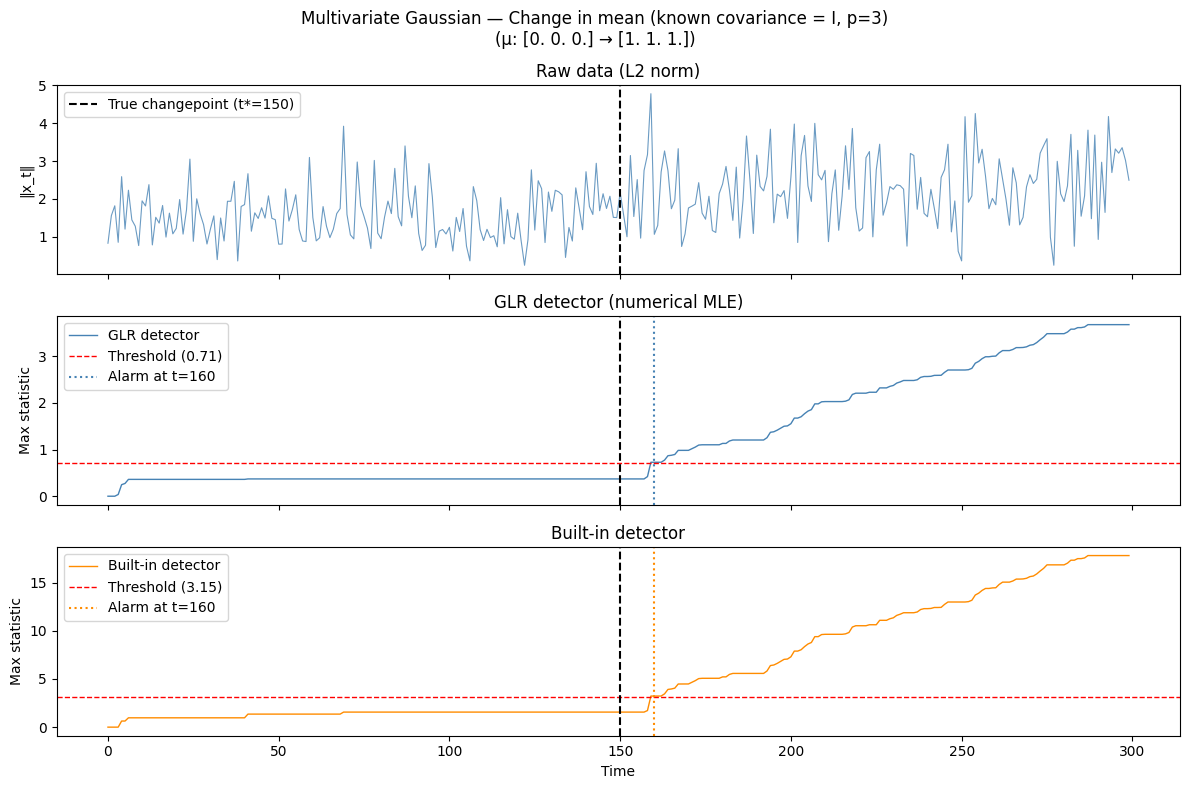


True changepoint:      t* = 150
GLR alarm:             t  = 160
Built-in alarm:        t  = 160


In [24]:
# Case 2: Multivariate Gaussian — change in mean (known covariance = I)
# theta = mu  (natural parameter = mean for identity covariance)
# h(x)  = x
# A(theta) = 0.5 * ||theta||^2
# -----------------------------------------------------------
 
# --- Settings ---
N_mv = 300
changepoint_mv = N_mv // 2
K_cal_mv = 5000
K_mv = 1000
 
p_mv = 3
mu_pre_mv  = np.zeros(p_mv)
mu_post_mv = np.array([1.0, 1.0, 1.0])
 
# --- GLR functions ---
@nb.njit
def h_mv_mean(x):
    return x.copy()
 
 
@nb.njit
def A_mv_mean(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s
 
 
@nb.njit
def A_grad_mv_mean(theta):
    return theta.copy()
 
 
@nb.njit
def A_hess_mv_mean(theta):
    return np.eye(theta.shape[0])
 
 
_theta_init_mv = mu_pre_mv.copy()
print(f"theta_init: {_theta_init_mv}")  # should be [0. 0. 0.]
 
# --- Build and calibrate detectors ---
det_mv_glr = make_exponential_family_detector(
    p=p_mv,
    h=h_mv_mean,
    A=A_mv_mean,
    v=p_mv,
    A_grad=A_grad_mv_mean,
    A_hess=A_hess_mv_mean,
    theta_init=_theta_init_mv,
)
det_mv_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal_mv,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0, "size": p_mv},
)
print(f"Multivariate mean GLR penalty constant:      {det_mv_glr.penalty_constant:.4f}")
 
det_mv_builtin = make_multivariate_mean_change_detector(p=p_mv, mode="known_variance")
det_mv_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal_mv,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0, "size": p_mv},
)
print(f"Multivariate mean built-in penalty constant: {det_mv_builtin.penalty_constant:.4f}")
 
# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_mv = np.concatenate(
    [
        np.random.multivariate_normal(mu_pre_mv,  np.eye(p_mv), changepoint_mv),
        np.random.multivariate_normal(mu_post_mv, np.eye(p_mv), N_mv - changepoint_mv),
    ]
)
 
stats_mv_glr     = []
stats_mv_builtin = []
t_alarm_mv_glr     = None
t_alarm_mv_builtin = None
 
det_mv_glr.reset()
det_mv_builtin.reset()
for i in range(N_mv):
    det_mv_glr.update(X_mv[i])
    det_mv_builtin.update(X_mv[i])
    stats_mv_glr.append(det_mv_glr.max_statistic)
    stats_mv_builtin.append(det_mv_builtin.max_statistic)
    if det_mv_glr.alarm and t_alarm_mv_glr is None:
        t_alarm_mv_glr = det_mv_glr.t
    if det_mv_builtin.alarm and t_alarm_mv_builtin is None:
        t_alarm_mv_builtin = det_mv_builtin.t
 
# Summarise the stream as its L2 norm over time for plotting
X_mv_norm = np.linalg.norm(X_mv, axis=1)
 
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Multivariate Gaussian — Change in mean (known covariance = I, p={p_mv})\n"
    f"(μ: {mu_pre_mv} → {mu_post_mv})"
)
 
axes[0].plot(X_mv_norm, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_mv,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"True changepoint (t*={changepoint_mv})",
)
axes[0].set_ylabel("‖x_t‖")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data (L2 norm)")
 
axes[1].plot(stats_mv_glr, color="steelblue", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_mv_glr.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_mv_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_mv, color="black", linestyle="--", linewidth=1.5)
if t_alarm_mv_glr is not None:
    axes[1].axvline(
        t_alarm_mv_glr,
        color="steelblue",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_mv_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")
 
axes[2].plot(stats_mv_builtin, color="darkorange", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_mv_builtin.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_mv_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_mv, color="black", linestyle="--", linewidth=1.5)
if t_alarm_mv_builtin is not None:
    axes[2].axvline(
        t_alarm_mv_builtin,
        color="darkorange",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_mv_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")
 
plt.tight_layout()
plt.show()
 
print(f"\nTrue changepoint:      t* = {changepoint_mv}")
print(f"GLR alarm:             t  = {t_alarm_mv_glr}")
print(f"Built-in alarm:        t  = {t_alarm_mv_builtin}")

GLR penalty constant:      0.7116
Built-in penalty constant: 3.1520

Running GLR detector (1000 streams)...
Running built-in detector (1000 streams)...

Multivariate Gaussian — Change in mean (known covariance = I, p=3)
μ: [0. 0. 0.] → [1. 1. 1.]

Metric                             GLR     Built-in
--------------------------------------------------
Detection rate                   0.960        0.950
False alarm rate                 0.040        0.050
Miss rate                        0.000        0.000
Mean delay                      12.105       12.113
Median delay                    11.000       11.000
Null FAR                         0.041        0.041
Runtime (s)                      6.044        4.128


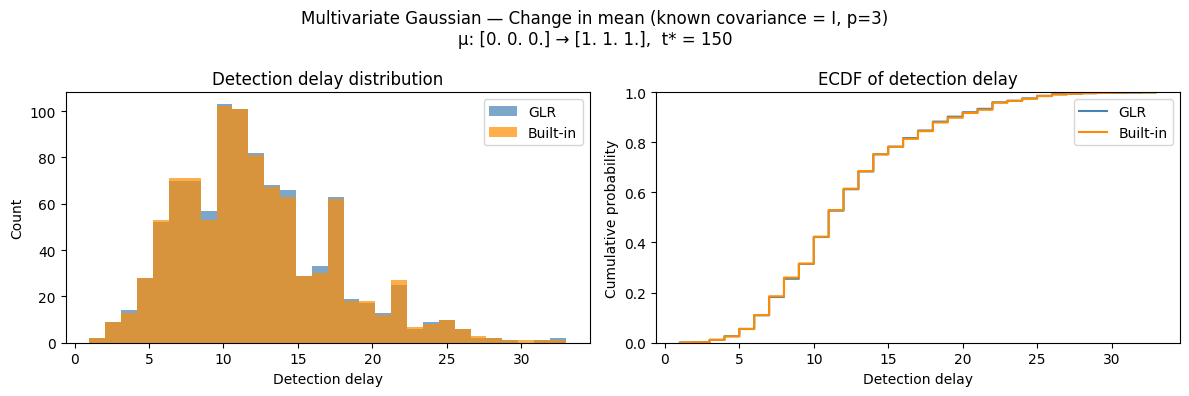

In [25]:
# Multivariate Gaussian - Change in mean (known covariance = I) - Simulation study

import time
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Settings
# -----------------------------------------------------------
N_mv        = 300
changepoint = N_mv // 2
K_cal       = 5000
K           = 1000
p           = 3

mu_pre  = np.zeros(p)
mu_post = np.ones(p)

# -----------------------------------------------------------
# Null sampler
# np.random.multivariate_normal requires mean and cov as
# positional args, so it can't be passed via null_kwargs.
# Wrap it in a no-arg callable instead.
# -----------------------------------------------------------
def null_dist():
    return np.random.multivariate_normal(mu_pre, np.eye(p))

# -----------------------------------------------------------
# GLR exponential family functions
# For MVN with known covariance = I:
#   h(x)      = x
#   A(theta)  = 0.5 * ||theta||^2
#   grad A    = theta
#   hess A    = I
# -----------------------------------------------------------
@nb.njit
def h_mv(x):
    return x.copy()

@nb.njit
def A_mv(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def A_grad_mv(theta):
    return theta.copy()

@nb.njit
def A_hess_mv(theta):
    return np.eye(theta.shape[0])

# theta_init at null mean (zeros)
theta_init = mu_pre.copy()

# -----------------------------------------------------------
# Build and calibrate detectors
# -----------------------------------------------------------
det_glr = make_exponential_family_detector(
    p=p,
    h=h_mv,
    A=A_mv,
    v=p,
    A_grad=A_grad_mv,
    A_hess=A_hess_mv,
    theta_init=theta_init,
)
det_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal,
    null_dist=null_dist,
)
print(f"GLR penalty constant:      {det_glr.penalty_constant:.4f}")

det_builtin = make_multivariate_mean_change_detector(p=p, mode="known_variance")
det_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal,
    null_dist=null_dist,
)
print(f"Built-in penalty constant: {det_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Helper functions
# -----------------------------------------------------------
def run_simulation(detector, X_streams):
    start = time.perf_counter()
    alarm_times = []
    for k in range(X_streams.shape[0]):
        detector.reset()
        t_alarm = None
        for x in X_streams[k]:
            detector.update(x)
            if detector.alarm:
                t_alarm = detector.t
                break
        alarm_times.append(t_alarm)
    elapsed = time.perf_counter() - start
    return alarm_times, elapsed

def compute_metrics(alarm_times, t_star):
    alarm_times = np.array(
        [t if t is not None else np.nan for t in alarm_times], dtype=float
    )
    detected    = ~np.isnan(alarm_times)
    # t_star is the first post-change index: alarm at t_star is a true positive
    false_alarm = detected & (alarm_times < t_star)
    miss        = np.isnan(alarm_times)
    post_change = detected & (alarm_times >= t_star)
    delay       = alarm_times[post_change] - t_star
    return {
        "detection_rate":   float(np.mean(post_change)),
        "false_alarm_rate": float(np.mean(false_alarm)),
        "miss_rate":        float(np.mean(miss)),
        "mean_delay":       float(np.nanmean(delay)) if delay.size else np.nan,
        "median_delay":     float(np.nanmedian(delay)) if delay.size else np.nan,
    }

def compute_far(alarm_times):
    alarm_times = np.array(
        [t if t is not None else np.nan for t in alarm_times], dtype=float
    )
    return float(np.mean(~np.isnan(alarm_times)))

# -----------------------------------------------------------
# Simulate streams
# -----------------------------------------------------------
np.random.seed(42)
X_streams = np.concatenate([
    np.random.multivariate_normal(mu_pre,  np.eye(p), (K, changepoint)),
    np.random.multivariate_normal(mu_post, np.eye(p), (K, N_mv - changepoint)),
], axis=1)  # shape (K, N_mv, p)

X_null = np.random.multivariate_normal(mu_pre, np.eye(p), (K, N_mv))
# shape (K, N_mv, p) — multivariate_normal with size=(K, N_mv) gives (K, N_mv, p)

# -----------------------------------------------------------
# Run simulations
# -----------------------------------------------------------
print(f"\nRunning GLR detector ({K} streams)...")
alarm_times_glr,     elapsed_glr     = run_simulation(det_glr,     X_streams)
alarm_times_glr_null, _              = run_simulation(det_glr,     X_null)

print(f"Running built-in detector ({K} streams)...")
alarm_times_builtin, elapsed_builtin = run_simulation(det_builtin, X_streams)
alarm_times_builtin_null, _          = run_simulation(det_builtin, X_null)

# -----------------------------------------------------------
# Metrics
# -----------------------------------------------------------
metrics_glr     = compute_metrics(alarm_times_glr,     changepoint)
metrics_builtin = compute_metrics(alarm_times_builtin, changepoint)
far_glr         = compute_far(alarm_times_glr_null)
far_builtin     = compute_far(alarm_times_builtin_null)

print(f"\nMultivariate Gaussian — Change in mean (known covariance = I, p={p})")
print(f"μ: {mu_pre} → {mu_post}")
print(f"\n{'Metric':<25} {'GLR':>12} {'Built-in':>12}")
print("-" * 50)
for key, label in [
    ("detection_rate",   "Detection rate"),
    ("false_alarm_rate", "False alarm rate"),
    ("miss_rate",        "Miss rate"),
    ("mean_delay",       "Mean delay"),
    ("median_delay",     "Median delay"),
]:
    print(f"{label:<25} {metrics_glr[key]:>12.3f} {metrics_builtin[key]:>12.3f}")
print(f"{'Null FAR':<25} {far_glr:>12.3f} {far_builtin:>12.3f}")
print(f"{'Runtime (s)':<25} {elapsed_glr:>12.3f} {elapsed_builtin:>12.3f}")

# -----------------------------------------------------------
# Plot
# -----------------------------------------------------------
delays_glr     = [t - changepoint for t in alarm_times_glr
                  if t is not None and t >= changepoint]
delays_builtin = [t - changepoint for t in alarm_times_builtin
                  if t is not None and t >= changepoint]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Multivariate Gaussian — Change in mean (known covariance = I, p={p})\n"
    f"μ: {mu_pre} → {mu_post},  t* = {changepoint}"
)

axes[0].hist(delays_glr,     bins=30, color="steelblue",  alpha=0.7, label="GLR")
axes[0].hist(delays_builtin, bins=30, color="darkorange", alpha=0.7, label="Built-in")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

if len(delays_glr) > 0:
    axes[1].ecdf(delays_glr,     color="steelblue",  label="GLR")
if len(delays_builtin) > 0:
    axes[1].ecdf(delays_builtin, color="darkorange", label="Built-in")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Multivariate Gaussian - Change in covariance (known mean = 0) - Single stream example
# -----------------------------------------------------------
# Case: Multivariate Gaussian — change in covariance (known mean = 0)
# theta = -0.5 * Sigma^{-1}  (natural parameter, flattened upper triangle)
# h(x)  = vech(x x^T)        (upper triangle of outer product, row-major)
# A(theta) = -0.5 * log det(-2 * Theta)  where Theta = mat(theta)
# -----------------------------------------------------------

# --- Settings ---
N_cov        = 300
changepoint_cov = N_cov // 2
K_cal_cov    = 5000
K_cov        = 1000
p_cov        = 3

mu_cov       = np.zeros(p_cov)           # known mean = 0
Sigma_pre    = np.eye(p_cov)             # pre:  identity
Sigma_post   = np.diag([1.0, 4.0, 9.0]) # post: inflated variances

# vech dimension: p*(p+1)/2
v_cov = p_cov * (p_cov + 1) // 2        # = 6 for p=3

# --- Upper-triangle index pairs (row-major), used by h and theta_init ---
_triu_rows, _triu_cols = np.triu_indices(p_cov)

# --- GLR functions ---
@nb.njit
def h_cov(y):
    p = y.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            out[idx] = y[i] * y[j]
            idx += 1
    return out

@nb.njit
def A_cov(theta):
    """A(theta) = -0.5 * log det(-2 * Theta), Theta = mat(theta)."""
    p = 3  # fixed for this case
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld


@nb.njit
def _p_from_v(v):
    """Recover p from vech dimension v = p*(p+1)/2."""
    return int((-1.0 + (1.0 + 8.0 * v) ** 0.5) / 2.0)

@nb.njit
def _fill_sym(theta_vec, p):
    """Reconstruct symmetric matrix from upper-triangle vector."""
    Theta = np.zeros((p, p))
    idx = 0
    for i in range(p):
        for j in range(i, p):
            Theta[i, j] = theta_vec[idx]
            Theta[j, i] = theta_vec[idx]
            idx += 1
    return Theta

@nb.njit
def A_grad_cov(theta):
    """
    grad A = vech((-2*Theta)^{-1}) with off-diagonal entries doubled.
    Returns NaN vector if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    M_inv = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = -M_inv[i, i]
            else:
                g[idx] = -2.0 * M_inv[i, j]
            idx += 1
    return g

@nb.njit
def A_hess_cov(theta):
    """
    Hessian of A.
    H_{(i,j),(k,l)} = -2 * (M^{-1})_{ik} (M^{-1})_{jl} * c_{ij} * c_{kl}
    where c_{ij} = 1 if i==j else 2.
    Returns NaN matrix if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)

    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i
            cols[idx] = j
            idx += 1

    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H


# --- theta_init: corresponds to Sigma_pre = I, so Theta = -0.5 * I ---
_Theta_init = -0.5 * np.linalg.inv(Sigma_pre)
_theta_init_cov = np.array([
    _Theta_init[i, j]
    for i in range(p_cov)
    for j in range(i, p_cov)
], dtype=np.float64)
print(f"theta_init: {_theta_init_cov}")  # should be [-0.5, 0, 0, -0.5, 0, -0.5]

# --- Null sampler ---
def _null_cov():
    return np.random.multivariate_normal(mu_cov, Sigma_pre)

# --- Build and calibrate detectors ---
det_cov_glr = make_exponential_family_detector(
    p=p_cov,
    h=h_cov,
    A=A_cov,
    v=v_cov,
    A_grad=A_grad_cov,
    A_hess=A_hess_cov,
    theta_init=_theta_init_cov,
)
det_cov_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_cov,
    K=K_cal_cov,
    null_dist=_null_cov,
)
print(f"GLR penalty constant:      {det_cov_glr.penalty_constant:.4f}")

det_cov_builtin = make_multivariate_mean_or_covariance_change_detector(p=p_cov)
det_cov_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_cov,
    K=K_cal_cov,
    null_dist=_null_cov,
)
print(f"Built-in penalty constant: {det_cov_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_cov = np.concatenate([
    np.random.multivariate_normal(mu_cov, Sigma_pre,  changepoint_cov),
    np.random.multivariate_normal(mu_cov, Sigma_post, N_cov - changepoint_cov),
])  # shape (N_cov, p_cov)

stats_cov_glr     = []
stats_cov_builtin = []
t_alarm_cov_glr     = None
t_alarm_cov_builtin = None

det_cov_glr.reset()
det_cov_builtin.reset()
for i in range(N_cov):
    det_cov_glr.update(X_cov[i])
    det_cov_builtin.update(X_cov[i])
    stats_cov_glr.append(det_cov_glr.max_statistic)
    stats_cov_builtin.append(det_cov_builtin.max_statistic)
    if det_cov_glr.alarm and t_alarm_cov_glr is None:
        t_alarm_cov_glr = det_cov_glr.t
    if det_cov_builtin.alarm and t_alarm_cov_builtin is None:
        t_alarm_cov_builtin = det_cov_builtin.t

# Summarise stream as per-component squared norm (highlights variance change)
X_cov_sq = np.sum(X_cov ** 2, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Multivariate Gaussian — Change in covariance (known mean = 0, p={p_cov})\n"
    f"Σ: I → diag({np.diag(Sigma_post).tolist()})"
)

axes[0].plot(X_cov_sq, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_cov, color="black", linestyle="--", linewidth=1.5,
    label=f"True changepoint (t*={changepoint_cov})",
)
axes[0].set_ylabel("‖x_t‖²")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data (squared norm)")

axes[1].plot(stats_cov_glr, color="steelblue", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_cov_glr.penalty_constant, color="red", linestyle="--", linewidth=1.0,
    label=f"Threshold ({det_cov_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_cov, color="black", linestyle="--", linewidth=1.5)
if t_alarm_cov_glr is not None:
    axes[1].axvline(
        t_alarm_cov_glr, color="steelblue", linestyle=":", linewidth=1.5,
        label=f"Alarm at t={t_alarm_cov_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")

axes[2].plot(stats_cov_builtin, color="darkorange", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_cov_builtin.penalty_constant, color="red", linestyle="--", linewidth=1.0,
    label=f"Threshold ({det_cov_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_cov, color="black", linestyle="--", linewidth=1.5)
if t_alarm_cov_builtin is not None:
    axes[2].axvline(
        t_alarm_cov_builtin, color="darkorange", linestyle=":", linewidth=1.5,
        label=f"Alarm at t={t_alarm_cov_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:      t* = {changepoint_cov}")
print(f"GLR alarm:             t  = {t_alarm_cov_glr}")
print(f"Built-in alarm:        t  = {t_alarm_cov_builtin}")

theta_init: [-0.5 -0.  -0.  -0.5 -0.  -0.5]


In [ ]:
# -----------------------------------------------------------
# 6e. False alarm control check: one long null stream
#
# Goal:
# - Calibrate each detector at N_cal = 1000 under the null.
# - Run one long null stream (N_long = 100000).
# - Store both instantaneous and cumulative-max traces.
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
N_CAL = 1_000
K_CAL = 2_000
N_LONG = 100_000
SEED = 12345


def collect_lr_vs_threshold_trace(detector, x_stream):
    """
    Collect per-time traces from a detector run:
    - lr_best[t]: raw LR (f value) for the candidate maximizing f/penalty at time t
    - thr_best[t]: lambda * penalty for that same maximizing candidate
    - ratio_best[t]: max f/penalty at time t
    - stat_running[t]: detector's running max statistic (monotone)
    - lr_running[t]: cumulative max of lr_best (monotone)
    - thr_running[t]: cumulative max of thr_best (monotone)
    """
    detector.reset()

    n = len(x_stream)
    lr_best = np.full(n, np.nan)
    thr_best = np.full(n, np.nan)
    ratio_best = np.full(n, np.nan)
    stat_running = np.full(n, np.nan)

    first_alarm = None

    for i in range(n):
        detector.update(x_stream[i])

        # This is the detector's test statistic: running maximum over time.
        stat_running[i] = detector.max_statistic

        if detector.alarm and first_alarm is None:
            first_alarm = detector.t

        state = detector._state
        t = state["t"]

        if t <= 1 or len(state["grid_list"]) == 0:
            continue

        S_total = state["sum"]
        p = state["p"]
        f_fn = state["f"]
        pen_fn = state["penalty"]
        lam = state["penalty_constant"]

        best_ratio = -np.inf
        best_lr = np.nan
        best_thr = np.nan

        for j in range(len(state["grid_list"]) - 1, -1, -1):
            g = state["grid_list"][j] + t + 1
            b = t - g

            S_pre = state["sum_pre_list"][j]
            S_post = S_total - S_pre

            pen = pen_fn(b, t, p)
            if pen <= 0.0:
                continue

            lr = f_fn(S_pre, S_post, b, t)
            ratio = lr / pen

            if ratio > best_ratio:
                best_ratio = ratio
                best_lr = lr
                best_thr = lam * pen

        lr_best[i] = best_lr
        thr_best[i] = best_thr
        ratio_best[i] = best_ratio

    lr_running = np.maximum.accumulate(np.nan_to_num(lr_best, nan=0.0))
    thr_running = np.maximum.accumulate(np.nan_to_num(thr_best, nan=0.0))

    return {
        "lr": lr_best,
        "threshold": thr_best,
        "ratio": ratio_best,
        "stat_running": stat_running,
        "lr_running": lr_running,
        "threshold_running": thr_running,
        "first_alarm": first_alarm,
        "lambda": detector.penalty_constant,
    }


# --- Build and calibrate detectors for this experiment ---
det_builtin_long = make_univariate_mean_change_detector()
det_builtin_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

# Reuse the same exponential-family specification used earlier.
det_expfam_long = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

print(f"Built-in lambda (N_cal={N_CAL}):   {det_builtin_long.penalty_constant:.4f}")
print(f"Exp. family lambda (N_cal={N_CAL}): {det_expfam_long.penalty_constant:.4f}")

# --- One shared long null stream ---
rng = np.random.default_rng(SEED)
X_long_null = rng.normal(0.0, 1.0, N_LONG)

a = time.perf_counter()
trace_builtin = collect_lr_vs_threshold_trace(det_builtin_long, X_long_null)
elapsed_builtin = time.perf_counter() - a
print(f"Built-in long stream runtime: {elapsed_builtin:.2f} seconds")
trace_expfam = collect_lr_vs_threshold_trace(det_expfam_long, X_long_null)


Built-in lambda (N_cal=1000):   2.9488
Exp. family lambda (N_cal=1000): 1.6759
Built-in long stream runtime: 13.85 seconds


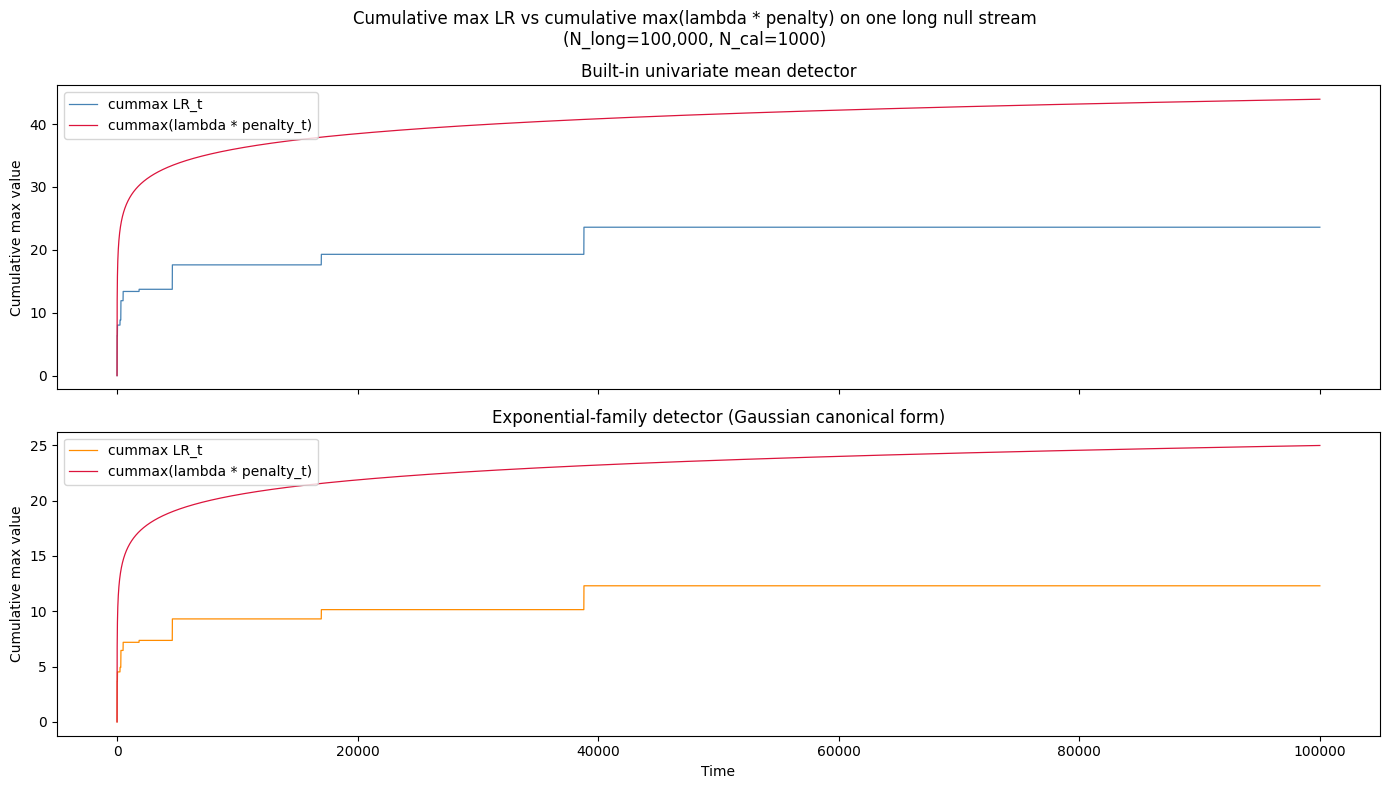


Built-in first alarm time:    None
Exp. family first alarm time: None
Stored monotone test statistic arrays:
  trace_builtin['stat_running'], trace_expfam['stat_running']


In [ ]:
time_axis = np.arange(1, N_LONG + 1)

# Use cumulative maxima so both lines are monotone increasing.
lr_builtin_max = trace_builtin.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["lr"], nan=0.0)))
thr_builtin_max = trace_builtin.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["threshold"], nan=0.0)))

lr_expfam_max = trace_expfam.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["lr"], nan=0.0)))
thr_expfam_max = trace_expfam.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["threshold"], nan=0.0)))

# --- Plot: cumulative maxima ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"Cumulative max f vs cumulative max(lambda * penalty) on one long null stream\n"
    f"(N_long={N_LONG:,}, N_cal={N_CAL})"
)

axes[0].plot(time_axis, lr_builtin_max, color="steelblue", linewidth=0.9, label="cummax LR_t")
axes[0].plot(time_axis, thr_builtin_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_builtin["first_alarm"] is not None:
    axes[0].axvline(trace_builtin["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[0].set_title("Built-in univariate mean detector")
axes[0].set_ylabel("Cumulative max value")
axes[0].legend(loc="upper left")

axes[1].plot(time_axis, lr_expfam_max, color="darkorange", linewidth=0.9, label="cummax LR_t")
axes[1].plot(time_axis, thr_expfam_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_expfam["first_alarm"] is not None:
    axes[1].axvline(trace_expfam["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[1].set_title("Exponential-family detector (Gaussian canonical form)")
axes[1].set_ylabel("Cumulative max value")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nBuilt-in first alarm time:    {trace_builtin['first_alarm']}")
print(f"Exp. family first alarm time: {trace_expfam['first_alarm']}")
print("Stored monotone test statistic arrays:")
print("  trace_builtin['stat_running'], trace_expfam['stat_running']")

In [ ]:
# --- Settings ---
K_MC_NEW = 800          # Number of NEW streams to simulate this run
N_MC = 100_000
SEED_MC = 20260317
ALPHA_TARGET = 0.05
APPEND = True          # False = overwrite existing results, True = append to existing results

In [ ]:
# -----------------------------------------------------------
# Simulation study: Monte Carlo false alarm control (built-in only)
# Full-pass simulation with disk-backed storage for plot variables
# Supports incremental runs: new results are appended to existing ones.
# -----------------------------------------------------------

import json
import numpy as np
from pathlib import Path
from time import perf_counter



# Calibration for this FAR experiment
N_CAL_FAR = 1_000
K_CAL_FAR = 2_000

# FAR checkpoints
T_CHECK = np.array([1_000, 2_000, 5_000, 10_000, 50_000, 100_000], dtype=np.int64)
T_CHECK = T_CHECK[T_CHECK <= N_MC]

# --- Output paths ---
results_dir = Path("results") / "mc_far_builtin"
results_dir.mkdir(parents=True, exist_ok=True)
stat_paths_file  = results_dir / "stat_paths.npy"
summary_file     = results_dir / "mc_far_summary.npz"
meta_file        = results_dir / "mc_far_meta.json"
alarm_times_file = results_dir / "first_alarm_times_partial.npy"

# --- Check for existing run ---
if APPEND and meta_file.exists():
    meta_prev = json.loads(meta_file.read_text())
    K_MC_prev = meta_prev["shape"][0]
    N_MC_prev = meta_prev["shape"][1]
    assert N_MC_prev == N_MC, (
        f"N_MC mismatch: existing run has N_MC={N_MC_prev}, current N_MC={N_MC}. "
        "Cannot append runs with different stream lengths."
    )
    print(f"Found existing run with K={K_MC_prev} streams. Appending {K_MC_NEW} new streams.")
    first_alarm_times_prev = np.load(alarm_times_file)
    assert len(first_alarm_times_prev) == K_MC_prev
    stat_paths_prev = np.load(stat_paths_file, mmap_mode="r")
else:
    if not APPEND and meta_file.exists():
        print(f"APPEND=False: overwriting existing results in {results_dir}.")
    else:
        print(f"No existing run found. Starting fresh with {K_MC_NEW} streams.")
    K_MC_prev = 0
    first_alarm_times_prev = np.empty(0, dtype=np.int64)
    stat_paths_prev = None

K_MC_TOTAL = K_MC_prev + K_MC_NEW

# --- Build and calibrate built-in detector ---
det_builtin_far = make_univariate_mean_change_detector()
det_builtin_far.calibrate_false_alarm(
    alpha=ALPHA_TARGET,
    N=N_CAL_FAR,
    K=K_CAL_FAR,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

lambda_far = det_builtin_far.penalty_constant
print(f"Built-in lambda (N_cal={N_CAL_FAR}): {lambda_far:.4f}")

# --- Create new memmap with full size, copy old data in chunks ---
stat_paths_new_file = results_dir / "stat_paths_new.npy"
stat_paths = np.lib.format.open_memmap(
    stat_paths_new_file,
    mode="w+",
    dtype=np.float32,
    shape=(K_MC_TOTAL, N_MC),
)
if stat_paths_prev is not None:
    chunk_size = 50
    for start_row in range(0, K_MC_prev, chunk_size):
        end_row = min(start_row + chunk_size, K_MC_prev)
        stat_paths[start_row:end_row, :] = stat_paths_prev[start_row:end_row, :]
    stat_paths.flush()
    del stat_paths_prev

# --- First alarm times: allocate full array, copy old ---
first_alarm_times = np.full(K_MC_TOTAL, N_MC + 1, dtype=np.int64)
if K_MC_prev > 0:
    first_alarm_times[:K_MC_prev] = first_alarm_times_prev

# --- Monte Carlo: simulate only new streams ---
rng_mc = np.random.default_rng(SEED_MC + K_MC_prev)  # offset seed so new streams differ

start = perf_counter()
for k_new in range(K_MC_NEW):
    k = K_MC_prev + k_new
    x_null = rng_mc.normal(0.0, 1.0, N_MC)
    det_builtin_far.reset()

    t_alarm = N_MC + 1
    for i, x in enumerate(x_null, start=1):
        det_builtin_far.update(x)
        stat_paths[k, i - 1] = det_builtin_far.max_statistic

        if t_alarm == N_MC + 1 and det_builtin_far.alarm:
            t_alarm = i

    first_alarm_times[k] = t_alarm

    if (k_new + 1) % 25 == 0:
        stat_paths.flush()
        np.save(alarm_times_file, first_alarm_times[:k + 1])
        print(f"Completed {k_new + 1}/{K_MC_NEW} new streams ({k + 1} total)")

stat_paths.flush()
np.save(alarm_times_file, first_alarm_times)
elapsed_mc = perf_counter() - start
print(f"New streams runtime: {elapsed_mc:.2f} seconds")

# --- Atomic swap: replace old stat_paths file with new ---
stat_paths_file.unlink(missing_ok=True)
stat_paths_new_file.rename(stat_paths_file)

# --- FAR summaries ---
far_at_checkpoints = np.array(
    [np.mean(first_alarm_times <= t_check) for t_check in T_CHECK],
    dtype=np.float64,
)

time_mc = np.arange(1, N_MC + 1)
alarmed = first_alarm_times[first_alarm_times <= N_MC]
counts = np.bincount(alarmed - 1, minlength=N_MC) if len(alarmed) > 0 else np.zeros(N_MC, dtype=np.int64)
far_t_builtin = np.cumsum(counts) / K_MC_TOTAL
far_final_builtin = far_t_builtin[-1]

stat_paths_loaded = np.load(stat_paths_file, mmap_mode="r")
final_max_stats = np.array(stat_paths_loaded[:, -1], dtype=np.float64)
mean_stat_path  = np.array(np.mean(stat_paths_loaded, axis=0), dtype=np.float64)
del stat_paths_loaded

# --- Save summary ---
np.savez_compressed(
    summary_file,
    first_alarm_times=first_alarm_times,
    T_CHECK=T_CHECK,
    far_at_checkpoints=far_at_checkpoints,
    time_mc=time_mc,
    far_t_builtin=far_t_builtin,
    final_max_stats=final_max_stats,
    mean_stat_path=mean_stat_path,
    lambda_far=np.array([lambda_far], dtype=np.float64),
    alpha_target=np.array([ALPHA_TARGET], dtype=np.float64),
    K_MC=np.array([K_MC_TOTAL], dtype=np.int64),
    N_MC=np.array([N_MC], dtype=np.int64),
    N_CAL_FAR=np.array([N_CAL_FAR], dtype=np.int64),
)

meta_payload = {
    "stat_paths_file": str(stat_paths_file),
    "summary_file": str(summary_file),
    "shape": [int(K_MC_TOTAL), int(N_MC)],
    "dtype": "float32",
    "note": "Use np.load(stat_paths_file, mmap_mode='r') to read without loading whole array into RAM."
}
meta_file.write_text(json.dumps(meta_payload, indent=2))

print(f"Total streams: {K_MC_TOTAL}")
print(f"Saved stream paths to: {stat_paths_file}")
print(f"Saved summary arrays to: {summary_file}")
print(f"Saved metadata to: {meta_file}")

Found existing run with K=200 streams. Appending 800 new streams.
Built-in lambda (N_cal=1000): 2.9488
Completed 25/800 new streams (225 total)
Completed 50/800 new streams (250 total)
Completed 75/800 new streams (275 total)
Completed 100/800 new streams (300 total)
Completed 125/800 new streams (325 total)
Completed 150/800 new streams (350 total)
Completed 175/800 new streams (375 total)
Completed 200/800 new streams (400 total)
Completed 225/800 new streams (425 total)
Completed 250/800 new streams (450 total)
Completed 275/800 new streams (475 total)
Completed 300/800 new streams (500 total)
Completed 325/800 new streams (525 total)
Completed 350/800 new streams (550 total)
Completed 375/800 new streams (575 total)
Completed 400/800 new streams (600 total)
Completed 425/800 new streams (625 total)
Completed 450/800 new streams (650 total)
Completed 475/800 new streams (675 total)
Completed 500/800 new streams (700 total)
Completed 525/800 new streams (725 total)
Completed 550/800 

In [ ]:
# Optional recovery cell: run this if kernel restarted and you want to re-plot without re-simulating.
from pathlib import Path
import numpy as np

def _human_size(n_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(n_bytes)
    for unit in units:
        if size < 1024.0 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024.0

results_dir = Path("results") / "mc_far_builtin"
stat_paths_file = results_dir / "stat_paths.npy"
summary_file = results_dir / "mc_far_summary.npz"

if stat_paths_file.exists() and summary_file.exists():
    stat_paths_size = stat_paths_file.stat().st_size
    summary_size = summary_file.stat().st_size

    stat_paths = np.load(stat_paths_file, mmap_mode="r")
    summary = np.load(summary_file)

    first_alarm_times = summary["first_alarm_times"]
    T_CHECK = summary["T_CHECK"]
    far_at_checkpoints = summary["far_at_checkpoints"]
    time_mc = summary["time_mc"]
    far_t_builtin = summary["far_t_builtin"]
    final_max_stats = summary["final_max_stats"]
    mean_stat_path = summary["mean_stat_path"]
    lambda_far = float(summary["lambda_far"][0])
    ALPHA_TARGET = float(summary["alpha_target"][0])
    K_MC = int(summary["K_MC"][0])
    N_MC = int(summary["N_MC"][0])
    far_final_builtin = float(far_t_builtin[-1])

    print(f"Recovered arrays from {results_dir}")
    print(f"stat_paths shape: {stat_paths.shape}, dtype: {stat_paths.dtype}")
    print(f"stat_paths file size: {_human_size(stat_paths_size)} ({stat_paths_size:,} bytes)")
    print(f"summary file size:   {_human_size(summary_size)} ({summary_size:,} bytes)")
else:
    print("Saved files not found yet. Run the Monte Carlo simulation cell first.")

Recovered arrays from results/mc_far_builtin
stat_paths shape: (200, 100000), dtype: float32
stat_paths file size: 76.29 MB (80,000,128 bytes)
summary file size:   155.77 KB (159,507 bytes)


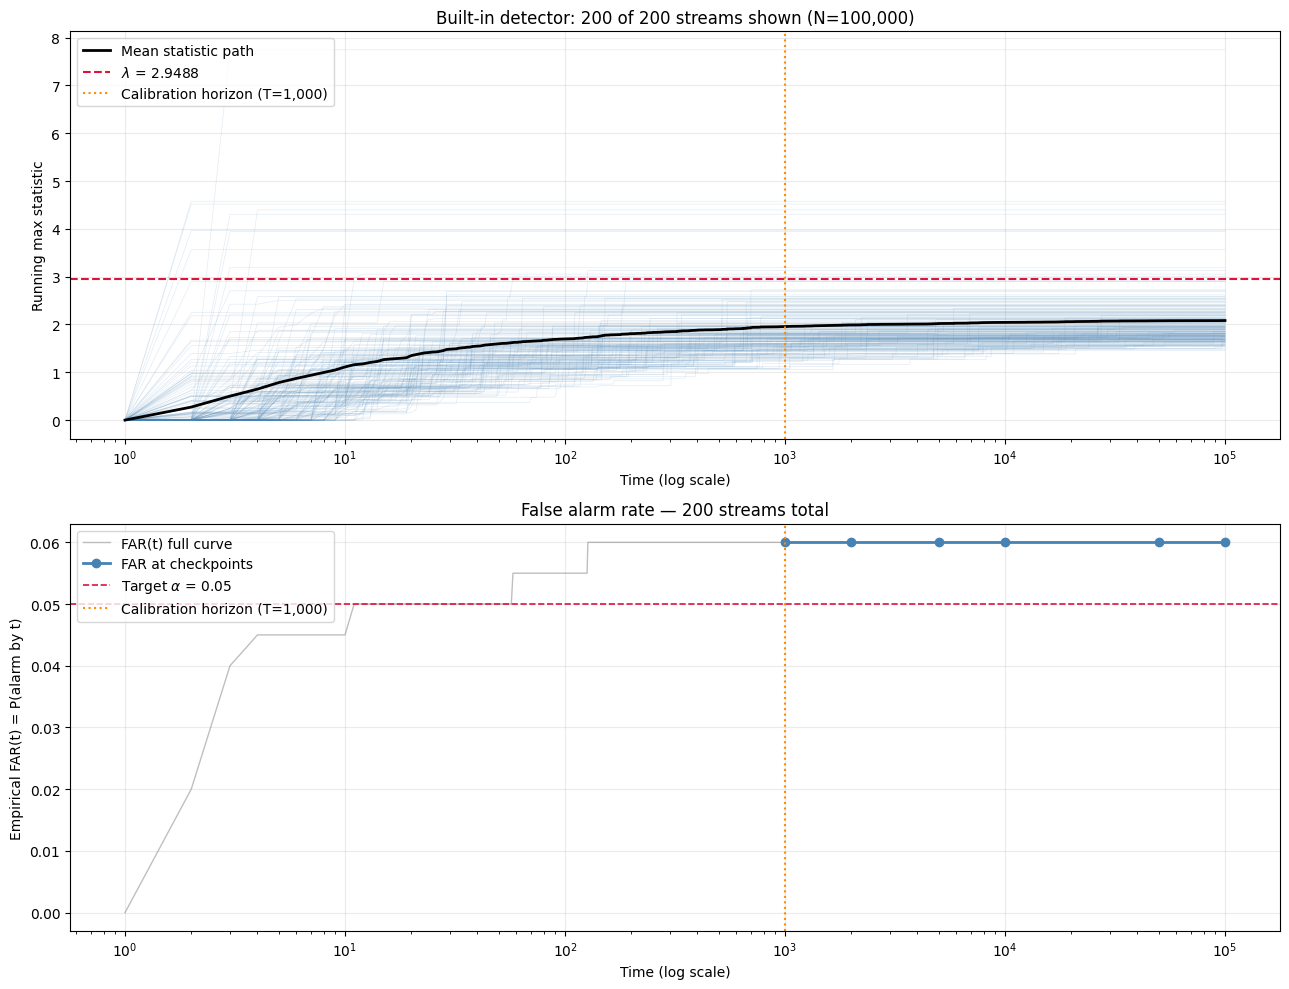


Final FAR at t=100,000: 0.0600

FAR at checkpoints:
  t=  1,000: FAR=0.0600 (12/200)
  t=  2,000: FAR=0.0600 (12/200)
  t=  5,000: FAR=0.0600 (12/200)
  t= 10,000: FAR=0.0600 (12/200)
  t= 50,000: FAR=0.0600 (12/200)
  t=100,000: FAR=0.0600 (12/200)


In [ ]:
# --- Plot settings ---
MAX_STREAMS_TO_PLOT = 200  # cap individual paths for readability at large K
plot_indices = (
    np.random.choice(K_MC_TOTAL, size=MAX_STREAMS_TO_PLOT, replace=False)
    if K_MC_TOTAL > MAX_STREAMS_TO_PLOT
    else np.arange(K_MC_TOTAL)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# --- Plot 1: sampled max statistic streams ---
stat_paths_mm = np.load(stat_paths_file, mmap_mode="r")
for k in plot_indices:
    axes[0].semilogx(time_mc, stat_paths_mm[k], color="steelblue", alpha=0.15, linewidth=0.5)
del stat_paths_mm

axes[0].semilogx(time_mc, mean_stat_path, color="black", linewidth=2.0, label="Mean statistic path")
axes[0].axhline(lambda_far, color="crimson", linestyle="--", linewidth=1.5, label=f"$\\lambda$ = {lambda_far:.4f}")
axes[0].axvline(N_CAL_FAR, color="darkorange", linestyle=":", linewidth=1.5, label=f"Calibration horizon (T={N_CAL_FAR:,})")
axes[0].set_xlabel("Time (log scale)")
axes[0].set_ylabel("Running max statistic")
axes[0].set_title(f"Built-in detector: {len(plot_indices)} of {K_MC_TOTAL} streams shown (N={N_MC:,})")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left")

# --- Plot 2: FAR curve ---
axes[1].semilogx(time_mc, far_t_builtin, color="gray", linewidth=1.0, alpha=0.5, label="FAR(t) full curve")
axes[1].semilogx(T_CHECK, far_at_checkpoints, color="steelblue", marker="o", linewidth=2.0, label="FAR at checkpoints")
axes[1].axhline(ALPHA_TARGET, color="crimson", linestyle="--", linewidth=1.2, label=f"Target $\\alpha$ = {ALPHA_TARGET}")
axes[1].axvline(N_CAL_FAR, color="darkorange", linestyle=":", linewidth=1.5, label=f"Calibration horizon (T={N_CAL_FAR:,})")
axes[1].set_xlabel("Time (log scale)")
axes[1].set_ylabel("Empirical FAR(t) = P(alarm by t)")
axes[1].set_title(f"False alarm rate — {K_MC_TOTAL} streams total")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nFinal FAR at t={N_MC:,}: {far_final_builtin:.4f}")
print("\nFAR at checkpoints:")
for t_check, far_val in zip(T_CHECK, far_at_checkpoints):
    n_alarm = int(np.sum(first_alarm_times <= t_check))
    print(f"  t={t_check:>7,}: FAR={far_val:.4f} ({n_alarm}/{K_MC_TOTAL})")

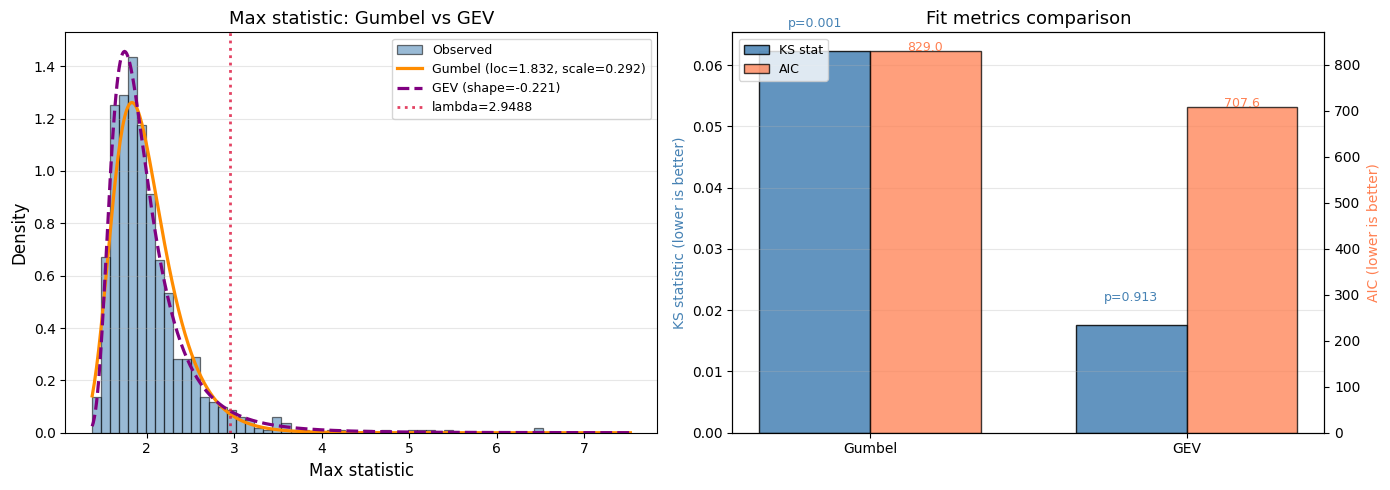


GUMBEL vs GEV COMPARISON
Gumbel: KS=0.062249, p=0.000822, AIC=828.98
GEV:    KS=0.017535, p=0.912796, AIC=707.58
Best by KS:  GEV
Best by AIC: GEV
--------------------------------------------------------------
GEV params: shape=-0.221055, loc=1.797778, scale=0.258337
Note: shape near 0 implies GEV is close to Gumbel.


In [ ]:
# --- Plot 6: Gumbel vs GEV fit for max statistic ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (50 bins)
x_range = np.linspace(final_max_stats.min(), final_max_stats.max() + 1.0, 500)
axes[0].hist(
    final_max_stats,
    bins=50,
    density=True,
    color="steelblue",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.9,
    label="Observed",
)

# Fit Gumbel (GEV with xi = 0)
loc_g, scale_g = stats.gumbel_r.fit(final_max_stats)
pdf_g = stats.gumbel_r.pdf(x_range, loc=loc_g, scale=scale_g)

# Fit full GEV
shape_gev, loc_gev, scale_gev = stats.genextreme.fit(final_max_stats)
pdf_gev = stats.genextreme.pdf(x_range, shape_gev, loc=loc_gev, scale=scale_gev)

axes[0].plot(
    x_range,
    pdf_g,
    color="darkorange",
    linewidth=2.3,
    label=f"Gumbel (loc={loc_g:.3f}, scale={scale_g:.3f})",
)
axes[0].plot(
    x_range,
    pdf_gev,
    color="purple",
    linewidth=2.3,
    linestyle="--",
    label=f"GEV (shape={shape_gev:.3f})",
)

axes[0].axvline(lambda_far, color="crimson", linestyle=":", linewidth=2.0, alpha=0.8, label=f"lambda={lambda_far:.4f}")
axes[0].set_title("Max statistic: Gumbel vs GEV", fontsize=13)
axes[0].set_xlabel("Max statistic", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Goodness-of-fit metrics
ks_g = stats.kstest(final_max_stats, lambda x: stats.gumbel_r.cdf(x, loc=loc_g, scale=scale_g))
ks_gev = stats.kstest(final_max_stats, lambda x: stats.genextreme.cdf(x, shape_gev, loc=loc_gev, scale=scale_gev))

pdf_vals_g = stats.gumbel_r.pdf(final_max_stats, loc=loc_g, scale=scale_g)
pdf_vals_gev = stats.genextreme.pdf(final_max_stats, shape_gev, loc=loc_gev, scale=scale_gev)
ll_g = np.sum(np.log(np.clip(pdf_vals_g, 1e-300, None)))
ll_gev = np.sum(np.log(np.clip(pdf_vals_gev, 1e-300, None)))
aic_g = 2 * 2 - 2 * ll_g      # params: loc, scale
aic_gev = 2 * 3 - 2 * ll_gev  # params: shape, loc, scale

# Bar comparison panel
labels = ["Gumbel", "GEV"]
ks_vals = [ks_g.statistic, ks_gev.statistic]
aic_vals = [aic_g, aic_gev]
x = np.arange(len(labels))
width = 0.35

bars1 = axes[1].bar(x - width / 2, ks_vals, width=width, color="steelblue", alpha=0.85, edgecolor="black", label="KS stat")
ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width / 2, aic_vals, width=width, color="coral", alpha=0.75, edgecolor="black", label="AIC")

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("KS statistic (lower is better)", color="steelblue")
ax2.set_ylabel("AIC (lower is better)", color="coral")
axes[1].set_title("Fit metrics comparison", fontsize=13)
axes[1].grid(axis="y", alpha=0.3)

for i, pval in enumerate([ks_g.pvalue, ks_gev.pvalue]):
    axes[1].text(i - width / 2, ks_vals[i] + 0.004, f"p={pval:.3f}", ha="center", fontsize=9, color="steelblue")
for i, val in enumerate(aic_vals):
    ax2.text(i + width / 2, val + 1.0, f"{val:.1f}", ha="center", fontsize=9, color="coral")

h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

best_ks = "GEV" if ks_gev.statistic < ks_g.statistic else "Gumbel"
best_aic = "GEV" if aic_gev < aic_g else "Gumbel"

print("\n" + "=" * 62)
print("GUMBEL vs GEV COMPARISON")
print("=" * 62)
print(f"Gumbel: KS={ks_g.statistic:.6f}, p={ks_g.pvalue:.6f}, AIC={aic_g:.2f}")
print(f"GEV:    KS={ks_gev.statistic:.6f}, p={ks_gev.pvalue:.6f}, AIC={aic_gev:.2f}")
print(f"Best by KS:  {best_ks}")
print(f"Best by AIC: {best_aic}")
print("-" * 62)
print(f"GEV params: shape={shape_gev:.6f}, loc={loc_gev:.6f}, scale={scale_gev:.6f}")
print("Note: shape near 0 implies GEV is close to Gumbel.")
print("=" * 62)

# New API Implementation

## General GLR detector for exponential families — `ExponentialFamilyGLR`

This section implements a **new-API-compatible** (`ScoreModel` protocol) version of the
general GLR changepoint detector for canonical exponential families developed above.

**Recap:** For a canonical exponential family $p(y|\theta) = \eta(y)\exp(\theta^\top h(y) - A(\theta))$, the GLR statistic for a candidate changepoint $b$ at time $t$ is:
$$f_b^{(t)} = \ell(\hat\theta_{\text{pre}}) + \ell(\hat\theta_{\text{post}}) - \ell(\hat\theta_{\text{null}})$$
where $\ell(\theta; S, n) = \theta^\top S - nA(\theta)$ and $\hat\theta$ are obtained via Newton's method from $\nabla A(\hat\theta) = \bar{h}$.

**New API contract** (from `gridcp.typing.ScoreModel`):
- `init_state()` → fresh state
- `update(state, x)` → updated state (accumulate sufficient statistics)
- `compute_penalised_scores(state, grid_states)` → array of penalised scores, one per candidate

**What the user provides:**
- `h` — sufficient statistic (`@nb.njit`)
- `A` — log-partition function (`@nb.njit`)
- For $v=1$ (scalar): `A_prime`, `A_dprime` (`@nb.njit`)
- For $v>1$ (vector): `A_grad`, `A_hess` (`@nb.njit`)

Everything else (MLE solver, GLR kernel, penalty) is built automatically at construction time.

In [4]:
# Imports
# =============================================================================

import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from dataclasses import dataclass

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold
from gridcp.scores import ExponentialFamilyGLR, ExponentialFamilyGLRState
from gridcp.scores._exponential_family_glr import _p_from_v, _fill_sym
from gridcp.scores._mean_cusum import MeanCUSUM

print("Imports done.")

Imports done.


## Structured Test Suite — ExponentialFamilyGLR

Comprehensive evaluation of `ExponentialFamilyGLR` across all exponential family scenarios.

**For each scenario** we:
1. Define the canonical `h`, `A`, `A'`, `A''` (or gradient/Hessian for vector cases)
2. **Calibrate** the threshold at alpha = 0.05 via `calibrate_threshold` (Monte Carlo, 2000 null paths)
3. **Single-stream plot**: 3-panel figure (raw data / EF detection statistic / reference, if available)
4. **Simulation study** (K = 1000 paths): detection delay histogram + ECDF + metrics table
5. **Timing comparison**: wall-clock seconds per stream (JIT warm-up excluded)

**Scenarios covered:**

| Nr | Family | v | Reference |
|----|--------|---|-----------|
| 1 | Gaussian mean (known var) | 1 | MeanCUSUM |
| 2 | Gaussian variance (known mean) | 1 | -- |
| 3 | Poisson | 1 | -- |
| 4 | Exponential | 1 | -- |
| 5 | Bernoulli | 1 | -- |
| 6 | Gaussian mean + variance | 2 | -- |
| 7 | MV Gaussian mean (known cov=I) | p=3 | MeanCUSUM |
| 8 | MV Gaussian covariance (known mean=0) | 6 | -- |

In [6]:
# Shared helpers for single-stream and simulation study cells

import time
import numpy as np
import matplotlib.pyplot as plt
from gridcp.detector import GridDetector
from gridcp.calibration import calibrate_threshold, mc_alarm_times

# ---- Constants ----
K_CAL   = 2000   # calibration paths
K_SIM   = 1000   # simulation paths
ALPHA   = 0.05   # false alarm prob
SEED    = 42
K_TIME  = 50     # timing repetitions
PARALLEL = True

# ---- Run one stream and collect outputs + max-score trace ----

def run_and_collect(data, detector):
    """Feed *data* (N, n_features) through *detector*, return (outputs, scores)."""
    state = detector.init_state()
    outputs, scores = [], []
    for t in range(len(data)):
        state, out = detector.update(state, data[t])
        outputs.append(out)
        scores.append(out["max_score"])
    return outputs, np.array(scores)


def first_alarm(outputs):
    for i, o in enumerate(outputs):
        if o["alarm"]:
            return i
    return None


# ---- Plotting: single-stream comparison ----

def plot_scenario(title, data, stats_ef, threshold_ef, alarm_ef, true_cp,
                  *, stats_ref=None, threshold_ref=None, alarm_ref=None,
                  ef_label="ExponentialFamilyGLR", ref_label="MeanCUSUM",
                  data_ylabel="Observation", data_transform=None):
    has_ref = stats_ref is not None
    nrows = 3 if has_ref else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 3.0 * nrows), sharex=True)
    fig.suptitle(title, fontsize=14)

    # Raw data
    raw = data_transform(data) if data_transform is not None else data[:, 0]
    axes[0].plot(raw, lw=0.6, color="steelblue")
    axes[0].axvline(true_cp, ls="--", color="black", label=f"True CP (t*={true_cp})")
    axes[0].legend(loc="upper left", fontsize=9)
    axes[0].set_ylabel(data_ylabel)
    axes[0].set_title("Raw data")

    # EF score
    axes[1].plot(stats_ef, lw=0.8, color="darkorange", label=f"{ef_label}")
    axes[1].axhline(threshold_ef, ls="--", color="red", lw=0.8,
                    label=f"Threshold ({threshold_ef:.2f})")
    if alarm_ef is not None:
        axes[1].axvline(alarm_ef, ls=":", color="darkorange", lw=1.2,
                        label=f"Alarm t={alarm_ef}")
    axes[1].axvline(true_cp, ls="--", color="black", lw=0.6)
    axes[1].legend(loc="upper left", fontsize=9)
    axes[1].set_ylabel("Max score")
    axes[1].set_title(ef_label)

    # Reference score
    if has_ref:
        axes[2].plot(stats_ref, lw=0.8, color="steelblue", label=ref_label)
        axes[2].axhline(threshold_ref, ls="--", color="red", lw=0.8,
                        label=f"Threshold ({threshold_ref:.2f})")
        if alarm_ref is not None:
            axes[2].axvline(alarm_ref, ls=":", color="steelblue", lw=1.2,
                            label=f"Alarm t={alarm_ref}")
        axes[2].axvline(true_cp, ls="--", color="black", lw=0.6)
        axes[2].legend(loc="upper left", fontsize=9)
        axes[2].set_ylabel("Max score")
        axes[2].set_title(ref_label)

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


# ---- Simulation study helper ----

def _compute_metrics(alarms, null_alarms, N, true_cp):
    K = len(alarms)
    Knull = len(null_alarms)
    # Only count alarms at or after the true CP as correct detections
    correct = alarms[(alarms < N) & (alarms >= true_cp)]
    false_pre_cp = np.sum((alarms < N) & (alarms < true_cp))  # alarms before CP
    n_correct = len(correct)
    delays = correct - true_cp
    null_fa = np.sum(null_alarms < N)
    return {
        "detection_rate": n_correct / K,
        "miss_rate": 1.0 - n_correct / K,
        "mean_delay": np.mean(delays) if n_correct > 0 else float("nan"),
        "median_delay": np.median(delays) if n_correct > 0 else float("nan"),
        "false_pre_cp": false_pre_cp / K,
        "null_FAR": null_fa / Knull if Knull > 0 else float("nan"),
    }


def run_sim_study(det_ef, det_ref, *, pre_sampler, post_sampler,
                  n_features, N, K, true_cp, rng=SEED):
    """Monte-Carlo simulation: alarm-time arrays for EF (and optionally ref)."""
    print(f"  ExponentialFamilyGLR: mc_alarm_times (K={K}) ...")
    alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler, post_sampler=post_sampler,
        changepoint=true_cp, parallel=PARALLEL, rng=rng,
    )
    null_alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler,
        parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
    )
    results = {"alarms_ef": alarms_ef, "null_alarms_ef": null_alarms_ef, "N": N, "true_cp": true_cp}

    if det_ref is not None:
        print(f"  Ref: mc_alarm_times (K={K}) ...")
        alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler, post_sampler=post_sampler,
            changepoint=true_cp, parallel=PARALLEL, rng=rng,
        )
        null_alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler,
            parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
        )
        results["alarms_ref"] = alarms_ref
        results["null_alarms_ref"] = null_alarms_ref
    return results


def plot_sim_study(results, title, *, ef_label="ExponentialFamilyGLR",
                   ref_label="MeanCUSUM"):
    N, true_cp = results["N"], results["true_cp"]
    K = len(results["alarms_ef"])
    has_ref = "alarms_ref" in results

    alarms_ef = results["alarms_ef"]
    m_ef = _compute_metrics(alarms_ef, results["null_alarms_ef"], N, true_cp)
    correct_ef = alarms_ef[(alarms_ef < N) & (alarms_ef >= true_cp)]
    delays_ef = correct_ef - true_cp

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  (K={K}, N={N}, CP={true_cp})", fontsize=13)

    axes[0].hist(delays_ef, bins=30, alpha=0.6, color="darkorange",
                 edgecolor="white", label=ef_label, density=True)
    axes[0].set_xlabel("Detection delay (samples)")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Detection delay histogram")

    sorted_ef = np.sort(delays_ef)
    ecdf_ef = np.arange(1, len(sorted_ef) + 1) / K
    axes[1].step(sorted_ef, ecdf_ef, color="darkorange", lw=1.5, label=ef_label, where="post")
    axes[1].set_xlabel("Detection delay (samples)")
    axes[1].set_ylabel("Cumulative proportion")
    axes[1].set_title("Detection delay ECDF")

    if has_ref:
        alarms_ref = results["alarms_ref"]
        m_ref = _compute_metrics(alarms_ref, results["null_alarms_ref"], N, true_cp)
        correct_ref = alarms_ref[(alarms_ref < N) & (alarms_ref >= true_cp)]
        delays_ref = correct_ref - true_cp

        axes[0].hist(delays_ref, bins=30, alpha=0.5, color="steelblue",
                     edgecolor="white", label=ref_label, density=True)
        sorted_ref = np.sort(delays_ref)
        ecdf_ref = np.arange(1, len(sorted_ref) + 1) / K
        axes[1].step(sorted_ref, ecdf_ref, color="steelblue", lw=1.5,
                     label=ref_label, where="post")

    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # Print metrics table
    header = f"{'Metric':<25} {ef_label:>20}"
    sep    = "-" * 47
    if has_ref:
        header += f" {ref_label:>20}"
        sep = "-" * 68
    print(sep)
    print(header)
    print(sep)
    rows = [
        ("Detection rate",  f"{m_ef['detection_rate']:.3f}"),
        ("Miss rate",       f"{m_ef['miss_rate']:.3f}"),
        ("Mean delay",      f"{m_ef['mean_delay']:.1f}"),
        ("Median delay",    f"{m_ef['median_delay']:.1f}"),
        ("False alarm (<CP)", f"{m_ef['false_pre_cp']:.3f}"),
        ("Null FAR",        f"{m_ef['null_FAR']:.3f}"),
    ]
    if has_ref:
        rows_ref = [
            f"{m_ref['detection_rate']:.3f}",
            f"{m_ref['miss_rate']:.3f}",
            f"{m_ref['mean_delay']:.1f}",
            f"{m_ref['median_delay']:.1f}",
            f"{m_ref['false_pre_cp']:.3f}",
            f"{m_ref['null_FAR']:.3f}",
        ]
        for (name, val_ef), val_ref in zip(rows, rows_ref):
            print(f"{name:<25} {val_ef:>20} {val_ref:>20}")
    else:
        for name, val_ef in rows:
            print(f"{name:<25} {val_ef:>20}")
    print(sep)


# ---- Timing helper ----

def time_detector(detector, pre_sampler, *, n_features, N, K_time=K_TIME):
    """Return mean wall-clock seconds per stream (JIT warm-up excluded)."""
    rng_t = np.random.default_rng(99)
    data = np.empty((K_time + 1, N, n_features), dtype=np.float64)
    for i in range(K_time + 1):
        for t in range(N):
            raw = pre_sampler()
            data[i, t, :] = np.asarray(raw, dtype=np.float64).reshape(-1)[:n_features]

    # Warm-up run (JIT compilation)
    state = detector.init_state()
    for t in range(N):
        state, _ = detector.update(state, data[0, t])

    # Timed runs
    start = time.perf_counter()
    for i in range(1, K_time + 1):
        state = detector.init_state()
        for t in range(N):
            state, _ = detector.update(state, data[i, t])
    elapsed = time.perf_counter() - start
    return elapsed / K_time


# ---- Detection delay sweep helpers ----

def sweep_detection_delay(detectors, deltas, *, pre_sampler, post_sampler_factory,
                          N, CP, K=K_SIM, rng=SEED):
    """Sweep over change sizes and compute detection delay statistics.

    Returns
    -------
    dict  {label: {"median": [...], "mean": [...],
                    "q10": [...], "q25": [...], "q75": [...], "q90": [...]}}
    """
    results = {label: {"median": [], "mean": [], "q10": [], "q25": [], "q75": [], "q90": []}
               for label, _ in detectors}
    for i, delta in enumerate(deltas):
        post_sampler = post_sampler_factory(delta)
        for label, det in detectors:
            alarms = mc_alarm_times(
                det, n_paths=K, stream_len=N,
                pre_sampler=pre_sampler, post_sampler=post_sampler,
                changepoint=CP, parallel=PARALLEL, rng=rng,
            )
            dd = alarms - CP
            dd = dd[dd >= 0]
            if len(dd) > 0:
                results[label]["median"].append(np.median(dd))
                results[label]["mean"].append(np.mean(dd))
                results[label]["q10"].append(np.percentile(dd, 10))
                results[label]["q25"].append(np.percentile(dd, 25))
                results[label]["q75"].append(np.percentile(dd, 75))
                results[label]["q90"].append(np.percentile(dd, 90))
            else:
                for key in results[label]:
                    results[label][key].append(np.nan)
    return results


def plot_detection_delay(deltas, results, title, *, xlabel="Change size", borders=True):
    """Plot mean detection delay with IQR and 10-90% quantile bands."""
    colors = ["darkorange", "steelblue", "green", "purple", "red"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx, (label, stats) in enumerate(results.items()):
        c = colors[idx % len(colors)]
        avg = np.array(stats["mean"])
        q10 = np.array(stats["q10"])
        q25 = np.array(stats["q25"])
        q75 = np.array(stats["q75"])
        q90 = np.array(stats["q90"])
        if borders:
            ax.fill_between(deltas, q10, q90, color=c, alpha=0.15, label=f"{label} (10–90%)")
            ax.fill_between(deltas, q25, q75, color=c, alpha=0.3, label=f"{label} (IQR)")
        ax.plot(deltas, avg, marker="o", color=c, markersize=4, label=f"{label} (mean)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Detection delay")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


print("Shared helpers defined.")

Shared helpers defined.


Calibrating ExponentialFamilyGLR ...
  EF threshold:      1.2523
Calibrating MeanCUSUM ...
  MeanCUSUM threshold: 2.8688


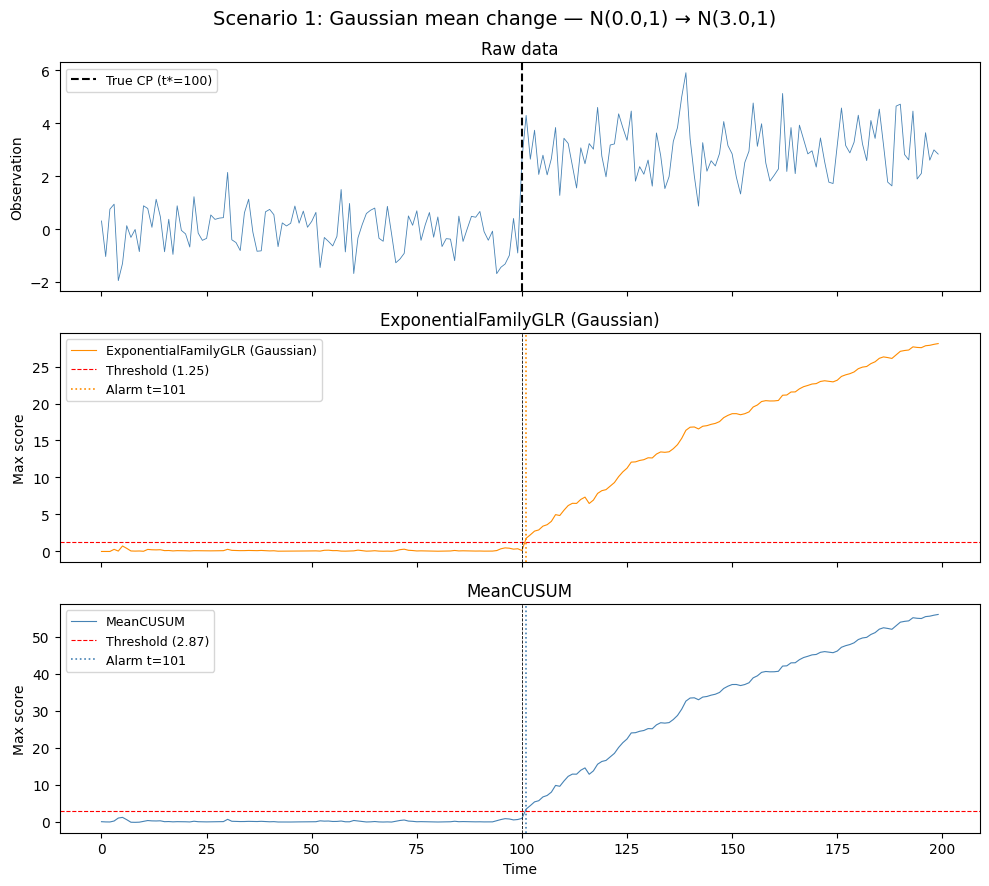

ExponentialFamilyGLR alarm:       101
MeanCUSUM alarm: 101

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


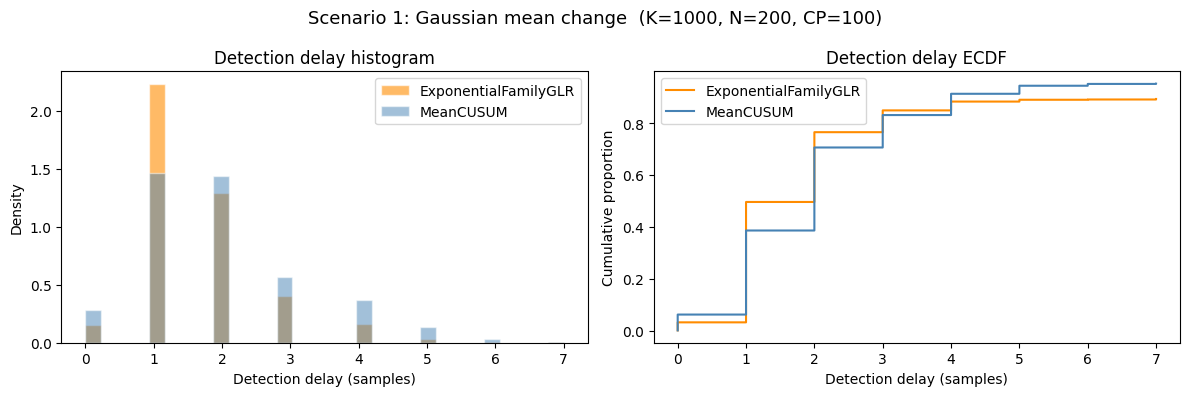

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR            MeanCUSUM
--------------------------------------------------------------------
Detection rate                           0.893                0.952
Miss rate                                0.107                0.048
Mean delay                                 1.6                  2.0
Median delay                               1.0                  2.0
False alarm (<CP)                        0.107                0.048
Null FAR                                 0.048                0.036
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       4.4 ms/stream
MeanCUSUM: 4.3 ms/stream
Ratio:     1.02x


In [6]:
# Scenario 1: Univariate Gaussian — change in mean (known variance)
# h(x) = x,  A(θ) = θ²/2,  A'(θ) = θ,  A''(θ) = 1
# Pre: N(0,1) → Post: N(3,1)  |  N=200, CP=100  |  Reference: MeanCUSUM
# =============================================================================

from gridcp.scores import MeanCUSUM

N1, CP1, MU_PRE1, MU_POST1 = 200, 100, 0.0, 3.0
# stream length, changepoint location, pre- and post-change means

# -- h / A functions (reuse from smoke test if already defined) --
@nb.njit
def h1(x):
    return x[0]

@nb.njit
def A1(theta):
    return theta * theta / 2.0

@nb.njit
def Ap1(theta):
    return theta

@nb.njit
def App1(theta):
    return 1.0

# -- Scores --
score1_ef  = ExponentialFamilyGLR(v=1, n_features=1, h=h1, A=A1,
                                     A_prime=Ap1, A_dprime=App1)
score1_ref = MeanCUSUM(n_features=1)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR ...")
thr1_ef = calibrate_threshold(
    score1_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N1,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold:      {thr1_ef:.4f}")

print("Calibrating MeanCUSUM ...")
thr1_ref = calibrate_threshold(
    score1_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N1,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr1_ref:.4f}")

# -- Detectors --
det1_ef  = GridDetector(score=score1_ef,  threshold=thr1_ef)
det1_ref = GridDetector(score=score1_ref, threshold=thr1_ref)

# -- Single-stream test --
rng1 = np.random.default_rng(SEED)
data1 = np.concatenate([
    rng1.normal(MU_PRE1,  1.0, (CP1,       1)),
    rng1.normal(MU_POST1, 1.0, (N1 - CP1, 1)),
])
outs1_ef,  stats1_ef  = run_and_collect(data1, det1_ef)
outs1_ref, stats1_ref = run_and_collect(data1, det1_ref)

plot_scenario(
    f"Scenario 1: Gaussian mean change — N({MU_PRE1},{1}) → N({MU_POST1},{1})",
    data1, stats1_ef, thr1_ef, first_alarm(outs1_ef), CP1,
    stats_ref=stats1_ref, threshold_ref=thr1_ref, alarm_ref=first_alarm(outs1_ref),
    ef_label="ExponentialFamilyGLR (Gaussian)", ref_label="MeanCUSUM",
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs1_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs1_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res1 = run_sim_study(
    det1_ef, det1_ref,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler=lambda rng=None: np.random.default_rng().normal(MU_POST1, 1.0),
    n_features=1, N=N1, K=K_SIM, true_cp=CP1, rng=SEED,
)
plot_sim_study(res1, "Scenario 1: Gaussian mean change",
               ef_label="ExponentialFamilyGLR", ref_label="MeanCUSUM")

# -- Timing --
print("\nTiming ...")
t1_ef  = time_detector(det1_ef,  np.random.default_rng(0).standard_normal,
                        n_features=1, N=N1)
t1_ref = time_detector(det1_ref, np.random.default_rng(0).standard_normal,
                        n_features=1, N=N1)
print(f"ExponentialFamilyGLR:       {t1_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t1_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t1_ef/t1_ref:.2f}x")

Scenario 1: sweeping Δμ ...


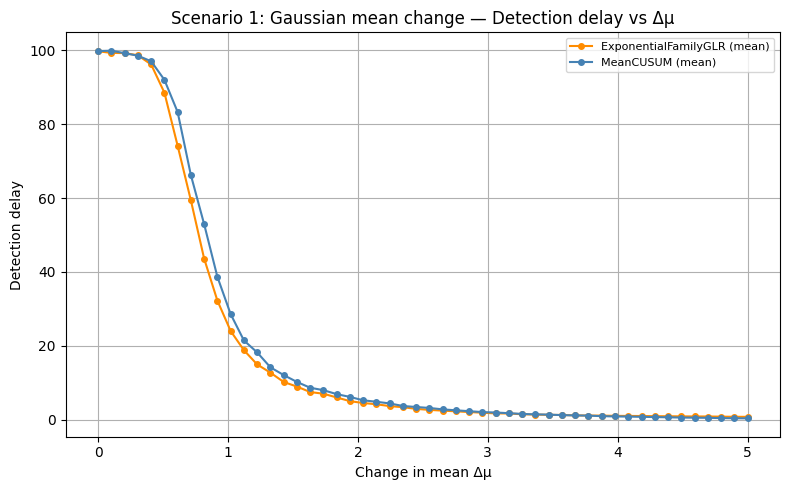

In [ ]:
# Scenario 1: Detection delay vs change size (Δμ = μ_post − μ_pre)
# Sweep Δμ from 0 to 5; compare ExponentialFamilyGLR vs MeanCUSUM
# Uses det1_ef, det1_ref, N1, CP1 from the cell above.
# =============================================================================

deltas_1 = np.linspace(0.0, 5.0, num=50)

def post_sampler_factory_1(delta):
    mu_post = MU_PRE1 + delta
    def sampler(rng=None, _d=mu_post):
        return np.random.default_rng().normal(_d, 1.0)
    return sampler

print("Scenario 1: sweeping Δμ ...")
sweep1 = sweep_detection_delay(
    [("ExponentialFamilyGLR", det1_ef), ("MeanCUSUM", det1_ref)],
    deltas_1,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler_factory=post_sampler_factory_1,
    N=N1, CP=CP1, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_1, sweep1,
    "Scenario 1: Gaussian mean change — Detection delay vs Δμ",
    xlabel="Change in mean Δμ",
    borders=False
)

Calibrating ExponentialFamilyGLR (Gaussian variance) ...
  EF threshold: 1.5117


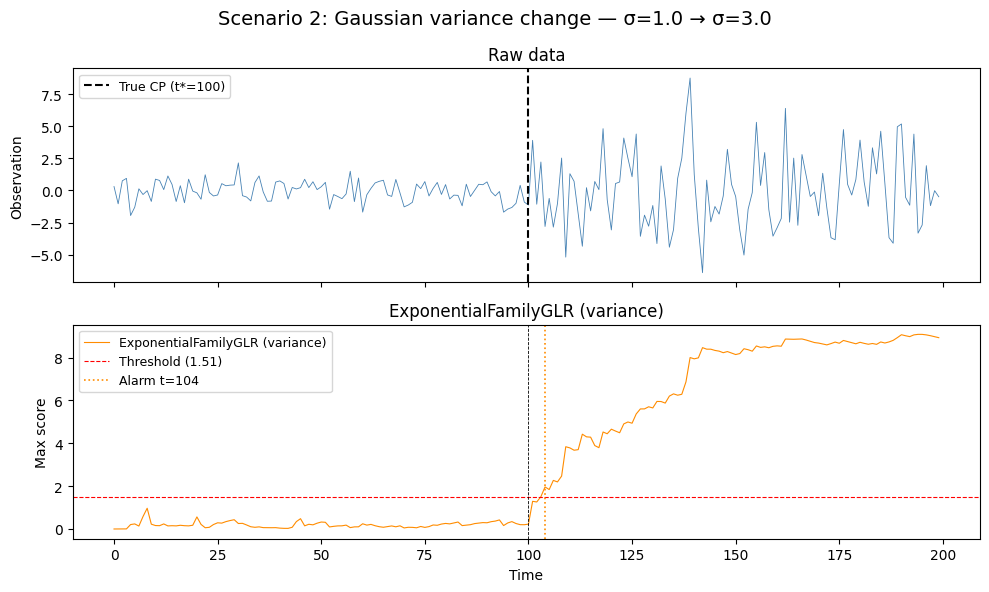

ExponentialFamilyGLR alarm: 104

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


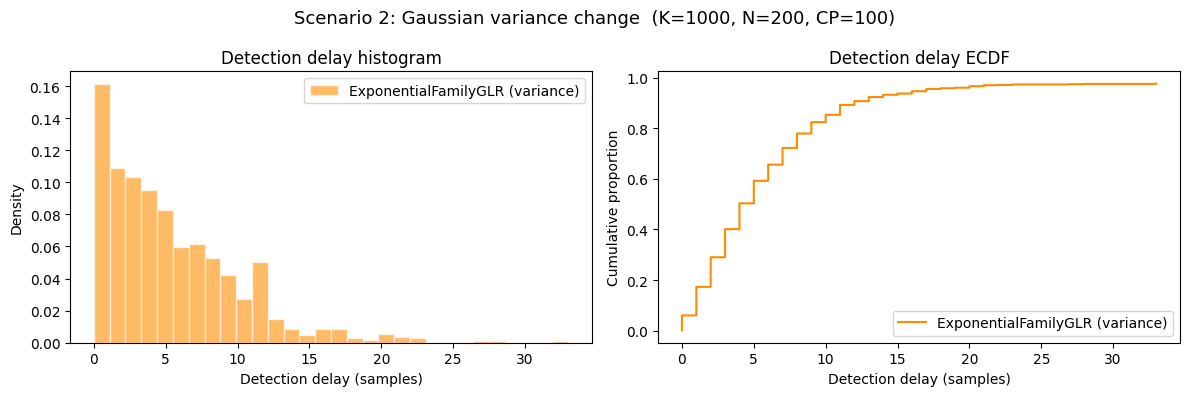

-----------------------------------------------
Metric                    ExponentialFamilyGLR (variance)
-----------------------------------------------
Detection rate                           0.976
Miss rate                                0.024
Mean delay                                 5.4
Median delay                               4.0
False alarm (<CP)                        0.024
Null FAR                                 0.048
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.5 ms/stream


In [6]:
# Scenario 2: Univariate Gaussian — change in variance (known mean = 0)
# h(x) = x²,  A(θ) = -½ log(-2θ),  θ < 0
# Pre: N(0,1) → Post: N(0,3)  |  N=200, CP=100  |  No built-in reference
# =============================================================================

N2, CP2, SIGMA_PRE2, SIGMA_POST2 = 200, 100, 1.0, 3.0

@nb.njit
def h2(x):
    return x[0] * x[0]

@nb.njit
def A2(theta):
    return -0.5 * np.log(-2.0 * theta)

@nb.njit
def Ap2(theta):
    return -1.0 / (2.0 * theta)

@nb.njit
def App2(theta):
    return 1.0 / (2.0 * theta * theta)

score2_ef = ExponentialFamilyGLR(
    v=1, n_features=1, h=h2, A=A2,
    A_prime=Ap2, A_dprime=App2,
    theta_init=-0.5,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Gaussian variance) ...")
thr2_ef = calibrate_threshold(
    score2_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N2,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr2_ef:.4f}")

det2_ef = GridDetector(score=score2_ef, threshold=thr2_ef)

# -- Single-stream test --
rng2 = np.random.default_rng(SEED)
data2 = np.concatenate([
    rng2.normal(0.0, SIGMA_PRE2,  (CP2,       1)),
    rng2.normal(0.0, SIGMA_POST2, (N2 - CP2, 1)),
])
outs2_ef, stats2_ef = run_and_collect(data2, det2_ef)

plot_scenario(
    f"Scenario 2: Gaussian variance change — σ={SIGMA_PRE2} → σ={SIGMA_POST2}",
    data2, stats2_ef, thr2_ef, first_alarm(outs2_ef), CP2,
    ef_label="ExponentialFamilyGLR (variance)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs2_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res2 = run_sim_study(
    det2_ef, None,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler=lambda rng=None: np.random.default_rng().normal(0.0, SIGMA_POST2),
    n_features=1, N=N2, K=K_SIM, true_cp=CP2, rng=SEED,
)
plot_sim_study(res2, "Scenario 2: Gaussian variance change",
               ef_label="ExponentialFamilyGLR (variance)")

# -- Timing --
print("\nTiming ...")
t2_ef = time_detector(det2_ef, np.random.default_rng(0).standard_normal,
                       n_features=1, N=N2)
print(f"ExponentialFamilyGLR: {t2_ef*1000:.1f} ms/stream")

Scenario 2: sweeping Δσ ...


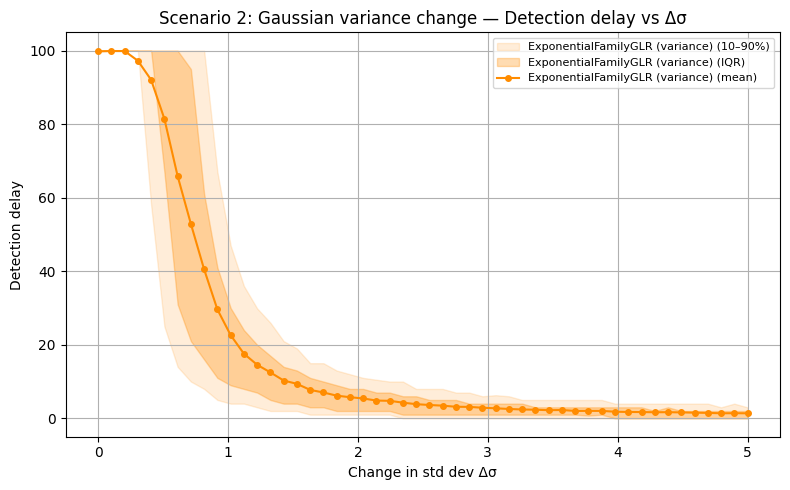

In [24]:
# Scenario 2: Detection delay vs change size (Δσ = σ_post − σ_pre)
# Sweep Δσ from 0 (no change) to 5; EF GLR only
# Uses det2_ef, N2, CP2 from the cell above.
# =============================================================================

delta_sigmas_2 = np.linspace(0.0, 5.0, num=50)

def post_sampler_factory_2(delta_sigma):
    sigma_post = SIGMA_PRE2 + delta_sigma
    def sampler(rng=None, _s=sigma_post):
        return np.random.default_rng().normal(0.0, _s)
    return sampler

print("Scenario 2: sweeping Δσ ...")
sweep2 = sweep_detection_delay(
    [("ExponentialFamilyGLR (variance)", det2_ef)],
    delta_sigmas_2,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler_factory=post_sampler_factory_2,
    N=N2, CP=CP2, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    delta_sigmas_2, sweep2,
    "Scenario 2: Gaussian variance change — Detection delay vs Δσ",
    xlabel="Change in std dev Δσ",
)

Calibrating ExponentialFamilyGLR (Poisson) ...


  EF threshold: 1.5422


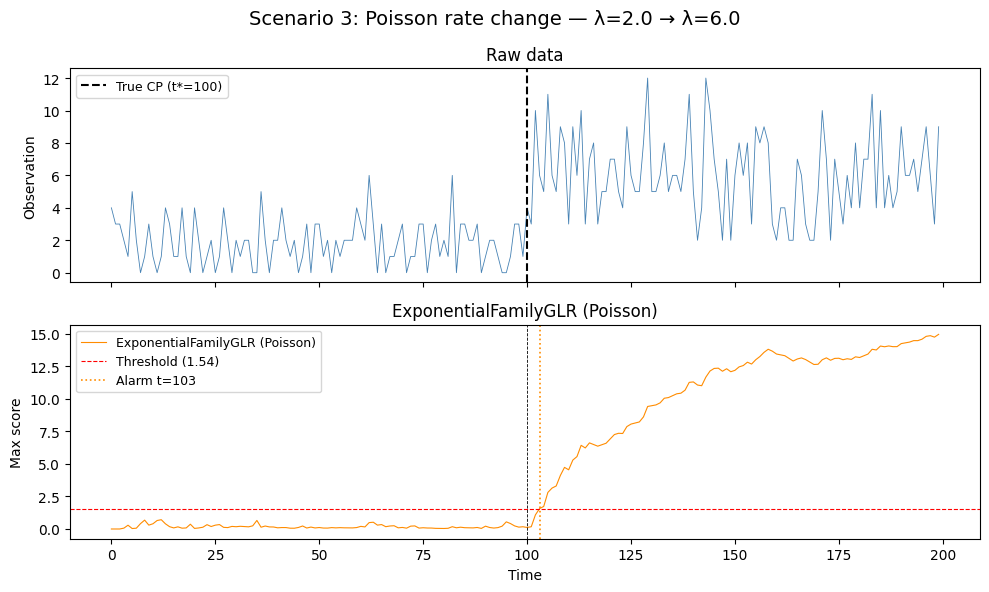

ExponentialFamilyGLR alarm: 103

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


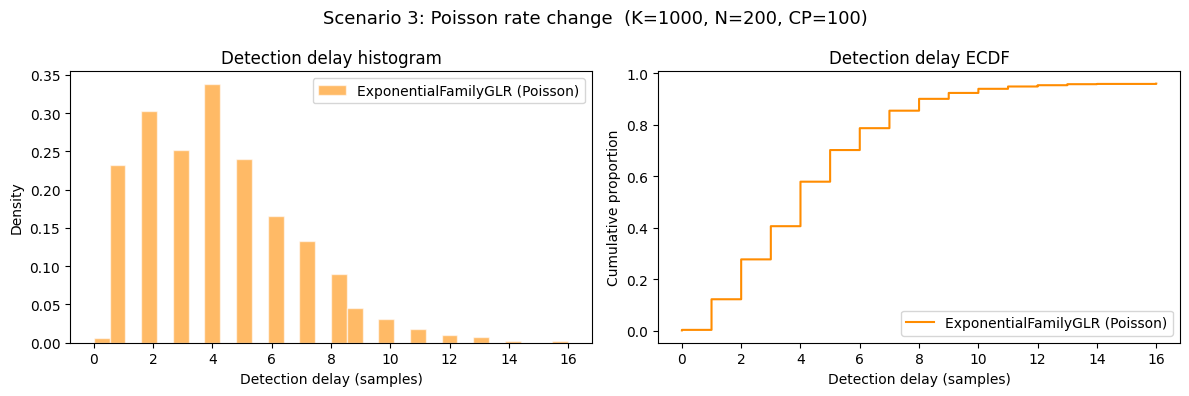

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Poisson)
-----------------------------------------------
Detection rate                           0.960
Miss rate                                0.040
Mean delay                                 4.3
Median delay                               4.0
False alarm (<CP)                        0.040
Null FAR                                 0.051
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.5 ms/stream


In [8]:
# Scenario 3: Poisson — change in rate
# h(x) = x,  A(θ) = exp(θ),  A'(θ) = exp(θ),  A''(θ) = exp(θ)
# Pre: Poisson(2) → Post: Poisson(6)  |  N=1000, CP=500
# =============================================================================

N3, CP3, LAM_PRE3, LAM_POST3 = 200, 100, 2.0, 6.0

@nb.njit
def h3(x):
    return x[0]

@nb.njit
def A3(theta):
    return np.exp(theta)

@nb.njit
def Ap3(theta):
    return np.exp(theta)

@nb.njit
def App3(theta):
    return np.exp(theta)

score3_ef = ExponentialFamilyGLR(v=1, n_features=1, h=h3, A=A3,
                                    A_prime=Ap3, A_dprime=App3)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Poisson) ...")

def _poisson_pre3(rng=None):
    return float(np.random.default_rng().poisson(LAM_PRE3))

def _poisson_post3(rng=None):
    return float(np.random.default_rng().poisson(LAM_POST3))

thr3_ef = calibrate_threshold(
    score3_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N3,
    pre_sampler=_poisson_pre3,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr3_ef:.4f}")

det3_ef = GridDetector(score=score3_ef, threshold=thr3_ef)

# -- Single-stream test --
rng3 = np.random.default_rng(SEED)
data3 = np.concatenate([
    rng3.poisson(LAM_PRE3,  (CP3,)).reshape(-1, 1),
    rng3.poisson(LAM_POST3, (N3 - CP3,)).reshape(-1, 1),
]).astype(np.float64)
outs3_ef, stats3_ef = run_and_collect(data3, det3_ef)

plot_scenario(
    f"Scenario 3: Poisson rate change — λ={LAM_PRE3} → λ={LAM_POST3}",
    data3, stats3_ef, thr3_ef, first_alarm(outs3_ef), CP3,
    ef_label="ExponentialFamilyGLR (Poisson)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs3_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res3 = run_sim_study(
    det3_ef, None,
    pre_sampler=_poisson_pre3, post_sampler=_poisson_post3,
    n_features=1, N=N3, K=K_SIM, true_cp=CP3, rng=SEED,
)
plot_sim_study(res3, "Scenario 3: Poisson rate change",
               ef_label="ExponentialFamilyGLR (Poisson)")

# -- Timing --
print("\nTiming ...")
t3_ef = time_detector(det3_ef, _poisson_pre3, n_features=1, N=N3)
print(f"ExponentialFamilyGLR: {t3_ef*1000:.1f} ms/stream")

Scenario 3: sweeping Δλ ...


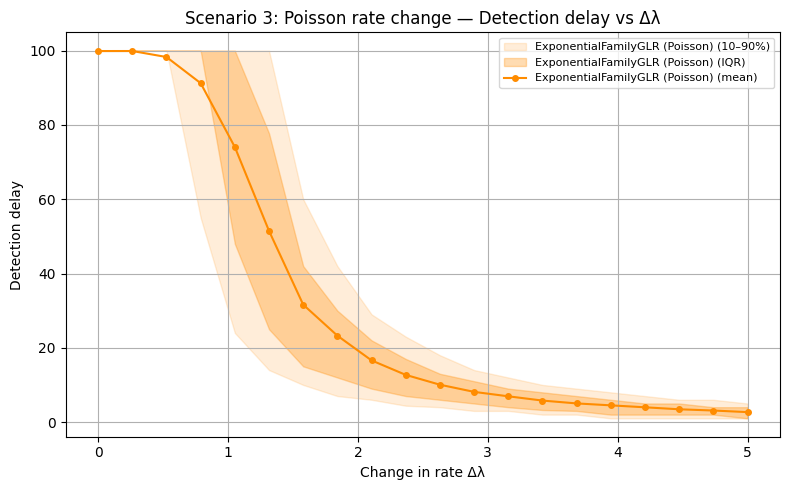

In [25]:
# Scenario 3: Detection delay vs change size (Δλ = λ_post − λ_pre)
# Sweep Δλ from 0 to 5; EF GLR only (no built-in reference for Poisson)
# Uses det3_ef, N3, CP3, LAM_PRE3 from the cell above.
# =============================================================================

deltas_3 = np.linspace(0.0, 5.0, num=20)

def post_sampler_factory_3(delta_lam):
    lam_post = LAM_PRE3 + delta_lam
    def sampler(rng=None, _l=lam_post):
        return float(np.random.default_rng().poisson(_l))
    return sampler

print("Scenario 3: sweeping Δλ ...")
sweep3 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Poisson)", det3_ef)],
    deltas_3,
    pre_sampler=_poisson_pre3,
    post_sampler_factory=post_sampler_factory_3,
    N=N3, CP=CP3, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_3, sweep3,
    "Scenario 3: Poisson rate change — Detection delay vs Δλ",
    xlabel="Change in rate Δλ",
)

Calibrating ExponentialFamilyGLR (Exponential) ...
  EF threshold: 1.4669


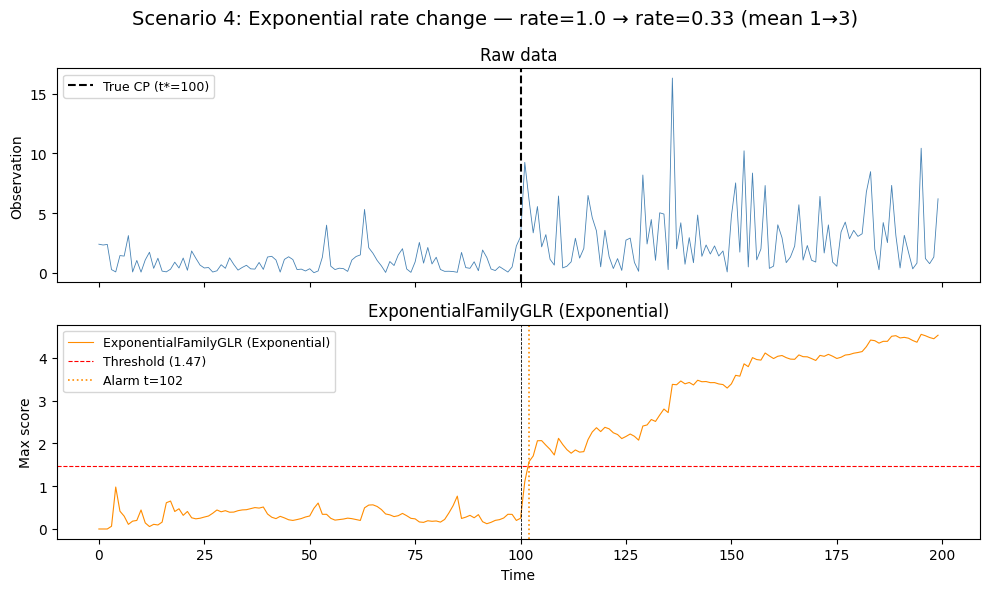

ExponentialFamilyGLR alarm: 102

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


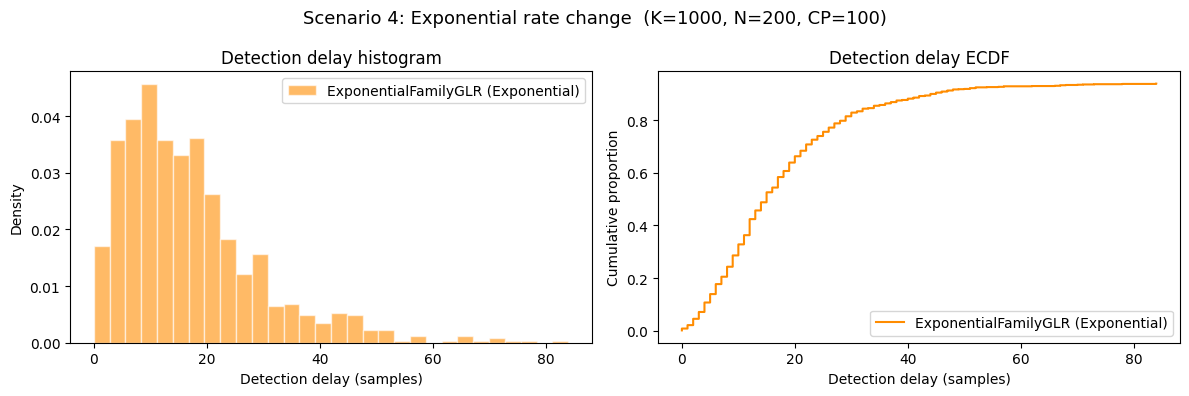

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Exponential)
-----------------------------------------------
Detection rate                           0.939
Miss rate                                0.061
Mean delay                                16.9
Median delay                              14.0
False alarm (<CP)                        0.061
Null FAR                                 0.053
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.4 ms/stream


In [10]:
# Scenario 4: Exponential — change in rate
# h(x) = x,  A(θ) = -log(-θ),  A'(θ) = -1/θ,  A''(θ) = 1/θ²
# θ = -rate  (θ < 0)
# Pre: Exp(rate=1) → Post: Exp(rate=1/3)  (mean 1 → 3)  |  N=1000, CP=500
# =============================================================================

N4, CP4, RATE_PRE4, RATE_POST4 = 200, 100, 1.0, 1.0 / 3.0

@nb.njit
def h4(x):
    return x[0]

@nb.njit
def A4(theta):
    return -np.log(-theta)

@nb.njit
def Ap4(theta):
    return -1.0 / theta

@nb.njit
def App4(theta):
    return 1.0 / (theta * theta)

score4_ef = ExponentialFamilyGLR(
    v=1, n_features=1, h=h4, A=A4,
    A_prime=Ap4, A_dprime=App4,
    theta_init=-1.0,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Exponential) ...")

def _exp_pre4(rng=None):
    return float(np.random.default_rng().exponential(1.0 / RATE_PRE4))

def _exp_post4(rng=None):
    return float(np.random.default_rng().exponential(1.0 / RATE_POST4))

thr4_ef = calibrate_threshold(
    score4_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N4,
    pre_sampler=_exp_pre4,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr4_ef:.4f}")

det4_ef = GridDetector(score=score4_ef, threshold=thr4_ef)

# -- Single-stream test --
rng4 = np.random.default_rng(SEED)
data4 = np.concatenate([
    rng4.exponential(1.0 / RATE_PRE4,  (CP4,       1)),
    rng4.exponential(1.0 / RATE_POST4, (N4 - CP4, 1)),
])
outs4_ef, stats4_ef = run_and_collect(data4, det4_ef)

plot_scenario(
    f"Scenario 4: Exponential rate change — rate={RATE_PRE4} → rate={RATE_POST4:.2f} (mean 1→3)",
    data4, stats4_ef, thr4_ef, first_alarm(outs4_ef), CP4,
    ef_label="ExponentialFamilyGLR (Exponential)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs4_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res4 = run_sim_study(
    det4_ef, None,
    pre_sampler=_exp_pre4, post_sampler=_exp_post4,
    n_features=1, N=N4, K=K_SIM, true_cp=CP4, rng=SEED,
)
plot_sim_study(res4, "Scenario 4: Exponential rate change",
               ef_label="ExponentialFamilyGLR (Exponential)")

# -- Timing --
print("\nTiming ...")
t4_ef = time_detector(det4_ef, _exp_pre4, n_features=1, N=N4)
print(f"ExponentialFamilyGLR: {t4_ef*1000:.1f} ms/stream")

Scenario 4: sweeping Δmean ...


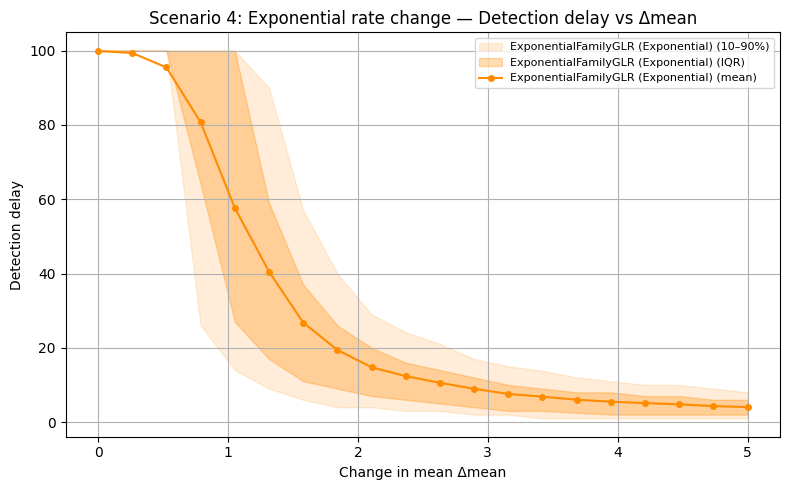

In [26]:
# Scenario 4: Detection delay vs change size (Δmean = mean_post − mean_pre)
# Sweep Δmean from 0 to 5; EF GLR only (no built-in reference for Exponential)
# Uses det4_ef, N4, CP4, RATE_PRE4 from the cell above.
# mean_pre = 1/RATE_PRE4 = 1.0
# =============================================================================

delta_means_4 = np.linspace(0.0, 5.0, num=20)
MEAN_PRE4 = 1.0 / RATE_PRE4

def post_sampler_factory_4(delta_mean):
    mean_post = MEAN_PRE4 + delta_mean
    def sampler(rng=None, _m=mean_post):
        return float(np.random.default_rng().exponential(_m))
    return sampler

print("Scenario 4: sweeping Δmean ...")
sweep4 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Exponential)", det4_ef)],
    delta_means_4,
    pre_sampler=_exp_pre4,
    post_sampler_factory=post_sampler_factory_4,
    N=N4, CP=CP4, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    delta_means_4, sweep4,
    "Scenario 4: Exponential rate change — Detection delay vs Δmean",
    xlabel="Change in mean Δmean",
)

Calibrating ExponentialFamilyGLR (Bernoulli) ...
  EF threshold: 1.4233


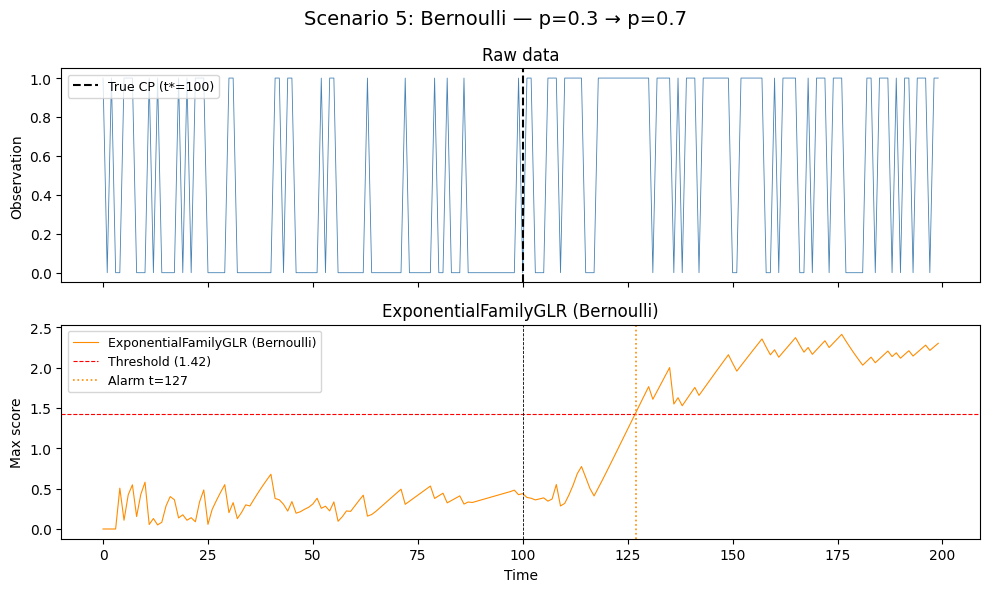

ExponentialFamilyGLR alarm: 127

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


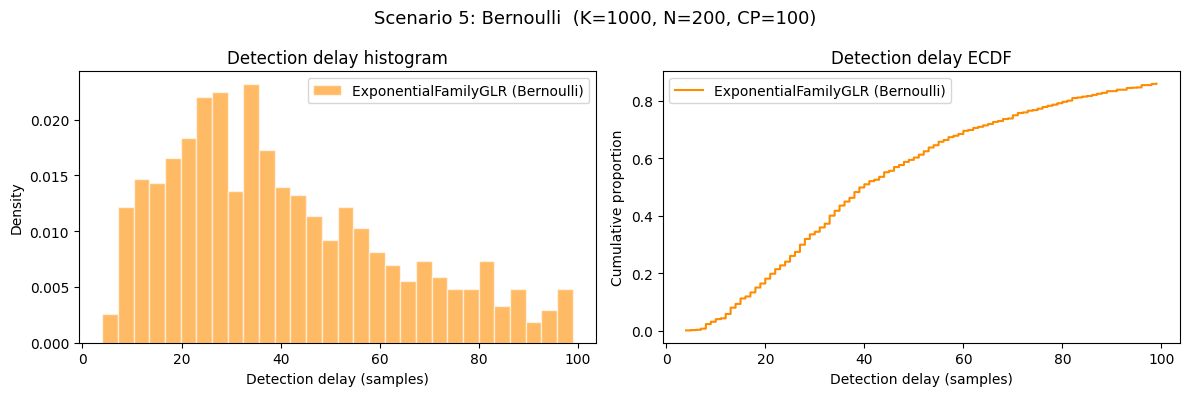

-----------------------------------------------
Metric                    ExponentialFamilyGLR (Bernoulli)
-----------------------------------------------
Detection rate                           0.859
Miss rate                                0.141
Mean delay                                40.3
Median delay                              35.0
False alarm (<CP)                        0.048
Null FAR                                 0.053
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 2.8 ms/stream


In [12]:
# Scenario 5: Bernoulli — change in success probability
# h(x) = x,  A(θ) = log(1 + exp(θ)),  A' = σ(θ),  A'' = σ(θ)(1-σ(θ))
# Pre: Bernoulli(0.3) → Post: Bernoulli(0.7)  |  N=1000, CP=500
# =============================================================================

N5, CP5, P_PRE5, P_POST5 = 200, 100, 0.3, 0.7

@nb.njit
def h5(x):
    return x[0]

@nb.njit
def A5(theta):
    # log(1 + exp(theta)), numerically stable
    if theta > 30.0:
        return theta
    return np.log1p(np.exp(theta))

@nb.njit
def Ap5(theta):
    # sigmoid
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    return 1.0 / (1.0 + np.exp(-theta))

@nb.njit
def App5(theta):
    s = Ap5(theta)
    return s * (1.0 - s)

score5_ef = ExponentialFamilyGLR(v=1, n_features=1, h=h5, A=A5,
                                    A_prime=Ap5, A_dprime=App5)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Bernoulli) ...")

def _bern_pre5(rng=None):
    return float(np.random.default_rng().binomial(1, P_PRE5))

def _bern_post5(rng=None):
    return float(np.random.default_rng().binomial(1, P_POST5))

thr5_ef = calibrate_threshold(
    score5_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N5,
    pre_sampler=_bern_pre5,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr5_ef:.4f}")

det5_ef = GridDetector(score=score5_ef, threshold=thr5_ef)

# -- Single-stream test --
rng5 = np.random.default_rng(SEED)
data5 = np.concatenate([
    rng5.binomial(1, P_PRE5,  (CP5,)).reshape(-1, 1),
    rng5.binomial(1, P_POST5, (N5 - CP5,)).reshape(-1, 1),
]).astype(np.float64)
outs5_ef, stats5_ef = run_and_collect(data5, det5_ef)

plot_scenario(
    f"Scenario 5: Bernoulli — p={P_PRE5} → p={P_POST5}",
    data5, stats5_ef, thr5_ef, first_alarm(outs5_ef), CP5,
    ef_label="ExponentialFamilyGLR (Bernoulli)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs5_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res5 = run_sim_study(
    det5_ef, None,
    pre_sampler=_bern_pre5, post_sampler=_bern_post5,
    n_features=1, N=N5, K=K_SIM, true_cp=CP5, rng=SEED,
)
plot_sim_study(res5, "Scenario 5: Bernoulli",
               ef_label="ExponentialFamilyGLR (Bernoulli)")

# -- Timing --
print("\nTiming ...")
t5_ef = time_detector(det5_ef, _bern_pre5, n_features=1, N=N5)
print(f"ExponentialFamilyGLR: {t5_ef*1000:.1f} ms/stream")

Scenario 5: sweeping Δp ...


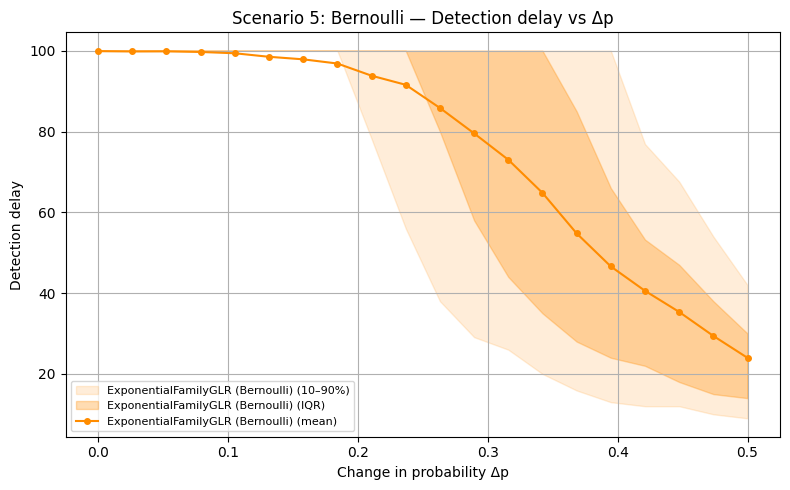

In [27]:
# Scenario 5: Detection delay vs change size (Δp = p_post − p_pre)
# Sweep Δp from 0 to 0.5 (p_post = 0.3 + Δp, capped below 1); EF GLR only
# Uses det5_ef, N5, CP5, P_PRE5 from the cell above.
# =============================================================================

deltas_5 = np.linspace(0.0, 0.5, num=20)

def post_sampler_factory_5(delta_p):
    p_post = P_PRE5 + delta_p
    def sampler(rng=None, _p=p_post):
        return float(np.random.default_rng().binomial(1, _p))
    return sampler

print("Scenario 5: sweeping Δp ...")
sweep5 = sweep_detection_delay(
    [("ExponentialFamilyGLR (Bernoulli)", det5_ef)],
    deltas_5,
    pre_sampler=_bern_pre5,
    post_sampler_factory=post_sampler_factory_5,
    N=N5, CP=CP5, K=K_SIM, rng=SEED,
)

plot_detection_delay(
    deltas_5, sweep5,
    "Scenario 5: Bernoulli — Detection delay vs Δp",
    xlabel="Change in probability Δp",
)

Calibrating ExponentialFamilyGLR (Gaussian mean+variance) ...


  EF threshold: 1.2480


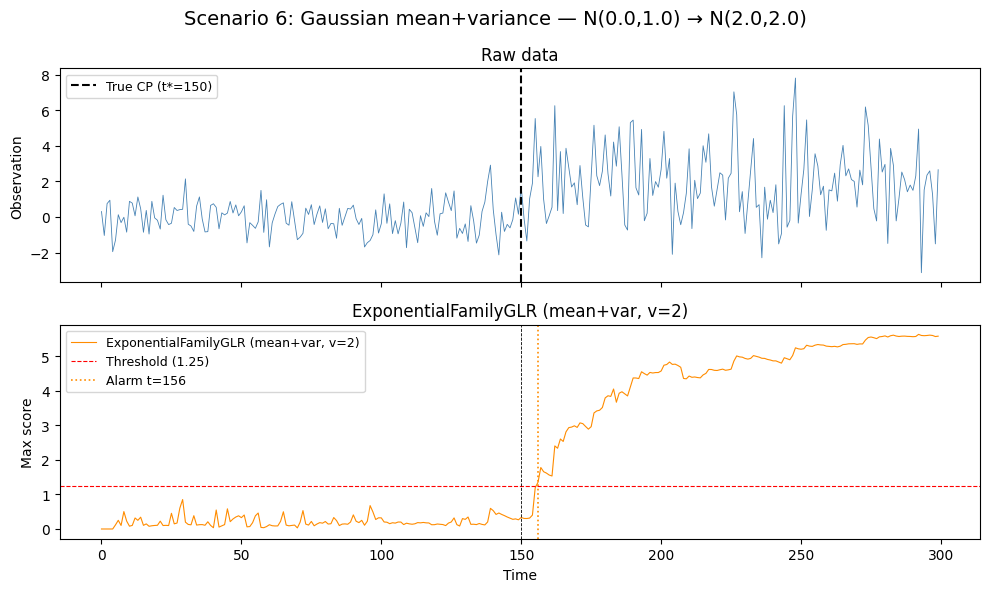

ExponentialFamilyGLR alarm: 156

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


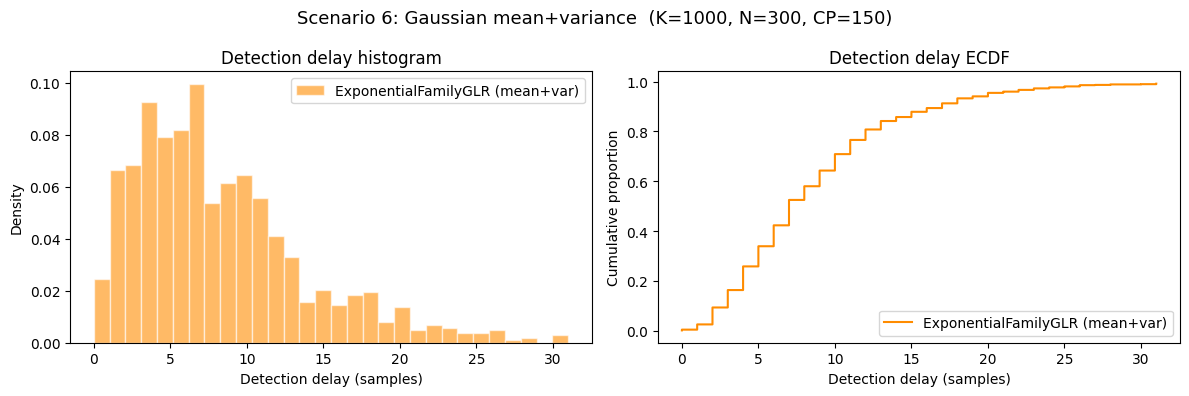

-----------------------------------------------
Metric                    ExponentialFamilyGLR (mean+var)
-----------------------------------------------
Detection rate                           0.992
Miss rate                                0.008
Mean delay                                 8.5
Median delay                               7.0
False alarm (<CP)                        0.008
Null FAR                                 0.016
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 19.4 ms/stream


In [8]:
# Scenario 6: Univariate Gaussian — joint change in mean AND variance (v=2)
# h(x) = (x, x²),  θ = (θ₀, θ₁) with θ₁ < 0
# A(θ) = -θ₀²/(4θ₁) - ½ log(-2θ₁)
# Pre: N(0,1) → Post: N(2,2)  |  N=300, CP=150
# =============================================================================

N6, CP6 = 300, 150
MU_PRE6, MU_POST6 = 0.0, 2.0
SIGMA_PRE6, SIGMA_POST6 = 1.0, 2.0

@nb.njit
def h6(x):
    out = np.empty(2)
    out[0] = x[0]
    out[1] = x[0] * x[0]
    return out

@nb.njit
def A6(theta):
    # theta = (theta0, theta1), theta1 < 0
    return -theta[0] * theta[0] / (4.0 * theta[1]) - 0.5 * np.log(-2.0 * theta[1])

@nb.njit
def Agrad6(theta):
    g = np.empty(2)
    g[0] = -theta[0] / (2.0 * theta[1])
    g[1] = theta[0] * theta[0] / (4.0 * theta[1] * theta[1]) - 1.0 / (2.0 * theta[1])
    return g

@nb.njit
def Ahess6(theta):
    H = np.zeros((2, 2))
    H[0, 0] = -1.0 / (2.0 * theta[1])
    H[0, 1] = theta[0] / (2.0 * theta[1] * theta[1])
    H[1, 0] = H[0, 1]
    H[1, 1] = (-theta[0] * theta[0] / (2.0 * theta[1]**3)
                + 1.0 / (2.0 * theta[1] * theta[1]))
    return H

# theta_init: for N(0,1) the canonical params are θ₀ = μ/σ² = 0, θ₁ = -1/(2σ²) = -0.5
score6_ef = ExponentialFamilyGLR(
    v=2, n_features=1, h=h6, A=A6,
    A_grad=Agrad6, A_hess=Ahess6,
    theta_init=np.array([0.0, -0.5]),
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Gaussian mean+variance) ...")
thr6_ef = calibrate_threshold(
    score6_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N6,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr6_ef:.4f}")

det6_ef = GridDetector(score=score6_ef, threshold=thr6_ef)

# -- Single-stream test --
rng6 = np.random.default_rng(SEED)
data6 = np.concatenate([
    rng6.normal(MU_PRE6,  SIGMA_PRE6,  (CP6,       1)),
    rng6.normal(MU_POST6, SIGMA_POST6, (N6 - CP6, 1)),
])
outs6_ef, stats6_ef = run_and_collect(data6, det6_ef)

plot_scenario(
    f"Scenario 6: Gaussian mean+variance — N({MU_PRE6},{SIGMA_PRE6}) → "
    f"N({MU_POST6},{SIGMA_POST6})",
    data6, stats6_ef, thr6_ef, first_alarm(outs6_ef), CP6,
    ef_label="ExponentialFamilyGLR (mean+var, v=2)",
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs6_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")

def _gauss_post6(rng=None):
    return float(np.random.default_rng().normal(MU_POST6, SIGMA_POST6))

res6 = run_sim_study(
    det6_ef, None,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler=_gauss_post6,
    n_features=1, N=N6, K=K_SIM, true_cp=CP6, rng=SEED,
)
plot_sim_study(res6, "Scenario 6: Gaussian mean+variance",
               ef_label="ExponentialFamilyGLR (mean+var)")

# -- Timing --
print("\nTiming ...")
t6_ef = time_detector(det6_ef, np.random.default_rng(0).standard_normal,
                       n_features=1, N=N6)
print(f"ExponentialFamilyGLR: {t6_ef*1000:.1f} ms/stream")

Calibrating ExponentialFamilyGLR (MV Gaussian mean) ...
  EF threshold: 0.5858
Calibrating MeanCUSUM(p=3) ...
  MeanCUSUM threshold: 3.7151


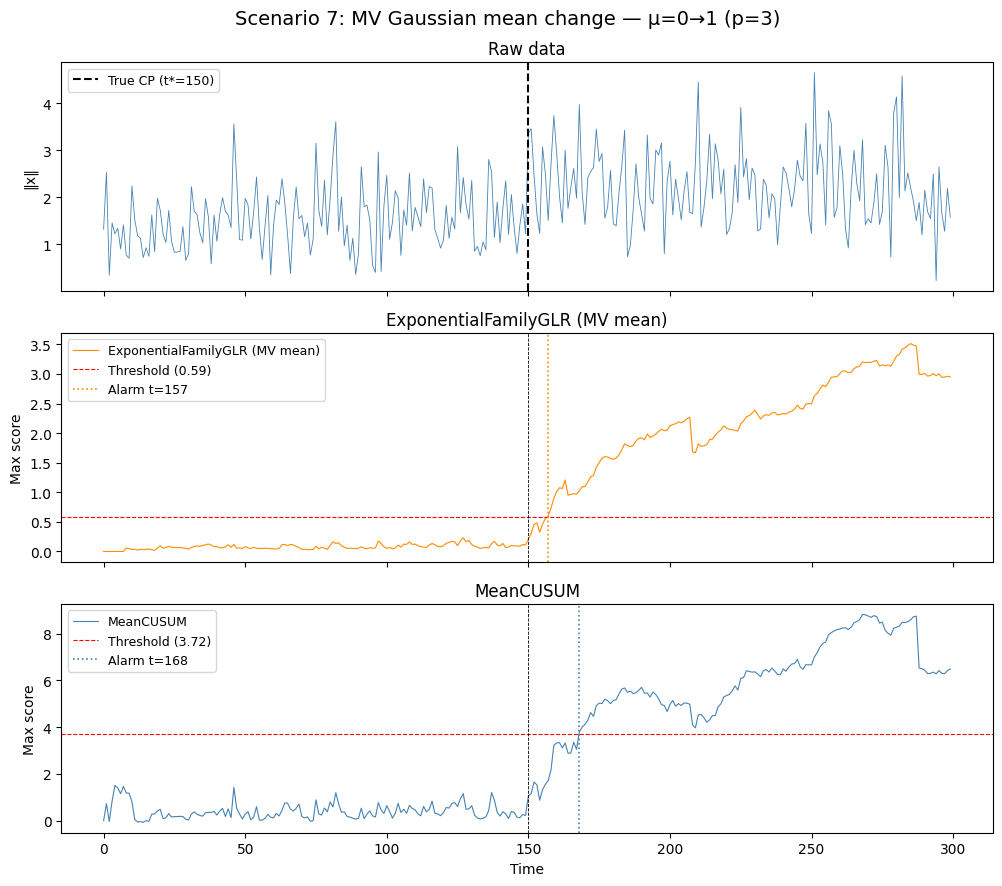

ExponentialFamilyGLR alarm:       157
MeanCUSUM alarm: 168

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


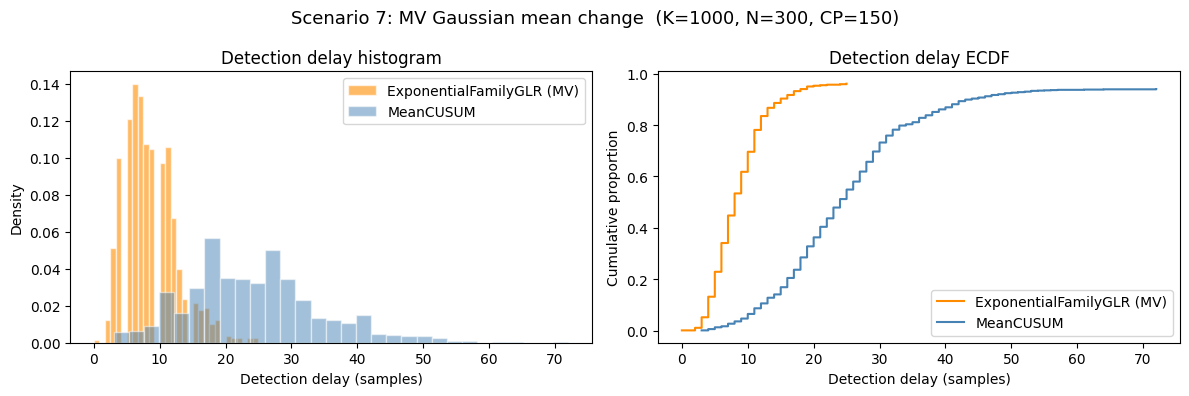

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR (MV)            MeanCUSUM
--------------------------------------------------------------------
Detection rate                           0.961                0.940
Miss rate                                0.039                0.060
Mean delay                                 8.5                 24.3
Median delay                               8.0                 23.0
False alarm (<CP)                        0.039                0.060
Null FAR                                 0.054                0.074
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       12.4 ms/stream
MeanCUSUM: 3.6 ms/stream
Ratio:     3.45x


In [9]:
# Scenario 7: Multivariate Gaussian — change in mean (known cov = I, p=3)
# h(x) = x,  A(θ) = ½‖θ‖²,  ∇A = θ,  ∇²A = I
# Pre: N(0,I) → Post: N(1,I)  |  N=300, CP=150  |  Reference: MeanCUSUM(3)
# =============================================================================

P7 = 3
N7, CP7 = 300, 150

@nb.njit
def h7(x):
    return x.copy()

@nb.njit
def A7(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def Agrad7(theta):
    return theta.copy()

@nb.njit
def Ahess7(theta):
    return np.eye(theta.shape[0])

score7_ef  = ExponentialFamilyGLR(v=P7, n_features=P7, h=h7, A=A7,
                                     A_grad=Agrad7, A_hess=Ahess7)
score7_ref = MeanCUSUM(n_features=P7)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian mean) ...")

def _mv_pre7(rng=None):
    return np.random.default_rng().standard_normal(P7)

def _mv_post7(rng=None):
    return np.random.default_rng().standard_normal(P7) + 1.0

thr7_ef = calibrate_threshold(
    score7_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N7,
    pre_sampler=_mv_pre7,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr7_ef:.4f}")

print("Calibrating MeanCUSUM(p=3) ...")
thr7_ref = calibrate_threshold(
    score7_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N7,
    pre_sampler=_mv_pre7,
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr7_ref:.4f}")

det7_ef  = GridDetector(score=score7_ef,  threshold=thr7_ef)
det7_ref = GridDetector(score=score7_ref, threshold=thr7_ref)

# -- Single-stream test --
rng7 = np.random.default_rng(SEED)
data7 = np.concatenate([
    rng7.multivariate_normal(np.zeros(P7), np.eye(P7), CP7),
    rng7.multivariate_normal(np.ones(P7),  np.eye(P7), N7 - CP7),
])
outs7_ef,  stats7_ef  = run_and_collect(data7, det7_ef)
outs7_ref, stats7_ref = run_and_collect(data7, det7_ref)

plot_scenario(
    f"Scenario 7: MV Gaussian mean change — μ=0→1 (p={P7})",
    data7, stats7_ef, thr7_ef, first_alarm(outs7_ef), CP7,
    stats_ref=stats7_ref, threshold_ref=thr7_ref, alarm_ref=first_alarm(outs7_ref),
    ef_label="ExponentialFamilyGLR (MV mean)", ref_label="MeanCUSUM",
    data_ylabel="‖x‖",
    data_transform=lambda d: np.linalg.norm(d, axis=1),
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs7_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs7_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res7 = run_sim_study(
    det7_ef, det7_ref,
    pre_sampler=_mv_pre7, post_sampler=_mv_post7,
    n_features=P7, N=N7, K=K_SIM, true_cp=CP7, rng=SEED,
)
plot_sim_study(res7, "Scenario 7: MV Gaussian mean change",
               ef_label="ExponentialFamilyGLR (MV)", ref_label="MeanCUSUM")

# -- Timing --
print("\nTiming ...")
t7_ef  = time_detector(det7_ef,  _mv_pre7, n_features=P7, N=N7)
t7_ref = time_detector(det7_ref, _mv_pre7, n_features=P7, N=N7)
print(f"ExponentialFamilyGLR:       {t7_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t7_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t7_ef/t7_ref:.2f}x")

Calibrating ExponentialFamilyGLR (MV Gaussian covariance) ...
  EF threshold: 0.4284


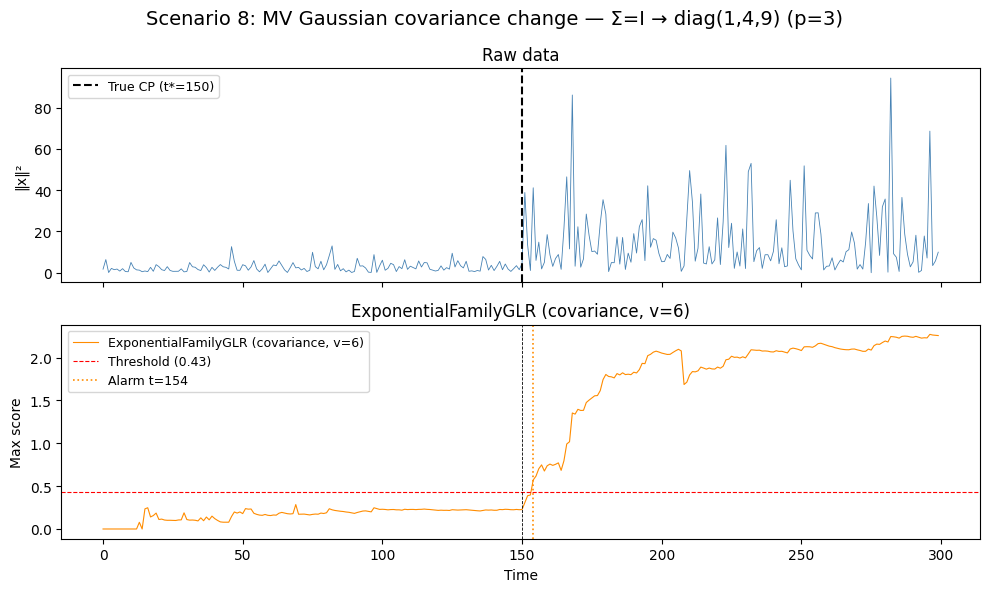

ExponentialFamilyGLR alarm: 154

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


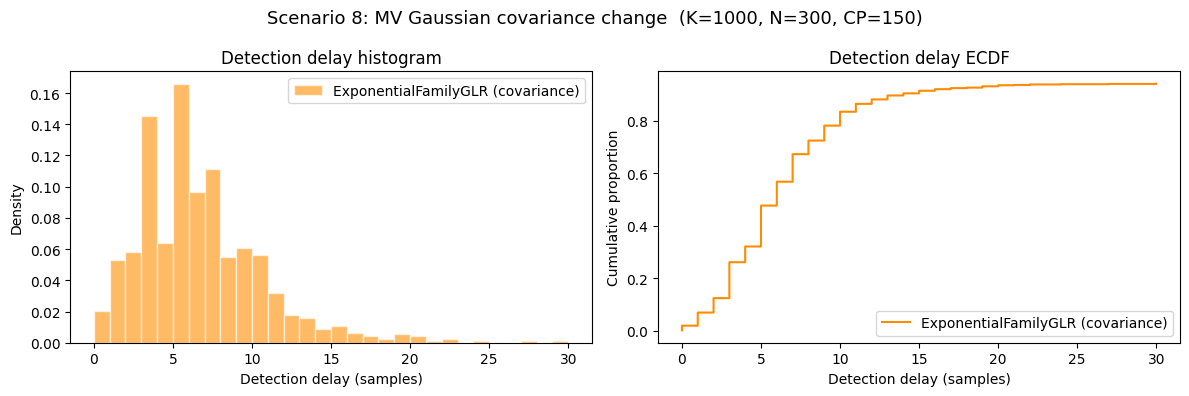

-----------------------------------------------
Metric                    ExponentialFamilyGLR (covariance)
-----------------------------------------------
Detection rate                           0.942
Miss rate                                0.058
Mean delay                                 6.2
Median delay                               5.0
False alarm (<CP)                        0.058
Null FAR                                 0.074
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 28.1 ms/stream


In [5]:
# Scenario 8: Multivariate Gaussian — change in covariance (known mean = 0, p=3)
# h(x) = vech(x xᵀ),  A(θ) = -½ log det(-2Θ)
# v = p(p+1)/2 = 6,  uses is_cov_case=True path in ExponentialFamilyGLR
# Pre: N(0,I) → Post: N(0, diag(1,4,9))  |  N=300, CP=150
# =============================================================================

P8 = 3
V8 = P8 * (P8 + 1) // 2   # = 6
N8, CP8 = 300, 150
SIGMA_PRE8  = np.eye(P8)
SIGMA_POST8 = np.diag([1.0, 4.0, 9.0])

# -- h: vech(x xᵀ), off-diag doubled so that θᵀh(x) = tr(Θ xxᵀ) --
@nb.njit
def h8(x):
    p = x.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                out[idx] = x[i] * x[j]
            else:
                out[idx] = 2.0 * x[i] * x[j]
            idx += 1
    return out

# -- A(θ) = -½ log det(-2Θ) --
@nb.njit
def A8(theta):
    p = _p_from_v(theta.shape[0])
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld

# -- ∇A: ∂A/∂θ_{ii} = (M⁻¹)_{ii},  ∂A/∂θ_{ij} = 2(M⁻¹)_{ij} --
@nb.njit
def Agrad8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    Mi = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = Mi[i, i]
            else:
                g[idx] = 2.0 * Mi[i, j]
            idx += 1
    return g

# -- ∇²A --
@nb.njit
def Ahess8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)
    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i; cols[idx] = j
            idx += 1
    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H

# -- theta_init: Θ = -½ Σ⁻¹ for Σ = I → vech of -0.5*I --
_Theta8 = -0.5 * np.linalg.inv(SIGMA_PRE8)
theta_init8 = np.array([
    _Theta8[i, j] for i in range(P8) for j in range(i, P8)
], dtype=np.float64)

score8_ef = ExponentialFamilyGLR(
    v=V8, n_features=P8, h=h8, A=A8,
    A_grad=Agrad8, A_hess=Ahess8,
    theta_init=theta_init8,
    cov_parametrization=True,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian covariance) ...")

def _mv_cov_pre8(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P8), SIGMA_PRE8)

def _mv_cov_post8(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P8), SIGMA_POST8)

thr8_ef = calibrate_threshold(
    score8_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N8,
    pre_sampler=_mv_cov_pre8,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr8_ef:.4f}")

det8_ef = GridDetector(score=score8_ef, threshold=thr8_ef)

# -- Single-stream test --
rng8 = np.random.default_rng(SEED)
data8 = np.concatenate([
    rng8.multivariate_normal(np.zeros(P8), SIGMA_PRE8,  CP8),
    rng8.multivariate_normal(np.zeros(P8), SIGMA_POST8, N8 - CP8),
])
outs8_ef, stats8_ef = run_and_collect(data8, det8_ef)

plot_scenario(
    f"Scenario 8: MV Gaussian covariance change — Σ=I → diag(1,4,9) (p={P8})",
    data8, stats8_ef, thr8_ef, first_alarm(outs8_ef), CP8,
    ef_label="ExponentialFamilyGLR (covariance, v=6)",
    data_ylabel="‖x‖²",
    data_transform=lambda d: np.sum(d ** 2, axis=1),
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs8_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res8 = run_sim_study(
    det8_ef, None,
    pre_sampler=_mv_cov_pre8, post_sampler=_mv_cov_post8,
    n_features=P8, N=N8, K=K_SIM, true_cp=CP8, rng=SEED,
)
plot_sim_study(res8, "Scenario 8: MV Gaussian covariance change",
               ef_label="ExponentialFamilyGLR (covariance)")

# -- Timing --
print("\nTiming ...")
t8_ef = time_detector(det8_ef, _mv_cov_pre8, n_features=P8, N=N8)
print(f"ExponentialFamilyGLR: {t8_ef*1000:.1f} ms/stream")

Calibrating ExponentialFamilyGLR (MV Gaussian mean, p=10) ...
  EF threshold: 0.2604
Calibrating MeanCUSUM(p=10) ...
  MeanCUSUM threshold: 4.8988


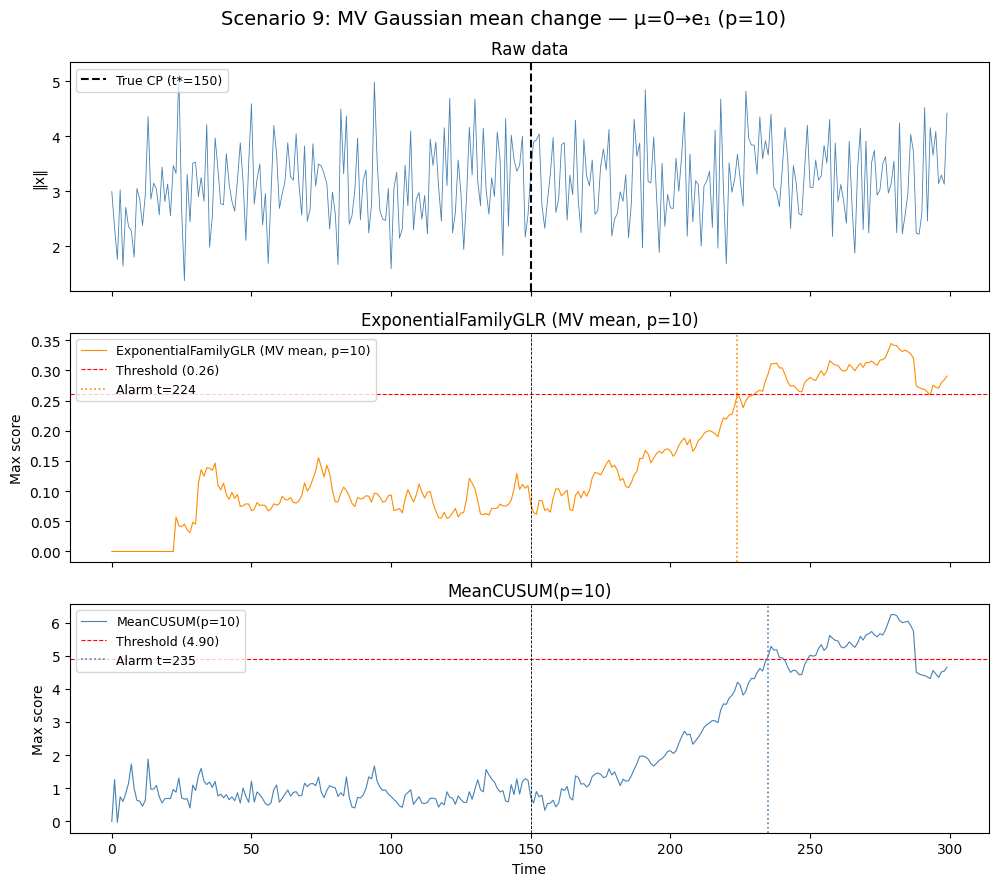

ExponentialFamilyGLR alarm:       224
MeanCUSUM alarm: 235

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...
  Ref: mc_alarm_times (K=1000) ...


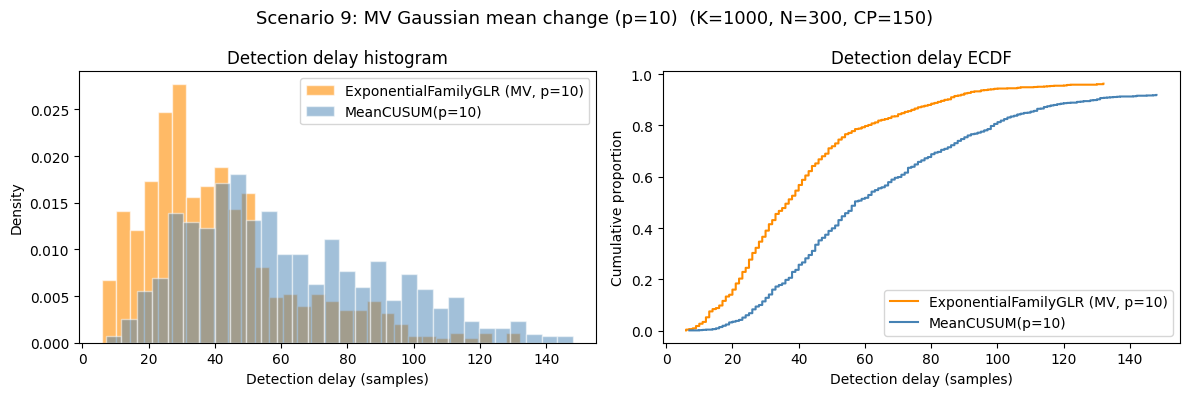

--------------------------------------------------------------------
Metric                    ExponentialFamilyGLR (MV, p=10)      MeanCUSUM(p=10)
--------------------------------------------------------------------
Detection rate                           0.963                0.919
Miss rate                                0.037                0.081
Mean delay                                40.6                 61.2
Median delay                              36.0                 55.0
False alarm (<CP)                        0.035                0.042
Null FAR                                 0.036                0.046
--------------------------------------------------------------------

Timing ...
ExponentialFamilyGLR:       26.9 ms/stream
MeanCUSUM: 3.5 ms/stream
Ratio:     7.61x


In [4]:
# Scenario 9: Multivariate Gaussian — change in mean (known cov = I, p=10)
# h(x) = x,  A(θ) = ½‖θ‖²,  ∇A = θ,  ∇²A = I
# Pre: N(0,I) → Post: N(μ₁,I), μ₁=(1,0,…,0)  |  N=300, CP=150
# Reference: MeanCUSUM(10)
# =============================================================================

P9 = 10
N9, CP9 = 300, 150
MU_POST9 = np.zeros(P9); MU_POST9[0] = 1.0   # shift first coordinate only

@nb.njit
def h9(x):
    return x.copy()

@nb.njit
def A9(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def Agrad9(theta):
    return theta.copy()

@nb.njit
def Ahess9(theta):
    return np.eye(theta.shape[0])

score9_ef  = ExponentialFamilyGLR(v=P9, n_features=P9, h=h9, A=A9,
                                     A_grad=Agrad9, A_hess=Ahess9)
score9_ref = MeanCUSUM(n_features=P9)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian mean, p=10) ...")

def _mv_pre9(rng=None):
    return np.random.default_rng().standard_normal(P9)

def _mv_post9(rng=None):
    return np.random.default_rng().standard_normal(P9) + MU_POST9

thr9_ef = calibrate_threshold(
    score9_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N9,
    pre_sampler=_mv_pre9,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr9_ef:.4f}")

print("Calibrating MeanCUSUM(p=10) ...")
thr9_ref = calibrate_threshold(
    score9_ref, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N9,
    pre_sampler=_mv_pre9,
    parallel=PARALLEL, rng=SEED,
)
print(f"  MeanCUSUM threshold: {thr9_ref:.4f}")

det9_ef  = GridDetector(score=score9_ef,  threshold=thr9_ef)
det9_ref = GridDetector(score=score9_ref, threshold=thr9_ref)

# -- Single-stream test --
rng9 = np.random.default_rng(SEED)
data9 = np.concatenate([
    rng9.multivariate_normal(np.zeros(P9), np.eye(P9), CP9),
    rng9.multivariate_normal(MU_POST9,     np.eye(P9), N9 - CP9),
])
outs9_ef,  stats9_ef  = run_and_collect(data9, det9_ef)
outs9_ref, stats9_ref = run_and_collect(data9, det9_ref)

plot_scenario(
    f"Scenario 9: MV Gaussian mean change — μ=0→e₁ (p={P9})",
    data9, stats9_ef, thr9_ef, first_alarm(outs9_ef), CP9,
    stats_ref=stats9_ref, threshold_ref=thr9_ref, alarm_ref=first_alarm(outs9_ref),
    ef_label="ExponentialFamilyGLR (MV mean, p=10)", ref_label="MeanCUSUM(p=10)",
    data_ylabel="‖x‖",
    data_transform=lambda d: np.linalg.norm(d, axis=1),
)
print(f"ExponentialFamilyGLR alarm:       {first_alarm(outs9_ef)}")
print(f"MeanCUSUM alarm: {first_alarm(outs9_ref)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res9 = run_sim_study(
    det9_ef, det9_ref,
    pre_sampler=_mv_pre9, post_sampler=_mv_post9,
    n_features=P9, N=N9, K=K_SIM, true_cp=CP9, rng=SEED,
)
plot_sim_study(res9, "Scenario 9: MV Gaussian mean change (p=10)",
               ef_label="ExponentialFamilyGLR (MV, p=10)", ref_label="MeanCUSUM(p=10)")

# -- Timing --
print("\nTiming ...")
t9_ef  = time_detector(det9_ef,  _mv_pre9, n_features=P9, N=N9)
t9_ref = time_detector(det9_ref, _mv_pre9, n_features=P9, N=N9)
print(f"ExponentialFamilyGLR:       {t9_ef*1000:.1f} ms/stream")
print(f"MeanCUSUM: {t9_ref*1000:.1f} ms/stream")
print(f"Ratio:     {t9_ef/t9_ref:.2f}x")

Calibrating ExponentialFamilyGLR (MV Gaussian covariance, p=5) ...


  EF threshold: 0.2339


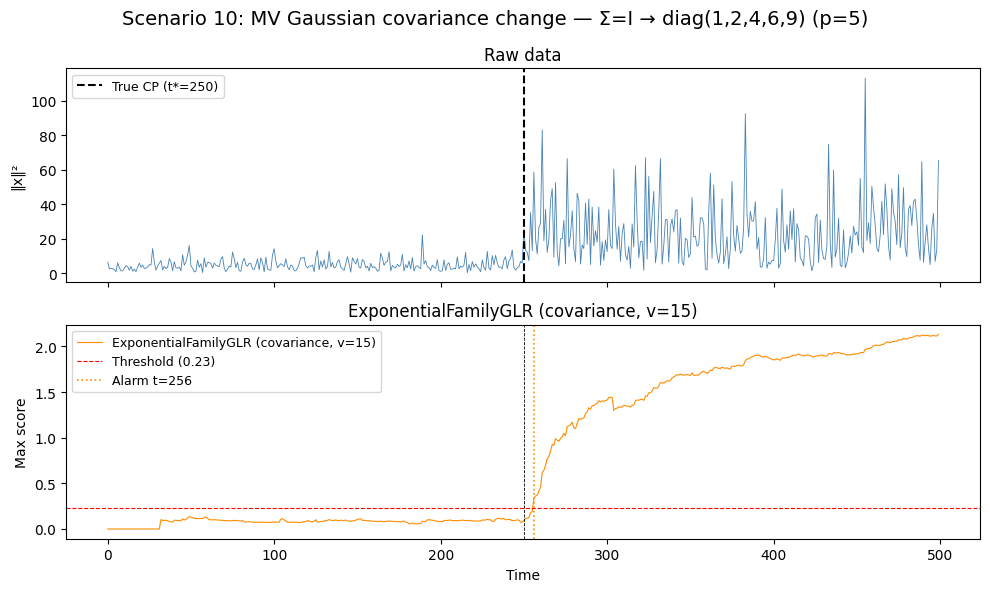

ExponentialFamilyGLR alarm: 256

Running simulation study ...
  ExponentialFamilyGLR: mc_alarm_times (K=1000) ...


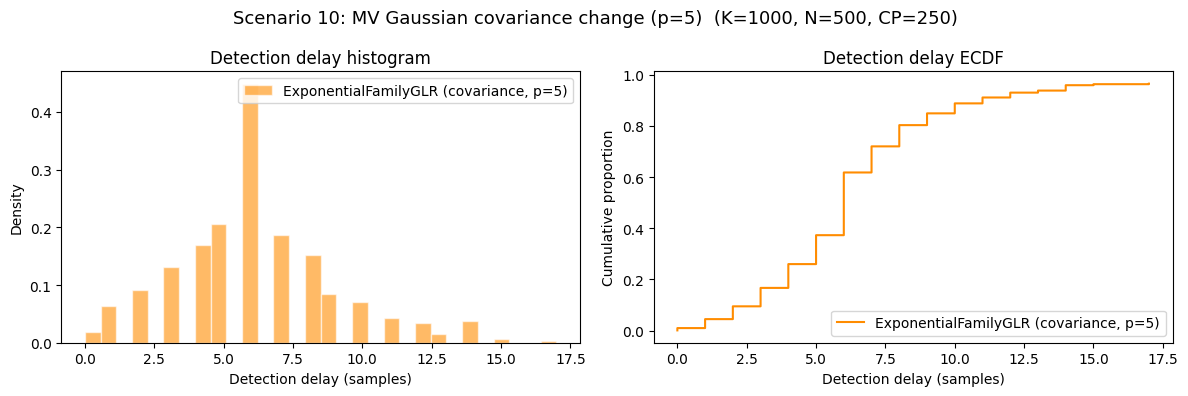

-----------------------------------------------
Metric                    ExponentialFamilyGLR (covariance, p=5)
-----------------------------------------------
Detection rate                           0.965
Miss rate                                0.035
Mean delay                                 6.1
Median delay                               6.0
False alarm (<CP)                        0.035
Null FAR                                 0.045
-----------------------------------------------

Timing ...
ExponentialFamilyGLR: 50.4 ms/stream


In [6]:
# Scenario 10: Multivariate Gaussian — change in covariance (known mean = 0, p=5)
# h(x) = vech(x xᵀ),  A(θ) = -½ log det(-2Θ)
# v = p(p+1)/2 = 15,  cov_parametrization=True
# Pre: N(0,I) → Post: N(0, diag(1,2,4,6,9))  |  N=500, CP=250
# =============================================================================

P10 = 5
V10 = P10 * (P10 + 1) // 2   # = 15
N10, CP10 = 500, 250
SIGMA_PRE10  = np.eye(P10)
SIGMA_POST10 = np.diag([1.0, 2.0, 4.0, 6.0, 9.0])

# -- h, A, Agrad, Ahess reuse the generic covariance functions from Scenario 8 --
# They are written generically via _p_from_v and _fill_sym, so they work for any p.

score10_ef = ExponentialFamilyGLR(
    v=V10, n_features=P10, h=h8, A=A8,
    A_grad=Agrad8, A_hess=Ahess8,
    theta_init=np.array([
        (-0.5 * np.linalg.inv(SIGMA_PRE10))[i, j]
        for i in range(P10) for j in range(i, P10)
    ], dtype=np.float64),
    cov_parametrization=True,
)

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (MV Gaussian covariance, p=5) ...")

def _mv_cov_pre10(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P10), SIGMA_PRE10)

def _mv_cov_post10(rng=None):
    return np.random.default_rng().multivariate_normal(np.zeros(P10), SIGMA_POST10)

thr10_ef = calibrate_threshold(
    score10_ef, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N10,
    pre_sampler=_mv_cov_pre10,
    parallel=PARALLEL, rng=SEED,
)
print(f"  EF threshold: {thr10_ef:.4f}")

det10_ef = GridDetector(score=score10_ef, threshold=thr10_ef)

# -- Single-stream test --
rng10 = np.random.default_rng(SEED)
data10 = np.concatenate([
    rng10.multivariate_normal(np.zeros(P10), SIGMA_PRE10,  CP10),
    rng10.multivariate_normal(np.zeros(P10), SIGMA_POST10, N10 - CP10),
])
outs10_ef, stats10_ef = run_and_collect(data10, det10_ef)

plot_scenario(
    f"Scenario 10: MV Gaussian covariance change — Σ=I → diag(1,2,4,6,9) (p={P10})",
    data10, stats10_ef, thr10_ef, first_alarm(outs10_ef), CP10,
    ef_label="ExponentialFamilyGLR (covariance, v=15)",
    data_ylabel="‖x‖²",
    data_transform=lambda d: np.sum(d ** 2, axis=1),
)
print(f"ExponentialFamilyGLR alarm: {first_alarm(outs10_ef)}")

# -- Simulation study --
print("\nRunning simulation study ...")
res10 = run_sim_study(
    det10_ef, None,
    pre_sampler=_mv_cov_pre10, post_sampler=_mv_cov_post10,
    n_features=P10, N=N10, K=K_SIM, true_cp=CP10, rng=SEED,
)
plot_sim_study(res10, "Scenario 10: MV Gaussian covariance change (p=5)",
               ef_label="ExponentialFamilyGLR (covariance, p=5)")

# -- Timing --
print("\nTiming ...")
t10_ef = time_detector(det10_ef, _mv_cov_pre10, n_features=P10, N=N10)
print(f"ExponentialFamilyGLR: {t10_ef*1000:.1f} ms/stream")

# ARL based on ocd-paper

  1/e = 0.3679
  ARL threshold (1/e-quantile of max scores): 13.6221

  Fraction alarmed (before truncation): 1.000  (100000/100000)
  Mean alarm time:   1918.9  (target γ = 2000)
  Median alarm time: 1347.0
  m(N) = median/log2: 1943.3


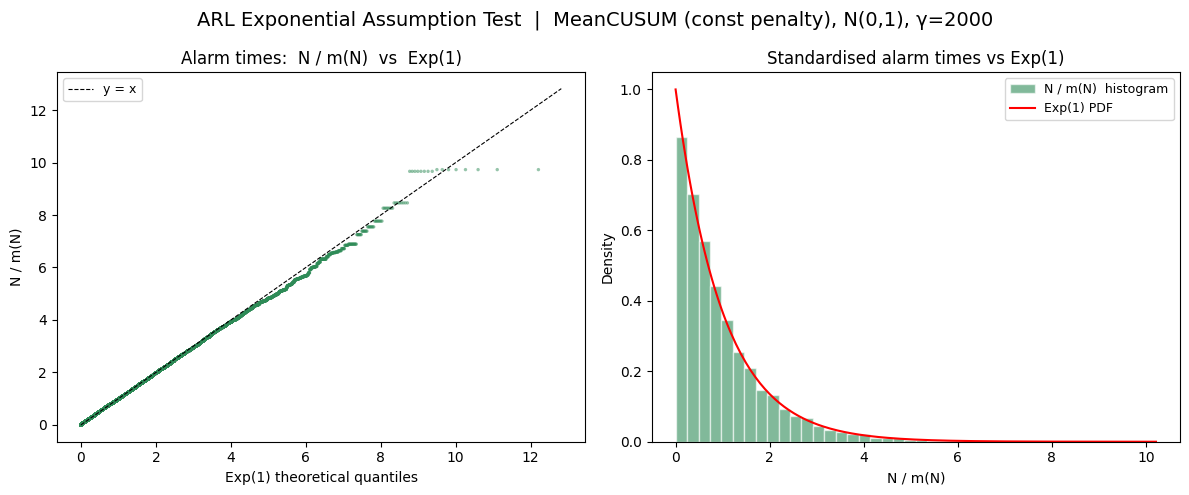


Summary
  Score model:              MeanCUSUM (constant penalty=1.0)
  Null distribution:        N(0, 1)
  Target ARL (γ):           2000
  MC paths (B):             5000
  ARL threshold:            13.6221
  Observed mean alarm time: 1918.9
  m(N) = median/log2:       1943.3
  Ratio (mean AT / γ):      0.959
  Alarmed fraction:         1.000


In [39]:
# ARL Exponential Assumption Test — MeanCUSUM (constant penalty), univariate N(0,1)
# =============================================================================
#
# The built-in MeanCUSUM uses an adaptive penalty log(t)+√log(t) that makes the
# statistic non-stationary.  For the OCD paper's ARL calibration to work we need
# a constant penalty so the max-score has a stable distribution over time.
#
# We wrap MeanCUSUM with penalty=1 (raw score, scale absorbed into threshold).
#
# Standardisation follows the OCD paper convention:
#   m(N) := median(N) / log(2)       (median-based scale estimate)
#   Standardised residual = N / m(N)
# If N ~ Exp(lambda), median = lambda * ln(2), so m(N) estimates lambda
# and N / m(N) ~ Exp(1).
# =============================================================================




# Constant penalty implementation
from dataclasses import dataclass
import numpy as np
from gridcp.scores._mean_cusum import mean_cusum_score
from gridcp.detector import GridDetector
from gridcp.calibration import calibrate_threshold, mc_alarm_times, mc_max_scores
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

@dataclass(frozen=True, slots=True)
class MeanCUSUMConstPenaltyState:
    """Running state for MeanCUSUMConstPenalty."""
    n_samples: int = 0
    sum: np.ndarray = None  # shape (n_features,)


@dataclass(frozen=True, slots=True)
class MeanCUSUMConstPenalty:
    """CUSUM score for a change in the mean with a *constant* penalty.

    Unlike the built-in MeanCUSUM (which uses an adaptive log(t)+√log(t) penalty),
    this class uses a fixed penalty so the score statistic is stationary under H0.

    Parameters
    ----------
    n_features : int
        Dimensionality of each observation.
    penalty : float
        Constant penalty applied to each score.  Use 1.0 for an unpenalised score
        (the scale is then absorbed into the threshold).
    """
    n_features: int = 1
    penalty: float = 1.0

    # -- ScoreModel protocol --------------------------------------------------

    def init_state(self) -> MeanCUSUMConstPenaltyState:
        return MeanCUSUMConstPenaltyState(sum=np.zeros(self.n_features))

    def update(
        self,
        state: MeanCUSUMConstPenaltyState,
        x,
    ) -> MeanCUSUMConstPenaltyState:
        x_arr = np.asarray(x, dtype=np.float64).reshape(-1)
        if x_arr.size != self.n_features:
            raise ValueError(
                f"Expected observation of size {self.n_features}, got {x_arr.size}."
            )
        return MeanCUSUMConstPenaltyState(
            n_samples=state.n_samples + 1,
            sum=state.sum + x_arr,
        )

    def compute_penalised_scores(
        self,
        state: MeanCUSUMConstPenaltyState,
        grid_states: list[MeanCUSUMConstPenaltyState],
    ) -> np.ndarray:
        if len(grid_states) == 0:
            raise ValueError("grid_states is empty.")

        grid_sums = np.stack([st.sum for st in grid_states])
        grid_n = np.array([st.n_samples for st in grid_states], dtype=np.int64)
        scores = mean_cusum_score(
            total_sum=state.sum,
            before_sums=grid_sums,
            total_samples=state.n_samples,
            before_samples=grid_n,
        )
        return scores / self.penalty

# ---- Parameters ----
gamma     = 2000    # target ARL
B         = 5000    # MC paths for max-score estimation
B_alarm   = 100000    # MC paths for alarm-time verification
SEED_ARL  = 42

# ---- Step 1: Collect max scores under H0 ----
score_const = MeanCUSUMConstPenalty(n_features=1, penalty=1.0)
det_no_alarm = GridDetector(score=score_const, threshold=1e12)

print(f"Collecting {B} max scores under H0  (MeanCUSUM const penalty, N(0,1), stream_len={gamma}) ...")
max_scores = mc_max_scores(
    det_no_alarm,
    n_paths=B,
    stream_len=gamma,
    pre_sampler=np.random.default_rng(0).standard_normal,
    rng=SEED_ARL,
    parallel=True,
)

# ---- Step 2: ARL threshold = (1/e)-quantile ----
inv_e = 1.0 / np.e
arl_threshold = float(np.quantile(max_scores, inv_e))

print(f"  1/e = {inv_e:.4f}")
print(f"  ARL threshold (1/e-quantile of max scores): {arl_threshold:.4f}")

# ---- Step 3: Alarm times with the ARL threshold ----
det_arl = GridDetector(score=MeanCUSUMConstPenalty(n_features=1, penalty=1.0),
                       threshold=arl_threshold)

stream_len_alarm = 10 * gamma
print(f"\nCollecting {B_alarm} alarm times  (threshold={arl_threshold:.4f}, "
      f"stream_len={stream_len_alarm}) ...")
alarm_times = mc_alarm_times(
    det_arl,
    n_paths=B_alarm,
    stream_len=stream_len_alarm,
    pre_sampler=np.random.default_rng(0).standard_normal,
    rng=SEED_ARL + 100,
    parallel=True,
)

alarm_times = alarm_times.astype(np.float64)
n_alarmed    = np.sum(alarm_times < stream_len_alarm)
frac_alarmed = n_alarmed / B_alarm
alarmed      = alarm_times[alarm_times < stream_len_alarm]
mean_alarm   = np.mean(alarmed) if n_alarmed > 0 else float("nan")
median_alarm = float(np.median(alarmed)) if n_alarmed > 0 else float("nan")
m_alarm      = median_alarm / np.log(2)  # OCD paper: m(N) = median(N) / log(2)

print(f"  Fraction alarmed (before truncation): {frac_alarmed:.3f}  ({n_alarmed}/{B_alarm})")
print(f"  Mean alarm time:   {mean_alarm:.1f}  (target \u03b3 = {gamma})")
print(f"  Median alarm time: {median_alarm:.1f}")
print(f"  m(N) = median/log2: {m_alarm:.1f}")

# ---- Step 4: Two-panel figure — alarm times only ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"ARL Exponential Assumption Test  |  MeanCUSUM (const penalty), N(0,1), \u03b3={gamma}",
    fontsize=14,
)

# --- Panel 1: QQ-plot of standardised alarm times N/m(N) vs Exp(1) ---
ax = axes[0]
if len(alarmed) > 1:
    sorted_at       = np.sort(alarmed)
    standardised_at = sorted_at / m_alarm    # N / m(N),  m(N) = median(N)/log2
    n_at            = len(standardised_at)
    theoretical_at  = sp_stats.expon.ppf((np.arange(1, n_at + 1) - 0.5) / n_at)

    ax.scatter(theoretical_at, standardised_at, s=6, alpha=0.5, color="seagreen", edgecolors="none")
    hi_at = max(theoretical_at.max(), standardised_at.max()) * 1.05
    ax.plot([0, hi_at], [0, hi_at], "k--", lw=0.8, label="y = x")
    ax.set_xlabel("Exp(1) theoretical quantiles")
    ax.set_ylabel("N / m(N)")
    ax.set_title("Alarm times:  N / m(N)  vs  Exp(1)")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "Too few alarms", transform=ax.transAxes,
            ha="center", va="center", fontsize=12)

# --- Panel 2: Histogram of standardised alarm times N/m(N) + Exp(1) PDF ---
ax = axes[1]
if len(alarmed) > 1:
    std_alarmed = alarmed / m_alarm          # N / m(N) — should be Exp(1) if correct
    ax.hist(std_alarmed, bins=40, density=True, alpha=0.6, color="seagreen",
            edgecolor="white", label="N / m(N)  histogram")
    xs = np.linspace(0, std_alarmed.max() * 1.05, 200)
    ax.plot(xs, sp_stats.expon.pdf(xs), "r-", lw=1.5,
            label="Exp(1) PDF")
    ax.set_xlabel("N / m(N)")
    ax.set_ylabel("Density")
    ax.set_title("Standardised alarm times vs Exp(1)")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "Too few alarms", transform=ax.transAxes,
            ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()

# ---- Summary statistics ----
print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"  Score model:              MeanCUSUM (constant penalty=1.0)")
print(f"  Null distribution:        N(0, 1)")
print(f"  Target ARL (\u03b3):           {gamma}")
print(f"  MC paths (B):             {B}")
print(f"  ARL threshold:            {arl_threshold:.4f}")
print(f"  Observed mean alarm time: {mean_alarm:.1f}")
print(f"  m(N) = median/log2:       {m_alarm:.1f}")
print(f"  Ratio (mean AT / \u03b3):      {mean_alarm / gamma:.3f}")
print(f"  Alarmed fraction:         {frac_alarmed:.3f}")
print("=" * 60)

### ARL Calibration Function

`calibrate_threshold_arl` mirrors `gridcp.calibration.calibrate_threshold` (FA-based)
but uses the **Average Run Length** approach from the OCD paper:

| | FA (`calibrate_threshold`) | ARL (`calibrate_threshold_arl`) |
|---|---|---|
| **Input** | `false_alarm_probability` α, `stream_len` N | `target_arl` γ |
| **Calibration stream length** | N (user-specified) | γ (= target ARL) |
| **Quantile level** | 1 − α | 1/e ≈ 0.368 |
| **Guarantee** | P(alarm before N) ≤ α | E[alarm time] ≈ γ |

In [28]:
from __future__ import annotations

import numpy as np
from typing import Any, Callable, Mapping

from gridcp.detector import GridDetector
from gridcp.calibration import mc_max_scores


def calibrate_threshold_arl(
    score: Any,
    *,
    target_arl: int,
    n_paths: int,
    pre_sampler: Callable[..., Any],
    rng: np.random.Generator | int | None = None,
    pre_args: tuple[Any, ...] = (),
    pre_kwargs: Mapping[str, Any] | None = None,
    n_features: int | None = None,
    parallel: bool = True,
    n_jobs: int | None = None,
    strict_equivalence: bool = False,
) -> float:
    """Estimate a score threshold via Average Run Length (ARL) calibration.

    Uses the ARL calibration procedure from the OCD paper: simulate *n_paths*
    null streams of length *target_arl*, collect the maximum score from each,
    and return the (1/e)-quantile.  This yields a detector whose expected alarm
    time under the null is approximately *target_arl*.

    Parameters
    ----------
    score : Any
        Score model compatible with ``GridDetector``.
    target_arl : int
        Desired average run length under the null (γ in the OCD paper).
        Also used as the calibration stream length.
    n_paths : int
        Number of Monte Carlo paths (B in the OCD paper).
    pre_sampler : callable
        Null-distribution sampler.
    rng : numpy.random.Generator | int | None, optional
        Randomness control passed to Monte Carlo simulation.  Must be one of:
        ``numpy.random.Generator``, ``int`` seed, or ``None``.
        ``None`` uses a fixed default seed for deterministic behavior.
    pre_args, pre_kwargs : optional
        Additional arguments passed to ``pre_sampler``.
    n_features : int, optional
        Number of features per sample.  If omitted, this is inferred from
        ``score.n_features`` when available.  For custom score objects that do
        not expose ``n_features``, this argument must be provided explicitly.
    parallel : bool, default True
        Whether to run Monte Carlo paths in parallel.
    n_jobs : int or None, optional
        Number of parallel workers.  ``None`` uses automatic core detection.
    strict_equivalence : bool, default False
        If ``True``, sample generation is serial (only evaluation is parallel),
        guaranteeing identical output to ``parallel=False``.

    Returns
    -------
    float
        The ARL threshold: (1/e)-quantile of null max scores.

    Notes
    -----
    The (1/e)-quantile arises because, under the exponential approximation
    for alarm times, P(max_score > threshold) = 1 − 1/e ≈ 0.632 corresponds
    to E[alarm time] = γ.  See the OCD paper for a full derivation.

    Examples
    --------
    >>> from gridcp.scores import MeanCUSUM
    >>> threshold = calibrate_threshold_arl(
    ...     MeanCUSUM(n_features=1),
    ...     target_arl=2000,
    ...     n_paths=2000,
    ...     pre_sampler=np.random.default_rng(0).standard_normal,
    ...     rng=42,
    ... )
    """
    if target_arl < 1:
        raise ValueError("target_arl must be a positive integer.")

    inferred_n_features = n_features
    if inferred_n_features is None:
        score_n_features = getattr(score, "n_features", None)
        if score_n_features is None:
            raise ValueError(
                "n_features was not provided and could not be inferred "
                "from score.n_features."
            )
        inferred_n_features = int(score_n_features)

    detector = GridDetector(score=score, threshold=1e12)

    max_scores = mc_max_scores(
        detector=detector,
        n_paths=n_paths,
        stream_len=target_arl,
        pre_sampler=pre_sampler,
        rng=rng,
        pre_args=pre_args,
        pre_kwargs=pre_kwargs,
        n_features=inferred_n_features,
        parallel=parallel,
        n_jobs=n_jobs,
        strict_equivalence=strict_equivalence,
    )
    return float(np.quantile(max_scores, 1.0 / np.e))


print("calibrate_threshold_arl defined.")

calibrate_threshold_arl defined.


Target FAP α = 0.05
Evaluation horizon N = 200
Implied ARL γ = -N/log(1-α) = 3899.1

ARL-calibrating MeanCUSUMConstPenalty ...
  ARL threshold (γ=3900): 15.0191
  Time elapsed: 35.15 seconds
FA-calibrating MeanCUSUM ...
  FA threshold for MeanCUSUM (α=0.05): 2.9493
  Time elapsed: 2.90 seconds

Sweeping Δμ ...


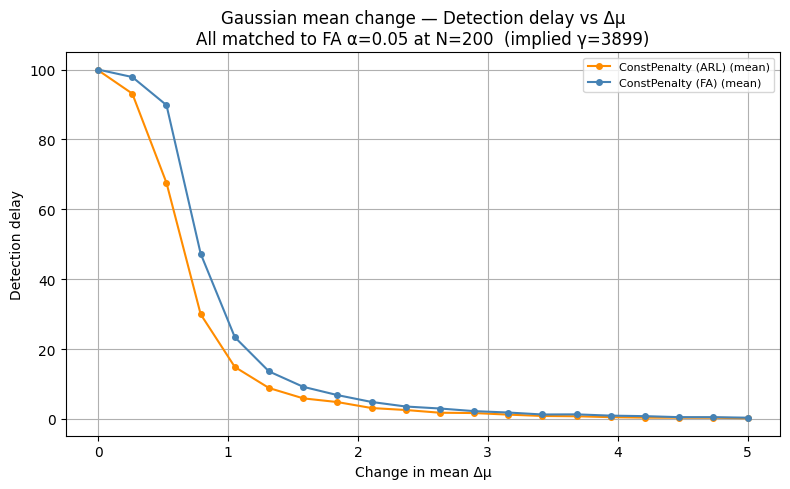


Thresholds:
  MeanCUSUM (FA):       2.9493
  MeanCUSUMConstPenalty (ARL γ=3900): 15.0191


In [ ]:
# Fair comparison: FA-calibrated vs ARL-calibrated — matched false alarm rate
# =============================================================================
# All detectors are calibrated to the SAME false alarm probability α=0.05
# at the evaluation horizon N1=200.
#
# - ExponentialFamilyGLR:       FAP calibration (direct, from Scenario 1)
# - MeanCUSUM (adaptive):       FAP calibration (direct, from Scenario 1)
# - MeanCUSUMConstPenalty (ARL): ARL calibration with γ = -N / log(1-α)
#   This γ is chosen so that the implied FAP over N samples matches α.
# - MeanCUSUMConstPenalty (FAP): FAP calibration (direct, for comparison)
# =============================================================================

alpha_target = ALPHA  # 0.05
# Implied ARL from FAP:  γ = -N / log(1 - α)
gamma_implied = -N1 / np.log(1.0 - alpha_target)
print(f"Target FAP α = {alpha_target}")
print(f"Evaluation horizon N = {N1}")
print(f"Implied ARL γ = -N/log(1-α) = {gamma_implied:.1f}")

# -- ARL-calibrate MeanCUSUMConstPenalty to match the same false alarm rate --
score_cp = MeanCUSUMConstPenalty(n_features=1, penalty=1.0)
print("\nARL-calibrating MeanCUSUMConstPenalty ...")
start_time = time.time()
thr_cp_arl = calibrate_threshold_arl(
    score_cp,
    target_arl=int(np.ceil(gamma_implied)),
    n_paths=K_CAL,
    pre_sampler=np.random.default_rng(0).standard_normal,
    rng=SEED,
    parallel=PARALLEL,
)
print(f"  ARL threshold (γ={int(np.ceil(gamma_implied))}): {thr_cp_arl:.4f}")
print(f"  Time elapsed: {time.time() - start_time:.2f} seconds")

det_cp_arl = GridDetector(score=score_cp, threshold=thr_cp_arl)

# -- Also FA-calibrate MeanCUSUM for direct comparison --
score = MeanCUSUM(n_features=1)
print("FA-calibrating MeanCUSUM ...")
start_time = time.time()
thr_cp_fap = calibrate_threshold(
    score, false_alarm_probability=alpha_target,
    n_paths=K_CAL, stream_len=N1,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  FA threshold for MeanCUSUM (α={alpha_target}): {thr_cp_fap:.4f}")
print(f"  Time elapsed: {time.time() - start_time:.2f} seconds")

det_cp_fap = GridDetector(score=score, threshold=thr_cp_fap)

# -- δ-sweep: all detectors matched to same FA --
deltas_cmp = np.linspace(0.0, 5.0, num=20)

def post_sampler_factory_cmp(delta):
    mu_post = MU_PRE1 + delta
    def sampler(rng=None, _d=mu_post):
        return np.random.default_rng().normal(_d, 1.0)
    return sampler

print("\nSweeping Δμ ...")
sweep_cmp = sweep_detection_delay(
    [("Const penalty (ARL)", det_cp_arl),
     ("Log penalty (FA)", det_cp_fap)],
    deltas_cmp,
    pre_sampler=np.random.default_rng(0).standard_normal,
    post_sampler_factory=post_sampler_factory_cmp,
    N=N1, CP=CP1, K=100, rng=SEED
)

plot_detection_delay(
    deltas_cmp, sweep_cmp,
    f"Gaussian mean change — Detection delay vs Δμ\n"
    f"All matched to FA α={alpha_target} at N={N1}  (implied γ={gamma_implied:.0f})",
    xlabel="Change in mean Δμ",
    borders=False,
)

print(f"\nThresholds:")
print(f"  MeanCUSUM (FA):       {thr_cp_fap:.4f}")
print(f"  MeanCUSUMConstPenalty (ARL γ={int(np.ceil(gamma_implied))}): {thr_cp_arl:.4f}")

# Fixing non-Numba usability

In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold, mc_max_scores, mc_alarm_times
from gridcp.scores._mean_cusum import MeanCUSUM

# ---- Constants ----
K_CAL   = 2000   # calibration paths
K_SIM   = 1000   # simulation paths
ALPHA   = 0.05   # false alarm prob
SEED    = 42
K_TIME  = 50     # timing repetitions
PARALLEL = True

# ---- Run one stream and collect outputs + max-score trace ----

def run_and_collect(data, detector):
    """Feed *data* (N, n_features) through *detector*, return (outputs, scores)."""
    state = detector.init_state()
    outputs, scores = [], []
    for t in range(len(data)):
        state, out = detector.update(state, data[t])
        outputs.append(out)
        scores.append(out["max_score"])
    return outputs, np.array(scores)


def first_alarm(outputs):
    for i, o in enumerate(outputs):
        if o["alarm"]:
            return i
    return None


# ---- Plotting: single-stream comparison ----

def plot_scenario(title, data, stats_ef, threshold_ef, alarm_ef, true_cp,
                  *, stats_ref=None, threshold_ref=None, alarm_ref=None,
                  ef_label="ExponentialFamilyGLR", ref_label="MeanCUSUM",
                  data_ylabel="Observation", data_transform=None):
    has_ref = stats_ref is not None
    nrows = 3 if has_ref else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 3.0 * nrows), sharex=True)
    fig.suptitle(title, fontsize=14)

    # Raw data
    raw = data_transform(data) if data_transform is not None else data[:, 0]
    axes[0].plot(raw, lw=0.6, color="steelblue")
    axes[0].axvline(true_cp, ls="--", color="black", label=f"True CP (t*={true_cp})")
    axes[0].legend(loc="upper left", fontsize=9)
    axes[0].set_ylabel(data_ylabel)
    axes[0].set_title("Raw data")

    # EF score
    axes[1].plot(stats_ef, lw=0.8, color="darkorange", label=f"{ef_label}")
    axes[1].axhline(threshold_ef, ls="--", color="red", lw=0.8,
                    label=f"Threshold ({threshold_ef:.2f})")
    if alarm_ef is not None:
        axes[1].axvline(alarm_ef, ls=":", color="darkorange", lw=1.2,
                        label=f"Alarm t={alarm_ef}")
    axes[1].axvline(true_cp, ls="--", color="black", lw=0.6)
    axes[1].legend(loc="upper left", fontsize=9)
    axes[1].set_ylabel("Max score")
    axes[1].set_title(ef_label)

    # Reference score
    if has_ref:
        axes[2].plot(stats_ref, lw=0.8, color="steelblue", label=ref_label)
        axes[2].axhline(threshold_ref, ls="--", color="red", lw=0.8,
                        label=f"Threshold ({threshold_ref:.2f})")
        if alarm_ref is not None:
            axes[2].axvline(alarm_ref, ls=":", color="steelblue", lw=1.2,
                            label=f"Alarm t={alarm_ref}")
        axes[2].axvline(true_cp, ls="--", color="black", lw=0.6)
        axes[2].legend(loc="upper left", fontsize=9)
        axes[2].set_ylabel("Max score")
        axes[2].set_title(ref_label)

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


# ---- Simulation study helper ----

def _compute_metrics(alarms, null_alarms, N, true_cp):
    K = len(alarms)
    Knull = len(null_alarms)
    # Only count alarms at or after the true CP as correct detections
    correct = alarms[(alarms < N) & (alarms >= true_cp)]
    false_pre_cp = np.sum((alarms < N) & (alarms < true_cp))  # alarms before CP
    n_correct = len(correct)
    delays = correct - true_cp
    null_fa = np.sum(null_alarms < N)
    return {
        "detection_rate": n_correct / K,
        "miss_rate": 1.0 - n_correct / K,
        "mean_delay": np.mean(delays) if n_correct > 0 else float("nan"),
        "median_delay": np.median(delays) if n_correct > 0 else float("nan"),
        "false_pre_cp": false_pre_cp / K,
        "null_FAR": null_fa / Knull if Knull > 0 else float("nan"),
    }


def run_sim_study(det_ef, det_ref, *, pre_sampler, post_sampler,
                  n_features, N, K, true_cp, rng=SEED):
    """Monte-Carlo simulation: alarm-time arrays for EF (and optionally ref)."""
    print(f"  ExponentialFamilyGLR: mc_alarm_times (K={K}) ...")
    alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler, post_sampler=post_sampler,
        changepoint=true_cp, parallel=PARALLEL, rng=rng,
    )
    null_alarms_ef = mc_alarm_times(
        det_ef, n_paths=K, stream_len=N,
        pre_sampler=pre_sampler,
        parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
    )
    results = {"alarms_ef": alarms_ef, "null_alarms_ef": null_alarms_ef, "N": N, "true_cp": true_cp}

    if det_ref is not None:
        print(f"  Ref: mc_alarm_times (K={K}) ...")
        alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler, post_sampler=post_sampler,
            changepoint=true_cp, parallel=PARALLEL, rng=rng,
        )
        null_alarms_ref = mc_alarm_times(
            det_ref, n_paths=K, stream_len=N,
            pre_sampler=pre_sampler,
            parallel=PARALLEL, rng=rng + 1 if isinstance(rng, int) else rng,
        )
        results["alarms_ref"] = alarms_ref
        results["null_alarms_ref"] = null_alarms_ref
    return results


def plot_sim_study(results, title, *, ef_label="ExponentialFamilyGLR",
                   ref_label="MeanCUSUM"):
    N, true_cp = results["N"], results["true_cp"]
    K = len(results["alarms_ef"])
    has_ref = "alarms_ref" in results

    alarms_ef = results["alarms_ef"]
    m_ef = _compute_metrics(alarms_ef, results["null_alarms_ef"], N, true_cp)
    correct_ef = alarms_ef[(alarms_ef < N) & (alarms_ef >= true_cp)]
    delays_ef = correct_ef - true_cp

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  (K={K}, N={N}, CP={true_cp})", fontsize=13)

    axes[0].hist(delays_ef, bins=30, alpha=0.6, color="darkorange",
                 edgecolor="white", label=ef_label, density=True)
    axes[0].set_xlabel("Detection delay (samples)")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Detection delay histogram")

    sorted_ef = np.sort(delays_ef)
    ecdf_ef = np.arange(1, len(sorted_ef) + 1) / K
    axes[1].step(sorted_ef, ecdf_ef, color="darkorange", lw=1.5, label=ef_label, where="post")
    axes[1].set_xlabel("Detection delay (samples)")
    axes[1].set_ylabel("Cumulative proportion")
    axes[1].set_title("Detection delay ECDF")

    if has_ref:
        alarms_ref = results["alarms_ref"]
        m_ref = _compute_metrics(alarms_ref, results["null_alarms_ref"], N, true_cp)
        correct_ref = alarms_ref[(alarms_ref < N) & (alarms_ref >= true_cp)]
        delays_ref = correct_ref - true_cp

        axes[0].hist(delays_ref, bins=30, alpha=0.5, color="steelblue",
                     edgecolor="white", label=ref_label, density=True)
        sorted_ref = np.sort(delays_ref)
        ecdf_ref = np.arange(1, len(sorted_ref) + 1) / K
        axes[1].step(sorted_ref, ecdf_ref, color="steelblue", lw=1.5,
                     label=ref_label, where="post")

    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # Print metrics table
    header = f"{'Metric':<25} {ef_label:>20}"
    sep    = "-" * 47
    if has_ref:
        header += f" {ref_label:>20}"
        sep = "-" * 68
    print(sep)
    print(header)
    print(sep)
    rows = [
        ("Detection rate",  f"{m_ef['detection_rate']:.3f}"),
        ("Miss rate",       f"{m_ef['miss_rate']:.3f}"),
        ("Mean delay",      f"{m_ef['mean_delay']:.1f}"),
        ("Median delay",    f"{m_ef['median_delay']:.1f}"),
        ("False alarm (<CP)", f"{m_ef['false_pre_cp']:.3f}"),
        ("Null FAR",        f"{m_ef['null_FAR']:.3f}"),
    ]
    if has_ref:
        rows_ref = [
            f"{m_ref['detection_rate']:.3f}",
            f"{m_ref['miss_rate']:.3f}",
            f"{m_ref['mean_delay']:.1f}",
            f"{m_ref['median_delay']:.1f}",
            f"{m_ref['false_pre_cp']:.3f}",
            f"{m_ref['null_FAR']:.3f}",
        ]
        for (name, val_ef), val_ref in zip(rows, rows_ref):
            print(f"{name:<25} {val_ef:>20} {val_ref:>20}")
    else:
        for name, val_ef in rows:
            print(f"{name:<25} {val_ef:>20}")
    print(sep)


# ---- Timing helper ----

def time_detector(detector, pre_sampler, *, n_features, N, K_time=K_TIME):
    """Return mean wall-clock seconds per stream (JIT warm-up excluded)."""
    rng_t = np.random.default_rng(99)
    data = np.empty((K_time + 1, N, n_features), dtype=np.float64)
    for i in range(K_time + 1):
        for t in range(N):
            raw = pre_sampler()
            data[i, t, :] = np.asarray(raw, dtype=np.float64).reshape(-1)[:n_features]

    # Warm-up run (JIT compilation)
    state = detector.init_state()
    for t in range(N):
        state, _ = detector.update(state, data[0, t])

    # Timed runs
    start = time.perf_counter()
    for i in range(1, K_time + 1):
        state = detector.init_state()
        for t in range(N):
            state, _ = detector.update(state, data[i, t])
    elapsed = time.perf_counter() - start
    return elapsed / K_time


# ---- Detection delay sweep helpers ----

def sweep_detection_delay(detectors, deltas, *, pre_sampler, post_sampler_factory,
                          N, CP, K=K_SIM, rng=SEED):
    """Sweep over change sizes and compute detection delay statistics.

    Returns
    -------
    dict  {label: {"median": [...], "mean": [...],
                    "q10": [...], "q25": [...], "q75": [...], "q90": [...]}}
    """
    results = {label: {"median": [], "mean": [], "q10": [], "q25": [], "q75": [], "q90": []}
               for label, _ in detectors}
    for i, delta in enumerate(deltas):
        post_sampler = post_sampler_factory(delta)
        for label, det in detectors:
            alarms = mc_alarm_times(
                det, n_paths=K, stream_len=N,
                pre_sampler=pre_sampler, post_sampler=post_sampler,
                changepoint=CP, parallel=PARALLEL, rng=rng,
            )
            dd = alarms - CP
            dd = dd[dd >= 0]
            if len(dd) > 0:
                results[label]["median"].append(np.median(dd))
                results[label]["mean"].append(np.mean(dd))
                results[label]["q10"].append(np.percentile(dd, 10))
                results[label]["q25"].append(np.percentile(dd, 25))
                results[label]["q75"].append(np.percentile(dd, 75))
                results[label]["q90"].append(np.percentile(dd, 90))
            else:
                for key in results[label]:
                    results[label][key].append(np.nan)
    return results


def plot_detection_delay(deltas, results, title, *, xlabel="Change size", borders=True):
    """Plot mean detection delay with IQR and 10-90% quantile bands."""
    colors = ["darkorange", "steelblue", "green", "purple", "red"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx, (label, stats) in enumerate(results.items()):
        c = colors[idx % len(colors)]
        avg = np.array(stats["mean"])
        q10 = np.array(stats["q10"])
        q25 = np.array(stats["q25"])
        q75 = np.array(stats["q75"])
        q90 = np.array(stats["q90"])
        if borders:
            ax.fill_between(deltas, q10, q90, color=c, alpha=0.15, label=f"{label} (10–90%)")
            ax.fill_between(deltas, q25, q75, color=c, alpha=0.3, label=f"{label} (IQR)")
        ax.plot(deltas, avg, marker="o", color=c, markersize=4, label=f"{label} (mean)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Detection delay")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


print("Shared helpers defined.")

Shared helpers defined.


In [2]:
"""Generalised Likelihood Ratio (GLR) score for canonical exponential families.

Supports any exponential family whose log-partition function A has known first
and second derivatives (or gradient and Hessian for v > 1) that can be supplied
as Numba-compiled callables.  The user provides the sufficient statistic h, the
log-partition A, and its derivatives; the module builds JIT-compiled Newton MLE
solvers and GLR kernels at construction time.
"""

import math
from dataclasses import dataclass

import numba as nb
import numpy as np

from gridcp.typing import ArrayLike

# ---------------------------------------------------------------------------
# Module-level Numba helpers
# ---------------------------------------------------------------------------


@nb.njit(cache=True, inline="always")
def _norm(a):
    """Euclidean norm of a 1-D array."""
    s = 0.0
    for i in range(a.shape[0]):
        s += a[i] * a[i]
    return math.sqrt(s)


@nb.njit(cache=True, inline="always")
def _solve(H_reg, residual):
    """Solve H_reg @ x = residual with explicit formulas for n<=3."""
    n = H_reg.shape[0]
    if n == 2:
        det = H_reg[0, 0] * H_reg[1, 1] - H_reg[0, 1] * H_reg[1, 0]
        inv_det = 1.0 / det
        x0 = (H_reg[1, 1] * residual[0] - H_reg[0, 1] * residual[1]) * inv_det
        x1 = (H_reg[0, 0] * residual[1] - H_reg[1, 0] * residual[0]) * inv_det
        return np.array([x0, x1])
    elif n == 3:
        a, b, c = H_reg[0, 0], H_reg[0, 1], H_reg[0, 2]
        d, e, f = H_reg[1, 0], H_reg[1, 1], H_reg[1, 2]
        g, h, k = H_reg[2, 0], H_reg[2, 1], H_reg[2, 2]
        det = a * (e * k - f * h) - b * (d * k - f * g) + c * (d * h - e * g)
        inv_det = 1.0 / det
        x0 = (
            (e * k - f * h) * residual[0]
            + (c * h - b * k) * residual[1]
            + (b * f - c * e) * residual[2]
        ) * inv_det
        x1 = (
            (f * g - d * k) * residual[0]
            + (a * k - c * g) * residual[1]
            + (c * d - a * f) * residual[2]
        ) * inv_det
        x2 = (
            (d * h - e * g) * residual[0]
            + (b * g - a * h) * residual[1]
            + (a * e - b * d) * residual[2]
        ) * inv_det
        return np.array([x0, x1, x2])
    else:
        return np.linalg.solve(H_reg, residual)

def _is_numba_compiled(fn):
    """Check if a function is Numba-compiled."""
    return hasattr(fn, 'py_func')

# ---------------------------------------------------------------------------
# Newton solvers
# ---------------------------------------------------------------------------

def make_newton_solver(A_prime, A_dprime):
    """Build a scalar Newton MLE solver for a 1D exponential family.

    Solves the MLE equation A'(θ) = S / n by Newton iterations. A domain
    guard prevents the iterate from crossing zero when ``theta_init`` is
    non-zero, which is necessary for families whose natural parameter domain
    excludes zero (e.g. Gaussian-variance with θ < 0, Exponential with θ < 0).

    Parameters
    ----------
    A_prime : callable
        First derivative of the log-partition function A.
    A_dprime : callable
        Second derivative of A (must return a positive float).

    Returns
    -------
    callable
        ``solver(S, n, theta_init, tol=1e-8, max_iter=50) -> float``
        that returns the MLE θ satisfying A'(θ) ≈ S / n.
    """
    use_numba = _is_numba_compiled(A_prime) and _is_numba_compiled(A_dprime)

    if use_numba:
        @nb.njit(cache=True)
        def solver(S, n, theta_init, tol=1e-8, max_iter=50):
            theta = theta_init
            target = S / n
            for _ in range(max_iter):
                residual = A_prime(theta) - target
                if abs(residual) < tol:
                    return theta
                adp = A_dprime(theta)
                if adp < 1e-15:
                    return theta
                theta_new = theta - residual / adp
                # Domain guard: prevent crossing zero for log-barrier-type families
                #if theta_init < 0.0 and theta_new >= 0.0:
                #    theta_new = theta * 0.1
                #elif theta_init > 0.0 and theta_new <= 0.0:
                #    theta_new = theta * 0.1
                theta = theta_new
            return theta
    else:
        def solver(S, n, theta_init, tol=1e-8, max_iter=50):
            theta = theta_init
            target = S / n
            for _ in range(max_iter):
                residual = A_prime(theta) - target
                if abs(residual) < tol:
                    return theta
                adp = A_dprime(theta)
                if adp < 1e-15:
                    return theta
                theta_new = theta - residual / adp
                # Domain guard: prevent crossing zero for log-barrier-type families
                #if theta_init < 0.0 and theta_new >= 0.0:
                #    theta_new = theta * 0.1
                #elif theta_init > 0.0 and theta_new <= 0.0:
                #    theta_new = theta * 0.1
                theta = theta_new
            return theta
    return solver


def make_vector_newton_solver(A_grad, A_hess):
    """Build a vector Newton MLE solver with backtracking line search.

    Solves the MLE equation ∇A(θ) = S / n by damped Newton iterations.
    The Hessian is regularised by adding 1e-6 to the diagonal to improve
    conditioning, and a backtracking line search ensures each step reduces
    the residual norm.

    Parameters
    ----------
    A_grad : callable
        Gradient of A, mapping shape ``(v,) -> (v,)``.
    A_hess : callable
        Hessian of A, mapping shape ``(v,) -> (v, v)``.

    Returns
    -------
    callable
        ``solver(S_vec, n, theta_init, tol=1e-8, max_iter=50) -> np.ndarray``
        that returns the MLE θ satisfying ∇A(θ) ≈ S_vec / n.
    """
    use_numba = _is_numba_compiled(A_grad) and _is_numba_compiled(A_hess)

    if use_numba:
        @nb.njit(cache=True)
        def solver(S_vec, n, theta_init, tol=1e-8, max_iter=50):
            theta = theta_init.copy()
            target = S_vec / n

            grad = A_grad(theta)
            residual = grad - target
            res_norm = _norm(residual)

            for _ in range(max_iter):
                if res_norm < tol:
                    return theta
                if not np.isfinite(res_norm):
                    return theta

                H = A_hess(theta)
                h_finite = True
                for i in range(H.shape[0]):
                    if not np.isfinite(H[i, i]):
                        h_finite = False
                        break
                if not h_finite:
                    return theta

                for i in range(H.shape[0]):
                    H[i, i] += 1e-6

                step = _solve(H, residual)

                accepted = False
                step_scale = 1.0
                for _ in range(20):
                    theta_cand = theta - step_scale * step
                    grad_cand = A_grad(theta_cand)
                    residual_cand = grad_cand - target
                    res_norm_cand = _norm(residual_cand)
                    if np.isfinite(res_norm_cand) and res_norm_cand <= res_norm:
                        theta = theta_cand
                        grad = grad_cand
                        residual = residual_cand
                        res_norm = res_norm_cand
                        accepted = True
                        break
                    step_scale *= 0.5

                if not accepted:
                    return theta

            return theta

    else:
        def solver(S_vec, n, theta_init, tol=1e-8, max_iter=50):
            theta = theta_init.copy()
            target = S_vec / n

            grad = A_grad(theta)
            residual = grad - target
            res_norm = np.linalg.norm(residual)

            for _ in range(max_iter):
                if res_norm < tol:
                    return theta
                if not np.isfinite(res_norm):
                    return theta

                H = A_hess(theta)
                if not np.all(np.isfinite(np.diag(H))):
                    return theta

                H = H + 1e-6 * np.eye(H.shape[0])
                step = np.linalg.solve(H, residual)

                accepted = False
                step_scale = 1.0
                for _ in range(20):
                    theta_cand = theta - step_scale * step
                    grad_cand = A_grad(theta_cand)
                    residual_cand = grad_cand - target
                    res_norm_cand = np.linalg.norm(residual_cand)
                    if np.isfinite(res_norm_cand) and res_norm_cand <= res_norm:
                        theta = theta_cand
                        grad = grad_cand
                        residual = residual_cand
                        res_norm = res_norm_cand
                        accepted = True
                        break
                    step_scale *= 0.5

                if not accepted:
                    return theta

            return theta

    return solver

# ---------------------------------------------------------------------------
# GLR kernel factories
# ---------------------------------------------------------------------------

def _make_scalar_glr_kernel(A, solver, A_prime, A_dprime, theta_init, min_seg):
    """Build a GLR kernel for the scalar (v=1) case.

    Parameters
    ----------
    A : callable
        Log-partition function, ``float -> float``.
    solver : callable
        Scalar Newton MLE solver, as produced by ``make_newton_solver``.
    A_prime : callable
        First derivative of A.
    A_dprime : callable
        Second derivative of A.
    theta_init : float
        Starting point for the Newton MLE solver. Must lie in the interior
        of the natural parameter domain for the family. The solver does not
        perform domain checking and may diverge or produce invalid results
        if theta_init is on or near a domain boundary.
    min_seg : int
        Minimum number of observations required on each side of a candidate
        changepoint; candidates with fewer are assigned a score of 0.

    Returns
    -------
    callable
        ``kernel(total_stat, before_stats, t, before_n) -> np.ndarray``
        returning raw (unpenalised) GLR scores for all candidates.
    """
    use_numba = (
        _is_numba_compiled(A)
        and _is_numba_compiled(solver)
        and _is_numba_compiled(A_prime)
        and _is_numba_compiled(A_dprime)
    )

    if use_numba:
        @nb.njit(cache=True)
        def kernel(total_stat, before_stats, t, before_n):
            n_cand = before_n.shape[0]
            out = np.zeros(n_cand, dtype=np.float64)
            S_total = total_stat[0]
            adp0 = A_dprime(theta_init)
            if adp0 < 1e-15:
                adp0 = 1e-15
            A_prime_init = A_prime(theta_init)

            for i in range(n_cand):
                n_pre = before_n[i]
                n_post = t - n_pre
                if n_pre < min_seg or n_post < min_seg:
                    continue

                S_pre = before_stats[i, 0]
                S_post = S_total - S_pre

                # Warm-start: one Newton step from theta_init
                warm_pre = theta_init + (S_pre / n_pre - A_prime_init) / adp0
                warm_post = theta_init + (S_post / n_post - A_prime_init) / adp0
                warm_null = theta_init + (S_total / t - A_prime_init) / adp0

                # Domain guard: keep warm-start on same side of zero as theta_init
                if theta_init < 0.0:
                    if warm_pre >= 0.0:
                        warm_pre = theta_init * 0.1
                    if warm_post >= 0.0:
                        warm_post = theta_init * 0.1
                    if warm_null >= 0.0:
                        warm_null = theta_init * 0.1
                elif theta_init > 0.0:
                    if warm_pre <= 0.0:
                        warm_pre = theta_init * 0.1
                    if warm_post <= 0.0:
                        warm_post = theta_init * 0.1
                    if warm_null <= 0.0:
                        warm_null = theta_init * 0.1

                th_pre = solver(S_pre, n_pre, warm_pre)
                th_post = solver(S_post, n_post, warm_post)
                th_null = solver(S_total, t, warm_null)

                ell_pre = th_pre * S_pre - n_pre * A(th_pre)
                ell_post = th_post * S_post - n_post * A(th_post)
                ell_null = th_null * S_total - t * A(th_null)

                glr = ell_pre + ell_post - ell_null
                out[i] = glr if glr > 0.0 else 0.0

            return out
    else:
        def kernel(total_stat, before_stats, t, before_n):
            n_cand = before_n.shape[0]
            out = np.zeros(n_cand, dtype=np.float64)
            S_total = total_stat[0]
            adp0 = A_dprime(theta_init)
            if adp0 < 1e-15:
                adp0 = 1e-15
            A_prime_init = A_prime(theta_init)

            for i in range(n_cand):
                n_pre = before_n[i]
                n_post = t - n_pre
                if n_pre < min_seg or n_post < min_seg:
                    continue

                S_pre = before_stats[i, 0]
                S_post = S_total - S_pre

                # Warm-start: one Newton step from theta_init
                warm_pre = theta_init + (S_pre / n_pre - A_prime_init) / adp0
                warm_post = theta_init + (S_post / n_post - A_prime_init) / adp0
                warm_null = theta_init + (S_total / t - A_prime_init) / adp0

                # Domain guard: keep warm-start on same side of zero as theta_init
                if theta_init < 0.0:
                    if warm_pre >= 0.0:
                        warm_pre = theta_init * 0.1
                    if warm_post >= 0.0:
                        warm_post = theta_init * 0.1
                    if warm_null >= 0.0:
                        warm_null = theta_init * 0.1
                elif theta_init > 0.0:
                    if warm_pre <= 0.0:
                        warm_pre = theta_init * 0.1
                    if warm_post <= 0.0:
                        warm_post = theta_init * 0.1
                    if warm_null <= 0.0:
                        warm_null = theta_init * 0.1

                th_pre = solver(S_pre, n_pre, warm_pre)
                th_post = solver(S_post, n_post, warm_post)
                th_null = solver(S_total, t, warm_null)

                ell_pre = th_pre * S_pre - n_pre * A(th_pre)
                ell_post = th_post * S_post - n_post * A(th_post)
                ell_null = th_null * S_total - t * A(th_null)

                glr = ell_pre + ell_post - ell_null
                out[i] = glr if glr > 0.0 else 0.0

            return out

    return kernel

def _make_vector_glr_kernel(A, solver, A_grad, A_hess, theta_init, min_seg):
    """Build a GLR kernel for the vector (v > 1) case.

    Parameters
    ----------
    A : callable
        Log-partition function, ``1D array of length v -> float``.
    solver : callable
        Vector Newton MLE solver, as produced by ``make_vector_newton_solver``.
    A_grad : callable
        Gradient of A, shape ``(v,) -> (v,)``.
    A_hess : callable
        Hessian of A, shape ``(v,) -> (v, v)``.
    theta_init : np.ndarray, shape (v,)
        Starting point for the Newton MLE solver. Must lie in the interior
        of the natural parameter domain for the family. The solver does not
        perform domain checking and may diverge or produce invalid results
        if theta_init is on or near a domain boundary.
    min_seg : int
        Minimum segment length; candidates with fewer observations on either
        side are assigned a score of 0.

    Returns
    -------
    callable
        ``kernel(total_stat, before_stats, t, before_n) -> np.ndarray``
        returning raw (unpenalised) GLR scores for all candidates.
    """
    use_numba = (
        _is_numba_compiled(A)
        and _is_numba_compiled(solver)
        and _is_numba_compiled(A_grad)
        and _is_numba_compiled(A_hess)
    )

    if use_numba:
        @nb.njit(cache=True)
        def _log_lik_vec(theta, S, n):
            result = 0.0
            for k in range(theta.shape[0]):
                result += theta[k] * S[k]
            return result - n * A(theta)

        @nb.njit(cache=True)
        def kernel(total_stat, before_stats, t, before_n):
            n_cand = before_n.shape[0]
            out = np.zeros(n_cand, dtype=np.float64)

            for i in range(n_cand):
                n_pre = before_n[i]
                n_post = t - n_pre
                if n_pre < min_seg or n_post < min_seg:
                    continue

                S_pre = before_stats[i].copy()
                S_post = total_stat - S_pre

                th_pre = solver(S_pre, n_pre, theta_init.copy())
                th_post = solver(S_post, n_post, theta_init.copy())
                th_null = solver(total_stat, t, theta_init.copy())

                glr = (
                    _log_lik_vec(th_pre, S_pre, n_pre)
                    + _log_lik_vec(th_post, S_post, n_post)
                    - _log_lik_vec(th_null, total_stat, t)
                )
                out[i] = glr if glr > 0.0 else 0.0

            return out

    else:
        def _log_lik_vec(theta, S, n):
            return np.dot(theta, S) - n * A(theta)

        def kernel(total_stat, before_stats, t, before_n):
            n_cand = before_n.shape[0]
            out = np.zeros(n_cand, dtype=np.float64)

            for i in range(n_cand):
                n_pre = before_n[i]
                n_post = t - n_pre
                if n_pre < min_seg or n_post < min_seg:
                    continue

                S_pre = before_stats[i].copy()
                S_post = total_stat - S_pre

                th_pre = solver(S_pre, n_pre, theta_init.copy())
                th_post = solver(S_post, n_post, theta_init.copy())
                th_null = solver(total_stat, t, theta_init.copy())

                glr = (
                    _log_lik_vec(th_pre, S_pre, n_pre)
                    + _log_lik_vec(th_post, S_post, n_post)
                    - _log_lik_vec(th_null, total_stat, t)
                )
                out[i] = glr if glr > 0.0 else 0.0

            return out

    return kernel


# ---------------------------------------------------------------------------
# Penalty factory
# ---------------------------------------------------------------------------

def _make_penalty(v):
    """Build a JIT-compiled penalty function for GLR statistics.

    The penalty grows as ``v * (log t + sqrt(log t))``, which ensures
    asymptotic ARL control under the null.

    Parameters
    ----------
    v : int
        Sufficient-statistic dimension.  Scales the penalty linearly.

    Returns
    -------
    callable
        A ``@nb.njit``-compiled function ``penalty(t) -> float``,
        where ``t`` is the current number of observations.
    """

    @nb.njit(cache=True)
    def penalty(t):
        log_t = np.log(t)
        return v * (log_t + np.sqrt(log_t))

    return penalty


# ---------------------------------------------------------------------------
# State and Score class
# ---------------------------------------------------------------------------


@dataclass(slots=True)
class ExponentialFamilyGLRState:
    """Running sufficient statistics for the exponential family GLR score.

    Attributes
    ----------
    n_samples : int
        Number of observations incorporated so far.
    suff_stat : np.ndarray, shape (v,)
        Cumulative sum of h(xᵢ) over all observations seen, where h is the
        sufficient-statistic function of the exponential family.
    """

    n_samples: int = 0
    suff_stat: np.ndarray = None  # shape (v,); set by ExponentialFamilyGLR.init_state


class ExponentialFamilyGLR:
    """General GLR score for canonical exponential families.

    Implements the ``ScoreModel`` protocol from ``gridcp.typing`` so it can
    be used directly with ``GridDetector``.

    The user provides the exponential-family specification (``h``, ``A``, and
    its derivatives) and the constructor builds MLE solvers and GLR kernels
    once at construction time.  All subsequent per-step computations run at
    full speed with no Python callback overhead when Numba-compiled functions
    are supplied.

    Parameters
    ----------
    v : int
        Dimension of the sufficient statistic h(x).  Use ``v=1`` for
        one-parameter families (Gaussian mean, Poisson, Bernoulli, Exponential)
        and ``v>1`` for multi-parameter families (e.g. Gaussian mean+variance).
    h : callable
        Sufficient-statistic function.  Accepts a 1D ``float64`` array of
        length ``n_features`` and returns a ``float`` when ``v=1``, or a 1D
        array of length ``v`` when ``v>1``.  May be a Numba-compiled or plain
        NumPy callable.
    A : callable
        Log-partition function.  ``float -> float`` for ``v=1``;
        ``1D array of length v -> float`` for ``v>1``.
    n_features : int
        Dimension of each observation vector.
    A_prime : callable, optional
        First derivative A'(θ).  Required when ``v=1``; ignored otherwise.
    A_dprime : callable, optional
        Second derivative A''(θ).  Required when ``v=1``; ignored otherwise.
    A_grad : callable, optional
        Gradient ∇A(θ), shape ``(v,) -> (v,)``.  Required when ``v>1``;
        ignored otherwise.
    A_hess : callable, optional
        Hessian ∇²A(θ), shape ``(v,) -> (v, v)``.  Required when ``v>1``;
        ignored otherwise.
    theta_init : float or np.ndarray, optional
        Starting point for the Newton MLE solver.  Defaults to ``0.0``
        (scalar) or ``np.zeros(v)`` (vector).  For families whose natural
        parameter domain excludes zero (e.g. ``θ < 0`` for Gaussian-variance
        or Exponential), you **must** supply a ``theta_init`` on the correct
        side; the Newton solver applies a domain guard to keep iterates there.
    min_seg : int or None, optional
        Minimum number of observations required on each side of a candidate
        changepoint.  Candidates with fewer observations are assigned a score
        of 0.  Defaults to ``v + 1``, which is the minimum needed to identify
        ``v`` parameters.  Must be at least 2.

    Notes
    -----
    The score computed for each candidate changepoint s at time t is:

        score(s, t) = GLR(s, t) / penalty(t)

    where the generalised log-likelihood ratio is:

        GLR(s, t) = ℓ(θ̂_pre; x_{1:s}) + ℓ(θ̂_post; x_{s+1:t}) − ℓ(θ̂_null; x_{1:t})

    and the penalty is:

        penalty(t) = v · (log t + √(log t))

    A candidate triggers an alarm when its score exceeds the calibrated
    threshold.  MLEs are computed by Newton's method, warm-started one step
    from ``theta_init``.  If all supplied callables are Numba-compiled, the
    solvers and kernels are JIT-compiled for maximum performance; otherwise
    they fall back to plain NumPy.

    Example (univariate Gaussian mean change with known variance):
    --------------------------------------------------------------
    >>> import numba as nb
    >>> import numpy as np
    >>> @nb.njit
    ... def h(x):
    ...     return x[0]
    >>> @nb.njit
    ... def A(theta):
    ...     return 0.5 * theta * theta
    >>> @nb.njit
    ... def Ap(theta):
    ...     return theta
    >>> @nb.njit
    ... def App(theta):
    ...     return 1.0
    >>> score = ExponentialFamilyGLR(
    ...     v=1, n_features=1, h=h, A=A, A_prime=Ap, A_dprime=App,
    ... )
    """

    def __init__(
        self,
        v: int,
        h,
        A,
        n_features: int,
        *,
        A_prime=None,
        A_dprime=None,
        A_grad=None,
        A_hess=None,
        theta_init=None,
        min_seg: int | None = None,
    ):
        self.v = v
        self.n_features = n_features
        self._h = h

        # --- Defaults ---
        if theta_init is None:
            theta_init = 0.0 if v == 1 else np.zeros(v, dtype=np.float64)
        if v > 1 and not isinstance(theta_init, np.ndarray):
            theta_init = np.asarray(theta_init, dtype=np.float64)

        # --- Minimum segment length ---
        if min_seg is None:
            min_seg = v + 1
        if min_seg < 2:
            raise ValueError(f"min_seg must be >= 2, got {min_seg}.")

        # --- Build solver and GLR kernel ---
        if v == 1:
            if A_prime is None or A_dprime is None:
                raise ValueError(
                    "A_prime and A_dprime are required for scalar case (v=1)."
                )
            solver = make_newton_solver(A_prime, A_dprime)
            self._glr_kernel = _make_scalar_glr_kernel(
                A, solver, A_prime, A_dprime, theta_init, min_seg
            )
        else:
            if A_grad is None or A_hess is None:
                raise ValueError(
                    "A_grad and A_hess are required for vector case (v>1)."
                )
            solver = make_vector_newton_solver(A_grad, A_hess)
            self._glr_kernel = _make_vector_glr_kernel(
                A, solver, A_grad, A_hess, theta_init, min_seg
            )

        self._penalty_fn = _make_penalty(v)
        self._theta_init = theta_init

    # init_state, update, compute_penalised_scores unchanged

    def init_state(self) -> ExponentialFamilyGLRState:
        """Return a fresh initial state with no observations seen."""
        return ExponentialFamilyGLRState(
            n_samples=0,
            suff_stat=np.zeros(self.v, dtype=np.float64),
        )

    def update(
        self,
        state: ExponentialFamilyGLRState,
        x: ArrayLike,
    ) -> ExponentialFamilyGLRState:
        """Incorporate a new observation into the running sufficient statistic.

        Parameters
        ----------
        state : ExponentialFamilyGLRState
            Current state.
        x : ArrayLike
            New observation, shape ``(n_features,)``. Scalars are also
            accepted and will be broadcast to the expected shape.

        Returns
        -------
        ExponentialFamilyGLRState
            Updated state with ``n_samples`` incremented by 1 and
            ``suff_stat`` increased by ``h(x)``.

        Raises
        ------
        ValueError
            If the observation size does not match ``n_features``.
        """
        x_arr = np.asarray(x, dtype=np.float64).reshape(-1)
        if x_arr.size != self.n_features:
            raise ValueError(
                f"ExponentialFamilyGLR expected observation of size "
                f"{self.n_features}, got {x_arr.size}."
            )

        h_x = self._h(x_arr)
        h_arr = np.asarray(h_x, dtype=np.float64).reshape(-1)

        return ExponentialFamilyGLRState(
            n_samples=state.n_samples + 1,
            suff_stat=state.suff_stat + h_arr,
        )

    def compute_penalised_scores(
        self,
        state: ExponentialFamilyGLRState,
        grid_states: list[ExponentialFamilyGLRState],
    ) -> np.ndarray:
        """Compute a penalised GLR score for every active grid candidate.

        Parameters
        ----------
        state : ExponentialFamilyGLRState
            Global running state after the latest observation.
        grid_states : list[ExponentialFamilyGLRState]
            Per-candidate state snapshots, one per active grid point.

        Returns
        -------
        np.ndarray, shape (len(grid_states),)
            Penalised GLR score for each active candidate.  Scores are
            non-negative; candidates with too few observations on either
            side receive a score of 0.

        Raises
        ------
        ValueError
            If ``grid_states`` is empty.
        """
        if len(grid_states) == 0:
            raise ValueError("grid_states is empty.")

        before_stats = np.stack([gs.suff_stat for gs in grid_states])
        before_n = np.array([gs.n_samples for gs in grid_states], dtype=np.int64)

        raw_scores = self._glr_kernel(
            state.suff_stat, before_stats, state.n_samples, before_n
        )
        penalty = self._penalty_fn(state.n_samples)
        return raw_scores / penalty


In [3]:
# =============================================================================
# Gaussian mean change: h(x) = x, A(θ) = θ²/2
# =============================================================================

# -- Numba functions --
@nb.njit
def h1(x):
    return x[0]

@nb.njit
def A1(theta):
    return theta * theta / 2.0

@nb.njit
def Ap1(theta):
    return theta

@nb.njit
def App1(theta):
    return 1.0

# -- NumPy functions --
def h1_np(x):
    return x[0]

def A1_np(theta):
    return theta * theta / 2.0

def Ap1_np(theta):
    return theta

def App1_np(theta):
    return 1.0

# -- Scores --
score_numba = ExponentialFamilyGLR(
    v=1, n_features=1, h=h1, A=A1, A_prime=Ap1, A_dprime=App1,
)
score_numpy = ExponentialFamilyGLR(
    v=1, n_features=1, h=h1_np, A=A1_np, A_prime=Ap1_np, A_dprime=App1_np,
)

# =============================================================================
# Helper: run a score model through a data stream and collect penalised scores
# =============================================================================

def collect_scores(score, data):
    """Run score model through data, return list of score arrays."""
    state = score.init_state()
    grid_states = []
    all_scores = []
    for x in data:
        state = score.update(state, x)
        grid_states.append(score.init_state())  # snapshot at current t
        # Update all grid states
        grid_states = [score.update(gs, x) for gs in grid_states]
        scores = score.compute_penalised_scores(state, grid_states)
        all_scores.append(scores.copy())
    return all_scores


# =============================================================================
# Data
# =============================================================================

N, CP = 200, 100
rng = np.random.default_rng(42)
data = np.concatenate([
    rng.normal(0.0, 1.0, (CP,      1)),
    rng.normal(3.0, 1.0, (N - CP,  1)),
])

# =============================================================================
# Numerical equivalence
# =============================================================================

print("Checking numerical equivalence ...")
scores_numba = collect_scores(score_numba, data)
scores_numpy = collect_scores(score_numpy, data)

min_seg = score_numba.v + 1  # default min_seg

all_match = True
for t, (s_nb, s_np) in enumerate(zip(scores_numba, scores_numpy)):
    if t < min_seg:
        continue  # skip degenerate early timesteps
    if not np.allclose(s_nb, s_np, rtol=1e-5, atol=1e-8, equal_nan=True):
        print(f"  MISMATCH at t={t}: max diff = {np.abs(s_nb - s_np).max():.2e}")
        all_match = False

if all_match:
    print("  ✓ All scores match between Numba and NumPy paths")

diffs = [
    np.abs(s_nb - s_np).max()
    for t, (s_nb, s_np) in enumerate(zip(scores_numba, scores_numpy))
    if t >= min_seg
]
print(f"  Max absolute difference across all timesteps: {max(diffs):.2e}")

# =============================================================================
# Speed comparison
# =============================================================================

N_REPEATS = 50

def time_score(score, data, n_repeats):
    # Warm up
    collect_scores(score, data)
    # Time
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        collect_scores(score, data)
        times.append(time.perf_counter() - t0)
    return np.array(times)

print(f"\nTiming over {N_REPEATS} runs (N={N}) ...")
times_numba = time_score(score_numba, data, N_REPEATS)
times_numpy = time_score(score_numpy, data, N_REPEATS)

print(f"  Numba — mean: {times_numba.mean()*1000:.1f} ms  "
      f"std: {times_numba.std()*1000:.1f} ms  "
      f"min: {times_numba.min()*1000:.1f} ms")
print(f"  NumPy — mean: {times_numpy.mean()*1000:.1f} ms  "
      f"std: {times_numpy.std()*1000:.1f} ms  "
      f"min: {times_numpy.min()*1000:.1f} ms")
print(f"  Speedup (mean): {times_numpy.mean()/times_numba.mean():.1f}x")
print(f"  Speedup (min):  {times_numpy.min()/times_numba.min():.1f}x")

Checking numerical equivalence ...


/var/folders/k1/pwkc3wn92dv6vxmydy5h23wh0000gn/T/ipykernel_9126/380298645.py:791: RuntimeWarning: invalid value encountered in divide
  return raw_scores / penalty


  ✓ All scores match between Numba and NumPy paths
  Max absolute difference across all timesteps: 0.00e+00

Timing over 50 runs (N=200) ...
  Numba — mean: 38.0 ms  std: 5.8 ms  min: 36.2 ms
  NumPy — mean: 82.0 ms  std: 0.9 ms  min: 80.9 ms
  Speedup (mean): 2.2x
  Speedup (min):  2.2x


Calibrating ExponentialFamilyGLR (Numba) ...
  Threshold: 1.3650


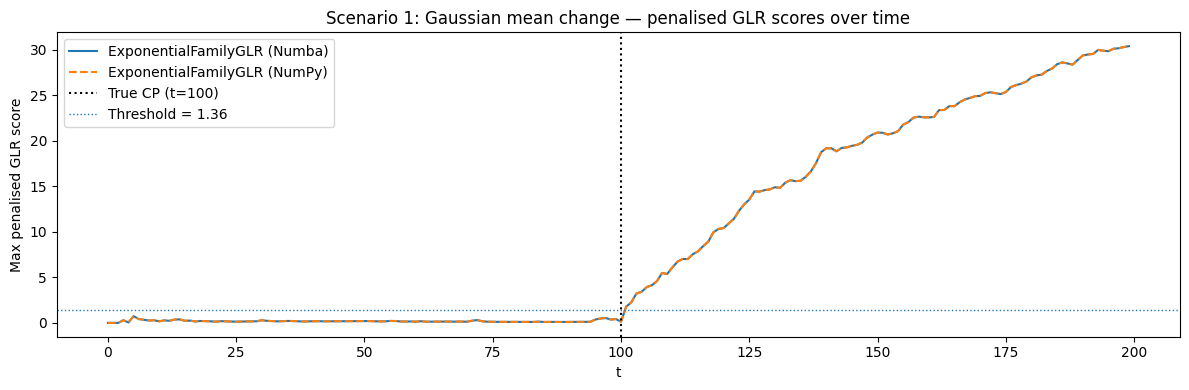

In [4]:
import matplotlib.pyplot as plt

# -- Collect max penalised score at each timestep --
def collect_max_scores(score, data):
    state = score.init_state()
    grid_states = []
    max_scores = []
    for x in data:
        state = score.update(state, x)
        grid_states.append(score.init_state())
        grid_states = [score.update(gs, x) for gs in grid_states]
        if state.n_samples < score.v + 1:
            max_scores.append(0.0)
            continue
        with np.errstate(invalid='ignore', divide='ignore'):
            scores = score.compute_penalised_scores(state, grid_states)
        valid = scores[np.isfinite(scores)]
        max_scores.append(valid.max() if len(valid) > 0 else 0.0)
    return np.array(max_scores)

max_scores_numba = collect_max_scores(score_numba, data)
max_scores_numpy = collect_max_scores(score_numpy, data)

ALPHA = 0.05
K_CAL = 1000
SEED = 42
PARALLEL = True

# -- Calibrate --
print("Calibrating ExponentialFamilyGLR (Numba) ...")
thr1_ef_numba = calibrate_threshold(
    score_numba, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  Threshold: {thr1_ef_numba:.4f}")

# -- Plot --
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(max_scores_numba, label="ExponentialFamilyGLR (Numba)", lw=1.5)
ax.plot(max_scores_numpy, label="ExponentialFamilyGLR (NumPy)", lw=1.5, linestyle="--")
ax.axvline(CP, color="black", linestyle=":", lw=1.5, label=f"True CP (t={CP})")
ax.axhline(thr1_ef_numba, color="C0", linestyle=":", lw=1.0, label=f"Threshold = {thr1_ef_numba:.2f}")
ax.set_xlabel("t")
ax.set_ylabel("Max penalised GLR score")
ax.set_title("Scenario 1: Gaussian mean change — penalised GLR scores over time")
ax.legend()
plt.tight_layout()
plt.show()

Calibrating ...
  Threshold: 1.0911
  ✓ All scores match between Numba and NumPy paths
  Max absolute difference: 1.09e-14

Building state for timing ...
Timing compute_penalised_scores over 100 calls (t=100) ...
  Numba — 229.55 µs per call
  NumPy — 30079.57 µs per call
  Speedup: 131.0x


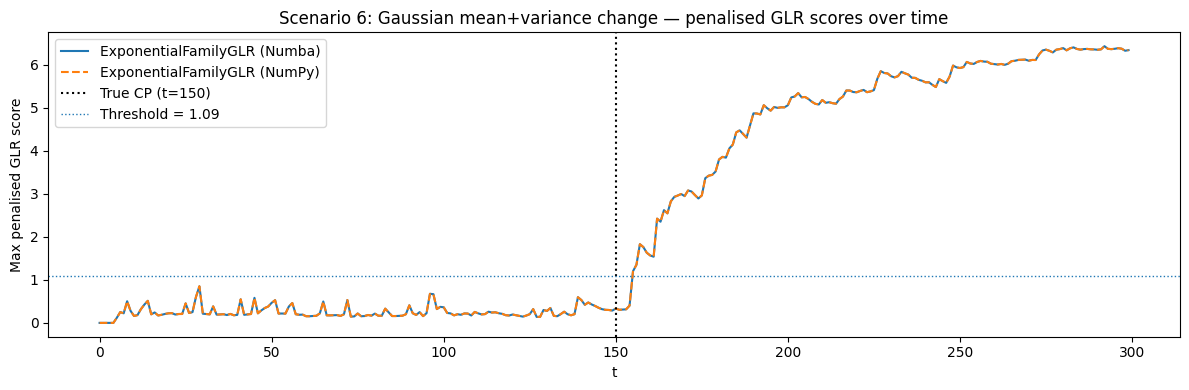

In [8]:
# =============================================================================
# Scenario 6: Univariate Gaussian — joint change in mean AND variance (v=2)
# =============================================================================

N6, CP6 = 300, 150
MU_PRE6, MU_POST6 = 0.0, 2.0
SIGMA_PRE6, SIGMA_POST6 = 1.0, 2.0

# -- Numba functions --
@nb.njit
def h6(x):
    out = np.empty(2)
    out[0] = x[0]
    out[1] = x[0] * x[0]
    return out

@nb.njit
def A6(theta):
    return -theta[0] * theta[0] / (4.0 * theta[1]) - 0.5 * np.log(-2.0 * theta[1])

@nb.njit
def Agrad6(theta):
    g = np.empty(2)
    g[0] = -theta[0] / (2.0 * theta[1])
    g[1] = theta[0] * theta[0] / (4.0 * theta[1] * theta[1]) - 1.0 / (2.0 * theta[1])
    return g

@nb.njit
def Ahess6(theta):
    H = np.zeros((2, 2))
    H[0, 0] = -1.0 / (2.0 * theta[1])
    H[0, 1] = theta[0] / (2.0 * theta[1] * theta[1])
    H[1, 0] = H[0, 1]
    H[1, 1] = (-theta[0] * theta[0] / (2.0 * theta[1] ** 3)
                + 1.0 / (2.0 * theta[1] * theta[1]))
    return H

# -- NumPy functions --
def h6_np(x):
    return np.array([x[0], x[0] * x[0]])

def A6_np(theta):
    return -theta[0] * theta[0] / (4.0 * theta[1]) - 0.5 * np.log(-2.0 * theta[1])

def Agrad6_np(theta):
    g = np.empty(2)
    g[0] = -theta[0] / (2.0 * theta[1])
    g[1] = theta[0] * theta[0] / (4.0 * theta[1] * theta[1]) - 1.0 / (2.0 * theta[1])
    return g

def Ahess6_np(theta):
    H = np.zeros((2, 2))
    H[0, 0] = -1.0 / (2.0 * theta[1])
    H[0, 1] = theta[0] / (2.0 * theta[1] * theta[1])
    H[1, 0] = H[0, 1]
    H[1, 1] = (-theta[0] * theta[0] / (2.0 * theta[1] ** 3)
                + 1.0 / (2.0 * theta[1] * theta[1]))
    return H

# -- Scores --
theta_init6 = np.array([0.0, -0.5])

score6_numba = ExponentialFamilyGLR(
    v=2, n_features=1, h=h6, A=A6,
    A_grad=Agrad6, A_hess=Ahess6,
    theta_init=theta_init6,
)
score6_numpy = ExponentialFamilyGLR(
    v=2, n_features=1, h=h6_np, A=A6_np,
    A_grad=Agrad6_np, A_hess=Ahess6_np,
    theta_init=theta_init6,
)

# -- Data --
rng6 = np.random.default_rng(42)
data6 = np.concatenate([
    rng6.normal(MU_PRE6,  SIGMA_PRE6,  (CP6,      1)),
    rng6.normal(MU_POST6, SIGMA_POST6, (N6 - CP6, 1)),
])

# -- Calibrate --
print("Calibrating ...")
thr6 = calibrate_threshold(
    score6_numba, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N6,
    pre_sampler=np.random.default_rng(0).standard_normal,
    parallel=PARALLEL, rng=SEED,
)
print(f"  Threshold: {thr6:.4f}")

# -- Numerical equivalence + scores over time --
print("Collecting scores over time ...")
with np.errstate(invalid='ignore', divide='ignore'):
    max_scores6_numba = collect_max_scores(score6_numba, data6)
    max_scores6_numpy = collect_max_scores(score6_numpy, data6)

min_seg6 = score6_numba.v + 1
all_match = True
for t, (s_nb, s_np) in enumerate(zip(max_scores6_numba, max_scores6_numpy)):
    if t < min_seg6:
        continue
    if not np.isclose(s_nb, s_np, rtol=1e-5, atol=1e-8, equal_nan=True):
        print(f"  MISMATCH at t={t}: diff = {abs(s_nb - s_np):.2e}")
        all_match = False

if all_match:
    print("  ✓ All scores match between Numba and NumPy paths")

diffs = [
    abs(s_nb - s_np)
    for t, (s_nb, s_np) in enumerate(zip(max_scores6_numba, max_scores6_numpy))
    if t >= min_seg6
]
print(f"  Max absolute difference: {max(diffs):.2e}")

# -- Timing: compute_penalised_scores in isolation --
# Build state once at a representative t
print("\nBuilding state for timing ...")
state6_t, grid6_t_numba = score6_numba.init_state(), []
state6_t_np, grid6_t_numpy = score6_numpy.init_state(), []
for x in data6[:100]:
    state6_t = score6_numba.update(state6_t, x)
    grid6_t_numba.append(score6_numba.init_state())
    grid6_t_numba = [score6_numba.update(gs, x) for gs in grid6_t_numba]

    state6_t_np = score6_numpy.update(state6_t_np, x)
    grid6_t_numpy.append(score6_numpy.init_state())
    grid6_t_numpy = [score6_numpy.update(gs, x) for gs in grid6_t_numpy]

# Warm up
score6_numba.compute_penalised_scores(state6_t, grid6_t_numba)
score6_numpy.compute_penalised_scores(state6_t_np, grid6_t_numpy)

N_REPEATS_INNER = 100
print(f"Timing compute_penalised_scores over {N_REPEATS_INNER} calls (t=100) ...")

t0 = time.perf_counter()
for _ in range(N_REPEATS_INNER):
    score6_numba.compute_penalised_scores(state6_t, grid6_t_numba)
t_numba6 = (time.perf_counter() - t0) / N_REPEATS_INNER

t0 = time.perf_counter()
for _ in range(N_REPEATS_INNER):
    score6_numpy.compute_penalised_scores(state6_t_np, grid6_t_numpy)
t_numpy6 = (time.perf_counter() - t0) / N_REPEATS_INNER

print(f"  Numba — {t_numba6*1e6:.2f} µs per call")
print(f"  NumPy — {t_numpy6*1e6:.2f} µs per call")
print(f"  Speedup: {t_numpy6/t_numba6:.1f}x")

# -- Plot --
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(max_scores6_numba, label="ExponentialFamilyGLR (Numba)", lw=1.5)
ax.plot(max_scores6_numpy, label="ExponentialFamilyGLR (NumPy)", lw=1.5, linestyle="--")
ax.axvline(CP6, color="black", linestyle=":", lw=1.5, label=f"True CP (t={CP6})")
ax.axhline(thr6, color="C0", linestyle=":", lw=1.0, label=f"Threshold = {thr6:.2f}")
ax.set_xlabel("t")
ax.set_ylabel("Max penalised GLR score")
ax.set_title("Scenario 6: Gaussian mean+variance change — penalised GLR scores over time")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# Scenario 8: Multivariate Gaussian — change in covariance (known mean = 0, p=3)
# h(x) = vech(x xᵀ),  A(θ) = -½ log det(-2Θ)
# v = p(p+1)/2 = 6
# Pre: N(0,I) → Post: N(0, diag(1,4,9))  |  N=300, CP=150
# =============================================================================

P8 = 3
V8 = P8 * (P8 + 1) // 2   # = 6
N8, CP8 = 300, 150
SIGMA_PRE8  = np.eye(P8)
SIGMA_POST8 = np.diag([1.0, 4.0, 9.0])

# -- Numba functions --
@nb.njit
def h8(x):
    p = x.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                out[idx] = x[i] * x[j]
            else:
                out[idx] = 2.0 * x[i] * x[j]
            idx += 1
    return out

@nb.njit
def A8(theta):
    p = _p_from_v(theta.shape[0])
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld

@nb.njit
def Agrad8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    Mi = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = Mi[i, i]
            else:
                g[idx] = 2.0 * Mi[i, j]
            idx += 1
    return g

@nb.njit
def Ahess8(theta):
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)
    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i; cols[idx] = j
            idx += 1
    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H

# -- NumPy functions --
def h8_np(x):
    p = x.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            out[idx] = x[i] * x[j] if i == j else 2.0 * x[i] * x[j]
            idx += 1
    return out

def _p_from_v_np(v):
    return int((-1.0 + (1.0 + 8.0 * v) ** 0.5) / 2.0)

def _fill_sym_np(theta_vec, p):
    Theta = np.zeros((p, p))
    idx = 0
    for i in range(p):
        for j in range(i, p):
            Theta[i, j] = theta_vec[idx]
            Theta[j, i] = theta_vec[idx]
            idx += 1
    return Theta

def A8_np(theta):
    p = _p_from_v_np(theta.shape[0])
    Theta = _fill_sym_np(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld

def Agrad8_np(theta):
    v = theta.shape[0]
    p = _p_from_v_np(v)
    Theta = _fill_sym_np(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    Mi = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            g[idx] = Mi[i, i] if i == j else 2.0 * Mi[i, j]
            idx += 1
    return g

def Ahess8_np(theta):
    v = theta.shape[0]
    p = _p_from_v_np(v)
    Theta = _fill_sym_np(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)
    rows, cols = [], []
    for i in range(p):
        for j in range(i, p):
            rows.append(i); cols.append(j)
    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_a = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_b = 1.0 if k == l else 2.0
            H[a, b] = c_a * c_b * (Mi[i, k] * Mi[j, l] + Mi[i, l] * Mi[j, k])
    return H

# -- theta_init: Θ = -½ Σ⁻¹ for Σ = I --
_Theta8 = -0.5 * np.linalg.inv(SIGMA_PRE8)
theta_init8 = np.array([
    _Theta8[i, j] for i in range(P8) for j in range(i, P8)
], dtype=np.float64)

# -- Scores --
score8_numba = ExponentialFamilyGLR(
    v=V8, n_features=P8, h=h8, A=A8,
    A_grad=Agrad8, A_hess=Ahess8,
    theta_init=theta_init8,
)
score8_numpy = ExponentialFamilyGLR(
    v=V8, n_features=P8, h=h8_np, A=A8_np,
    A_grad=Agrad8_np, A_hess=Ahess8_np,
    theta_init=theta_init8,
)

# -- Data --
rng8 = np.random.default_rng(42)
data8 = np.concatenate([
    rng8.multivariate_normal(np.zeros(P8), SIGMA_PRE8,  CP8),
    rng8.multivariate_normal(np.zeros(P8), SIGMA_POST8, N8 - CP8),
])

# -- Calibrate --
print("Calibrating ...")
thr8 = calibrate_threshold(
    score8_numba, false_alarm_probability=ALPHA,
    n_paths=K_CAL, stream_len=N8,
    pre_sampler=lambda rng=None: np.random.default_rng().multivariate_normal(
        np.zeros(P8), SIGMA_PRE8),
    parallel=PARALLEL, rng=SEED,
)
print(f"  Threshold: {thr8:.4f}")

# -- Scores over time --
print("Collecting scores over time ...")
with np.errstate(invalid='ignore', divide='ignore'):
    max_scores8_numba = collect_max_scores(score8_numba, data8)
    max_scores8_numpy = collect_max_scores(score8_numpy, data8)

min_seg8 = score8_numba.v + 1
all_match = True
for t, (s_nb, s_np) in enumerate(zip(max_scores8_numba, max_scores8_numpy)):
    if t < min_seg8:
        continue
    if not np.isclose(s_nb, s_np, rtol=1e-5, atol=1e-8, equal_nan=True):
        print(f"  MISMATCH at t={t}: diff = {abs(s_nb - s_np):.2e}")
        all_match = False

if all_match:
    print("  ✓ All scores match between Numba and NumPy paths")

diffs = [
    abs(s_nb - s_np)
    for t, (s_nb, s_np) in enumerate(zip(max_scores8_numba, max_scores8_numpy))
    if t >= min_seg8
]
print(f"  Max absolute difference: {max(diffs):.2e}")

# -- Timing: compute_penalised_scores in isolation at t=100 --
print("\nBuilding state for timing ...")
state8_t, grid8_t_numba = score8_numba.init_state(), []
state8_t_np, grid8_t_numpy = score8_numpy.init_state(), []
for x in data8[:100]:
    state8_t = score8_numba.update(state8_t, x)
    grid8_t_numba.append(score8_numba.init_state())
    grid8_t_numba = [score8_numba.update(gs, x) for gs in grid8_t_numba]

    state8_t_np = score8_numpy.update(state8_t_np, x)
    grid8_t_numpy.append(score8_numpy.init_state())
    grid8_t_numpy = [score8_numpy.update(gs, x) for gs in grid8_t_numpy]

# Warm up
score8_numba.compute_penalised_scores(state8_t, grid8_t_numba)
score8_numpy.compute_penalised_scores(state8_t_np, grid8_t_numpy)

N_REPEATS_INNER = 10_000
print(f"Timing compute_penalised_scores over {N_REPEATS_INNER} calls (t=100) ...")

t0 = time.perf_counter()
for _ in range(N_REPEATS_INNER):
    score8_numba.compute_penalised_scores(state8_t, grid8_t_numba)
t_numba8 = (time.perf_counter() - t0) / N_REPEATS_INNER

t0 = time.perf_counter()
for _ in range(N_REPEATS_INNER):
    score8_numpy.compute_penalised_scores(state8_t_np, grid8_t_numpy)
t_numpy8 = (time.perf_counter() - t0) / N_REPEATS_INNER

print(f"  Numba — {t_numba8*1e6:.2f} µs per call")
print(f"  NumPy — {t_numpy8*1e6:.2f} µs per call")
print(f"  Speedup: {t_numpy8/t_numba8:.1f}x")

# -- Plot --
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(max_scores8_numba, label="ExponentialFamilyGLR (Numba)", lw=1.5)
ax.plot(max_scores8_numpy, label="ExponentialFamilyGLR (NumPy)", lw=1.5, linestyle="--")
ax.axvline(CP8, color="black", linestyle=":", lw=1.5, label=f"True CP (t={CP8})")
ax.axhline(thr8, color="C0", linestyle=":", lw=1.0, label=f"Threshold = {thr8:.2f}")
ax.set_xlabel("t")
ax.set_ylabel("Max penalised GLR score")
ax.set_title(f"Scenario 8: MV Gaussian covariance change — Σ=I → diag(1,4,9) (p={P8})")
ax.legend()
plt.tight_layout()
plt.show()

Calibrating ...


/uio/hume/student-u56/espenbur/Desktop/G-CHAD/gridcp/calibration.py:1114: RuntimeWarning: Parallel Monte Carlo failed; falling back to serial execution. Original error: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
NameError: name '_p_from_v' is not defined
During: Pass nopython_type_inference
During: resolving callee type: type(CPUDispatcher(<function Agrad8 at 0x7f67a19a8360>))
During: typing of call at /tmp/ipykernel_3367899/380298645.py (169)

File "../../../../../../../tmp/ipykernel_3367899/380298645.py", line 169:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference
During: resolving callee type: type(CPUDispatcher(<function make_vector_newton_solver.<locals>.solver at 0x7f6804dd5e40>))
During: typing of call at /tmp/ipykernel_3367899/380298645.py (463)
During: typing of call at /tmp/ipykernel_3367899/380298645.py (464)
During: ty

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
NameError: name '_p_from_v' is not defined
During: Pass nopython_type_inference
During: resolving callee type: type(CPUDispatcher(<function Agrad8 at 0x7f67a19a8360>))
During: typing of call at /tmp/ipykernel_3367899/380298645.py (169)

File "../../../../../../../tmp/ipykernel_3367899/380298645.py", line 169:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference
During: resolving callee type: type(CPUDispatcher(<function make_vector_newton_solver.<locals>.solver at 0x7f6804dd5e40>))
During: typing of call at /tmp/ipykernel_3367899/380298645.py (463)
During: typing of call at /tmp/ipykernel_3367899/380298645.py (464)
During: typing of call at /tmp/ipykernel_3367899/380298645.py (465)

File "../../../../../../../tmp/ipykernel_3367899/380298645.py", line 463:
<source missing, REPL/e